In [1]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd



import csv
import gzip
import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context


# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7 # figure.titlesize
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}
import helper_functions


/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# --- INIT ---

# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided'
cluster_resolution = 0.05
subcluster_resolution = 0.20


# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder


# regular clusters
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)
folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_2' % head_folder


# subclusters
# clustering_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint/data_annotations/hvg/%s/scvi_res/clustering/res_%s/subclustering/res_%s' % (head_folder,hvg_to_use,cluster_resolution,subcluster_resolution)
# cluster_df_fileout = '%s/smc_subclusters.tsv' % (clustering_folder)
# folder_out = '%s/Dropbox/aorta_circadian_data/results/fig_2' % head_folder
# folder_out = '%s/SMC_subcluster' % folder_out




# settings
log10_bf_thresh = 2
frac_circadian_samples_crossing_zero_thresh = 0.05
num_waveform_samples = 300
use_log_prop_fft = True






In [3]:
# --- LOAD THE ADATA ---

import anndata
adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [5]:
# --- LOAD THE UNIQUE CLUSTERS ---

cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')
# clusters = list(filter(lambda x: ~np.isnan(x),cluster_df['smc_subcluster'])) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(filter(lambda x: ~np.isnan(x),cluster_df['leiden_scvi_cluster'])) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))
clusters = sorted(list(np.unique(clusters)))
clusters



[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [6]:
# --- MAKE THE FOLDER OUT ---

if not os.path.exists(folder_out):
    os.makedirs(folder_out)


In [7]:
# --- GET THE UNIQUE DESCRIPTION AND CLUSTERS ---

# descriptions = list(adata.obs['description'].unique())
# clusters = list(adata.obs['cluster'].unique())


# regular clusters
clusters = [0, 1, 2, 3]
cluster_cell_type_dict = dict(zip(clusters,['SMC','Fibroblast','Endothelial', 'Macrophage']))


# SMC subclusters
# # clusters = sorted(list(adata.obs['cluster'].unique()))
# cluster_cell_type_names = list(map(lambda x: "SMC%s" % int(x), clusters))
# cluster_cell_type_dict = dict(zip(clusters,
#                                   cluster_cell_type_names))


descriptions = ['male aligned bmal1-ko', 
                'male misaligned bmal1-control', 
                'female aligned bmal1-ko', 
                'female misaligned bmal1-control', 
                'male aligned bmal1-control', 
                'female aligned bmal1-control']

print("Unique descriptions:\n",descriptions)
print("Unique clusters:\n",clusters)





Unique descriptions:
 ['male aligned bmal1-ko', 'male misaligned bmal1-control', 'female aligned bmal1-ko', 'female misaligned bmal1-control', 'male aligned bmal1-control', 'female aligned bmal1-control']
Unique clusters:
 [0, 1, 2, 3]


In [8]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/nonparametric_reg' % clustering_folder
if not os.path.exists(reg_head_folder):
    os.makedirs(reg_head_folder)


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    if not os.path.exists(cluster_reg_folder):
        os.makedirs(cluster_reg_folder)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)
        if not os.path.exists(cluster_description_reg_folder):
            os.makedirs(cluster_description_reg_folder)
            
        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [9]:
# --- LOAD THE GENES TO ESTIMATE ---

genes_to_est_fileout = '%s/genes_to_est.txt' % reg_head_folder
with open(genes_to_est_fileout) as file_obj:
    reg_genes_to_est = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))
    
    
len(reg_genes_to_est)

22193

In [10]:
# --- SET DESCRIPTION TO male aligned bmal1-control ---

description = 'male aligned bmal1-control'


In [12]:
# --- GET THE METRIC DF'S FOR EACH CLUSTER ---

cluster_metric_dfs = []
for cluster in clusters:
    
    
    # ** load metric df **
    metric_path = '%s/de_novo_metrics.tsv' % cluster_description_folder_out_dict[cluster][description]
    metric_df = pd.read_table(metric_path,index_col='gene',sep='\t')
    
    # ** load gene parameters **
    gene_log_alpha_path = '%s/gene_log_alpha.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_beta_path = '%s/gene_log_beta.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_min_max_path = '%s/log_min_max.tsv' % cluster_description_folder_out_dict[cluster][description]
    gene_log_alpha_df = pd.read_table(gene_log_alpha_path,sep='\t',index_col='gene')
    gene_log_beta_df = pd.read_table(gene_log_beta_path,sep='\t',index_col='gene')
    gene_log_min_max_df = pd.read_table(gene_log_min_max_path,sep='\t',index_col='gene')
    
    # ** compute the expected waveforms **
    gene_expected_beta = np.array((np.exp(gene_log_alpha_df) / (np.exp(gene_log_alpha_df) + np.exp(gene_log_beta_df))))
    gene_log_min = np.array(gene_log_min_max_df['log_min']).reshape(-1,1)
    gene_log_max = np.array(gene_log_min_max_df['log_max']).reshape(-1,1)
    gene_expected_log_prop = (gene_expected_beta * (gene_log_max - gene_log_min)) + gene_log_min
    
    # ** compute the gene mesors **
    gene_expected_mesor = np.mean(gene_expected_log_prop,axis=1)
    metric_df['expected_mesor'] = gene_expected_mesor
    
    # ** compute the expected acrophases and amplitudes **
    num_grid_points = 4
    fft_res = np.fft.fft(gene_expected_log_prop,axis=1)
    freqs = np.fft.fftfreq(num_grid_points,d=24.0/num_grid_points)
    periods = 1 / freqs
    amps = abs(fft_res)
    circadian_index = np.where(np.isin(periods,[24]))[0]
    expected_acrophase = (np.arctan2(fft_res[:,circadian_index].imag,fft_res[:,circadian_index].real) % (2 * np.pi)).flatten()
    expected_amp = amps[:,circadian_index,].flatten()
    metric_df['expected_acrophase'] = expected_acrophase
    metric_df['expected_amp'] = expected_amp
    
    # ** add **
    cluster_metric_dfs.append(metric_df)
    


/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_36982/4144058257.py:33: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_36982/4144058257.py:33: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_36982/4144058257.py:33: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_36982/4144058257.py:33: RuntimeWarning: divide by zero encountered in true_divide
  periods = 1 / freqs


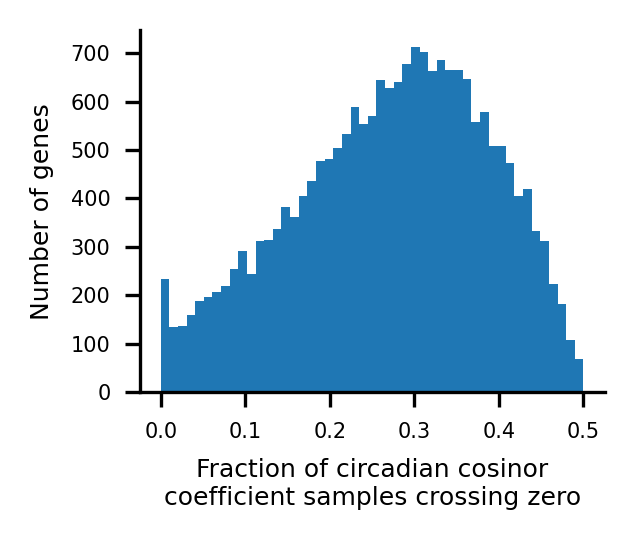

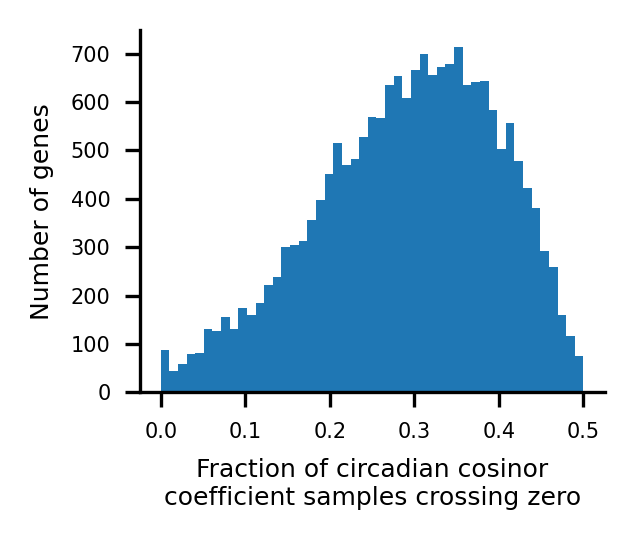

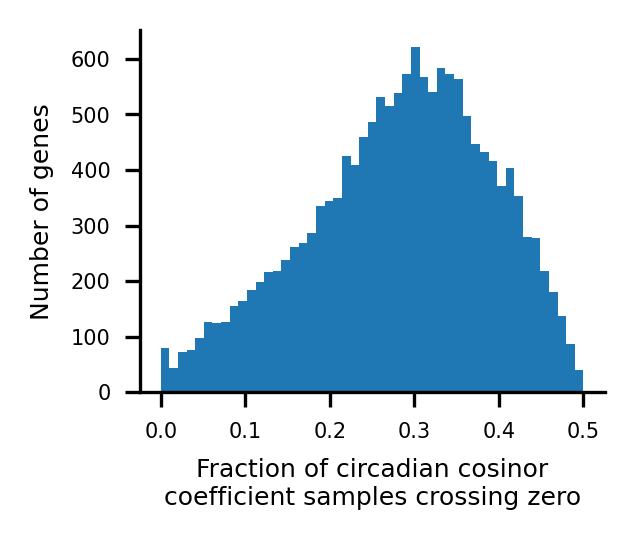

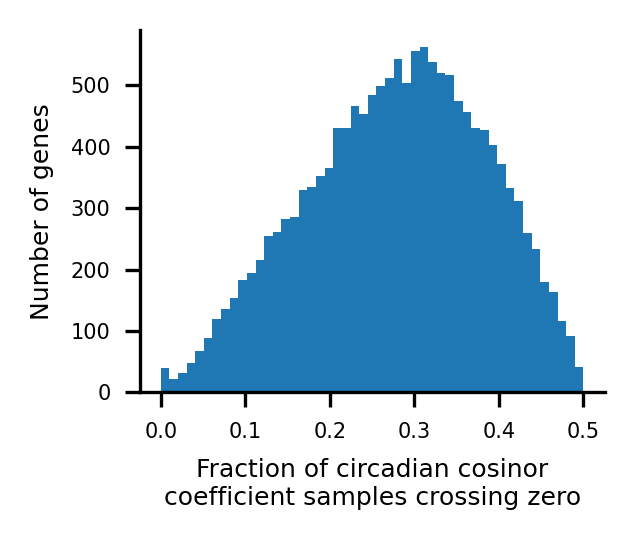

In [12]:
# --- LOOK AT THE CYCLER STATISTIC DISTRIBUTION IN EACH CELL TYPE ---


for cluster, metric_df in enumerate(cluster_metric_dfs):
    
    fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
    plt.hist(metric_df['frac_circadian_samples_crossing_zero'],bins=np.linspace(0,0.5,50))
    sns.despine()
    plt.xlabel("Fraction of circadian cosinor\ncoefficient samples crossing zero")
    plt.ylabel("Number of genes")
    subfolder_out = '%s/cycler_statistic_distribution' % folder_out
    if not os.path.exists(subfolder_out):
        os.makedirs(subfolder_out)
    fileout = '%s/cluster_%s.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
    plt.savefig(fileout,bbox_inches='tight')
    plt.show()



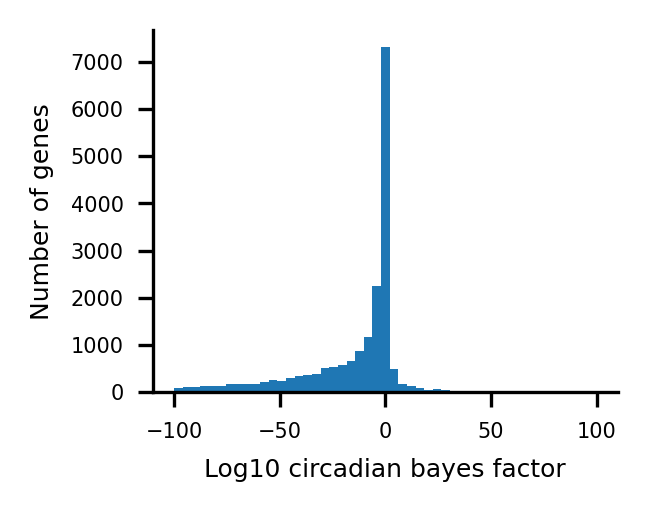

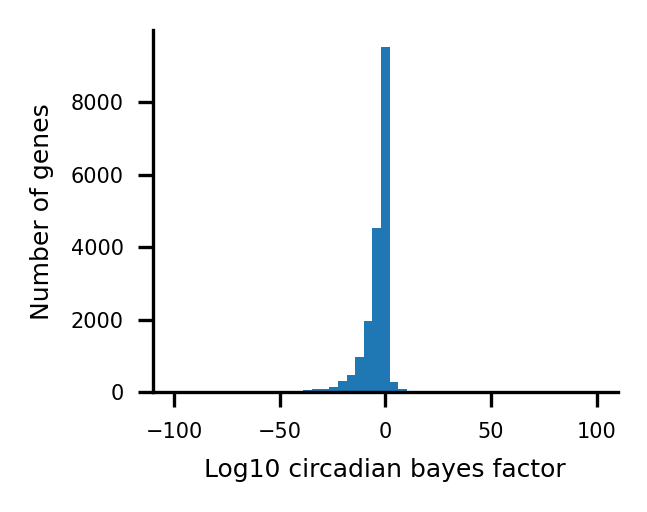

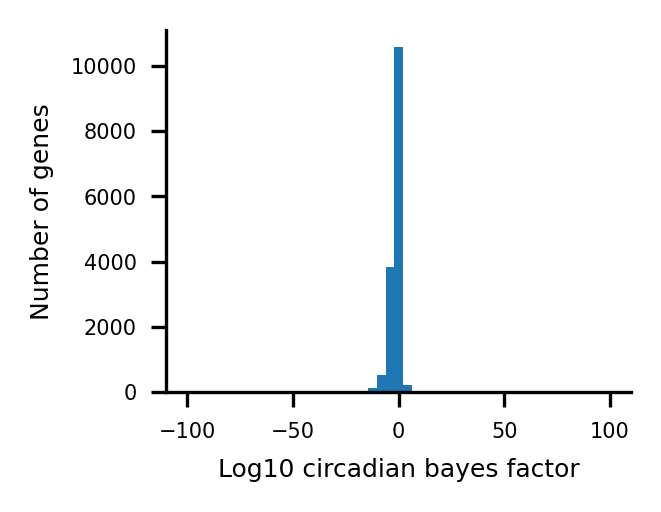

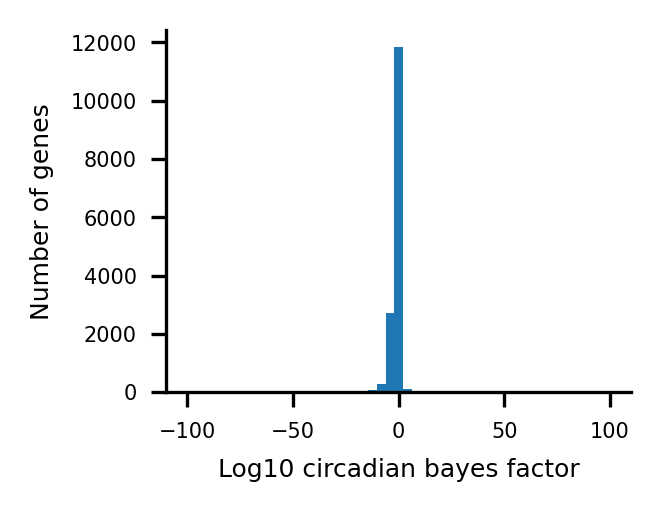

In [13]:
# --- LOOK AT THE BF CYCLER STATISTIC DISTRIBUTION IN EACH CELL TYPE ---

    
for cluster, metric_df in enumerate(cluster_metric_dfs):
    
    fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
    plt.hist(metric_df['waveform_over_circadian_component_subtracted_log10_bf'], bins=np.linspace(-100,100,50)) # bins=np.linspace(0,0.5,50)
    sns.despine()
    plt.xlabel("Log10 circadian bayes factor")
    plt.ylabel("Number of genes")
    plt.show()




In [13]:
# --- GET CYCLERS IN EACH ---


cluster_cycler_metric_dfs = []
for cluster in clusters:
    print(cluster)

    # get the corresponding metric DF for the cluster
    cluster_cycler_metric_df = cluster_metric_dfs[cluster][cluster_metric_dfs[cluster]['waveform_over_circadian_component_subtracted_log10_bf'] >= log10_bf_thresh]
    # cluster_cycler_metric_df = cluster_metric_dfs[cluster][cluster_metric_dfs[cluster]['frac_circadian_samples_crossing_zero'] <= frac_circadian_samples_crossing_zero_thresh]
    cluster_cycler_metric_df = cluster_cycler_metric_df.sort_values('waveform_over_circadian_component_subtracted_log10_bf',ascending=False)
    cluster_cycler_metric_dfs.append(cluster_cycler_metric_df)










0
1
2
3


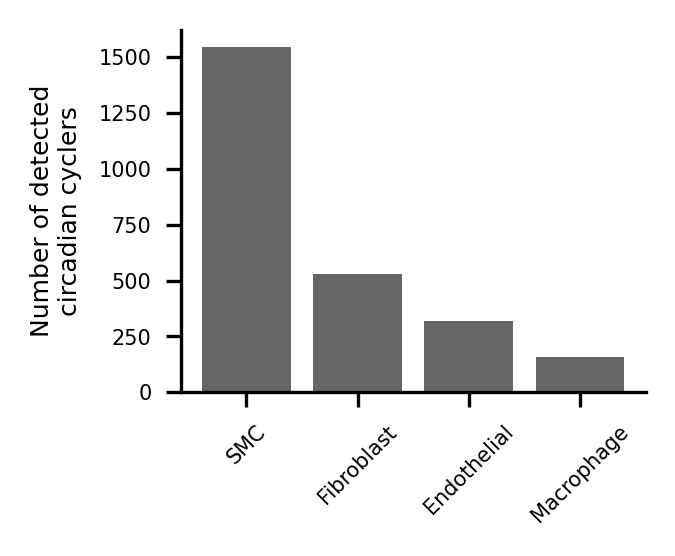

In [14]:
# --- HOW MANY CYCLERS ARE THERE IN EACH CELL TYPE IN MALE? ---

# ** get the number of cyclers in each **
num_cyclers_list = []
for cluster_cycler_metric_df in cluster_cycler_metric_dfs:
    num_cyclers_list.append(len(cluster_cycler_metric_df))

    
    
# ** viz **
fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
plt.bar(clusters,num_cyclers_list,color='k',alpha=0.6)
# plt.xticks(clusters,['SMC','Fibroblast', 'Endothelial', 'Macrophage', 'Unknown1','Unknown2','Unknown3'],rotation=45)
plt.xticks(clusters,list(map(lambda x: cluster_cell_type_dict[x],clusters)),rotation=45)
sns.despine()
plt.ylabel("Number of detected\ncircadian cyclers")
fileout = '%s/num_cyclers_per_cluster.pdf' % folder_out
plt.savefig(fileout,bbox_inches='tight')
plt.show()









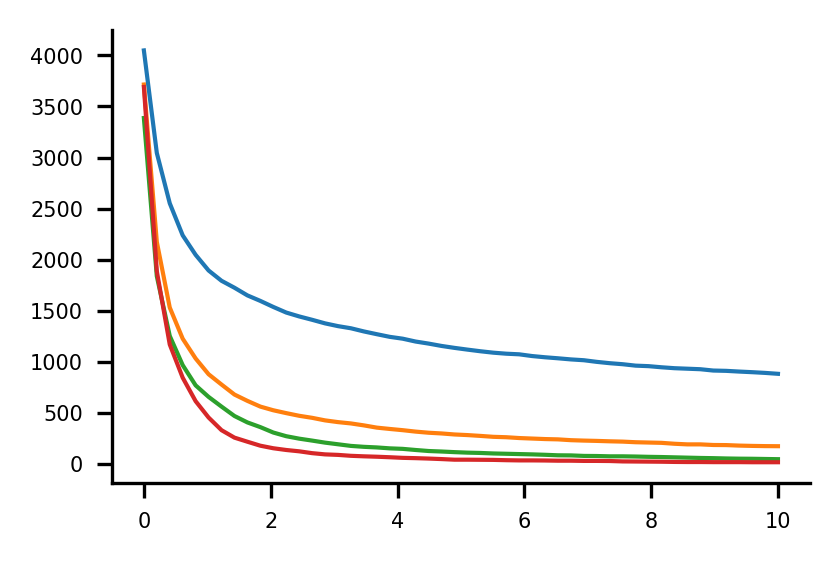

In [16]:
# --- LOOK AT HOW NUMBER OF CYCLERS IS SENSITIVE ON THRESHOLD IN EACH CELL TYPE ---


# ** get the max BF across cell types **
max_log10_bf_thresh = -1
for metric_df in cluster_metric_dfs:
    val = np.max(metric_df['waveform_over_circadian_component_subtracted_log10_bf'])
    if val > max_log10_bf_thresh:
        max_log10_bf_thresh = val

        
# ** set the grid **
log10_bf_thresh_grid = np.linspace(0,10)

# ** viz **
fig,ax=plt.subplots(figsize=(3,2),dpi=300)
for metric_df in cluster_metric_dfs:
    num_cyclers_per_thresh = []
    for temp_log10_bf_thresh in log10_bf_thresh_grid:
        cycler_metric_df = metric_df[metric_df['waveform_over_circadian_component_subtracted_log10_bf'] >= temp_log10_bf_thresh]
        num_cyclers_per_thresh.append(cycler_metric_df.shape[0])
    plt.plot(log10_bf_thresh_grid,num_cyclers_per_thresh)
sns.despine()
plt.show()
        



In [15]:
# --- WRITE OUT THE CYCLERS FOR EACH ---



for cluster in clusters:
    print(cluster)

    # get the corresponding metric DF for the cluster
    cluster_cycler_metric_df = cluster_cycler_metric_dfs[cluster]
    
    # sort
    cluster_cycler_metric_df = cluster_cycler_metric_df.sort_values(['waveform_over_circadian_component_subtracted_log10_bf'],ascending=False)


    # make the subfolder and write
    subfolder_out = '%s/cyclers' % (folder_out)
    if not os.path.exists(subfolder_out):
        os.makedirs(subfolder_out)
    fileout = '%s/cluster_%s_cyclers.tsv' % (subfolder_out,cluster_cell_type_dict[cluster])
    cluster_cycler_metric_df.to_csv(fileout,sep='\t')
    









0
1
2
3


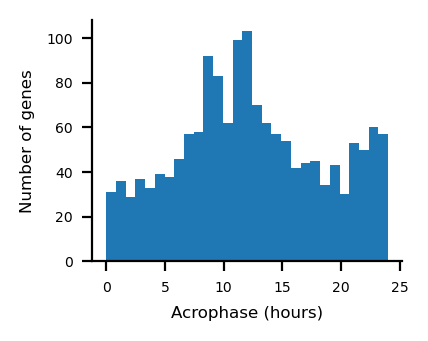

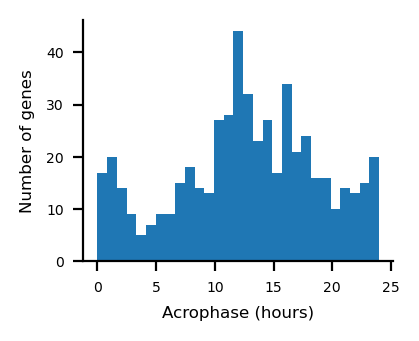

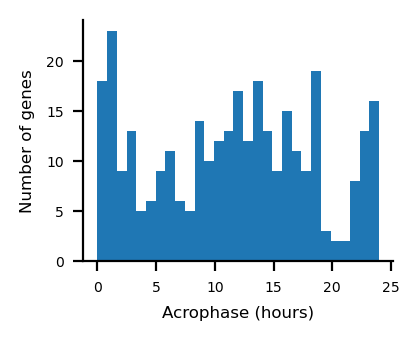

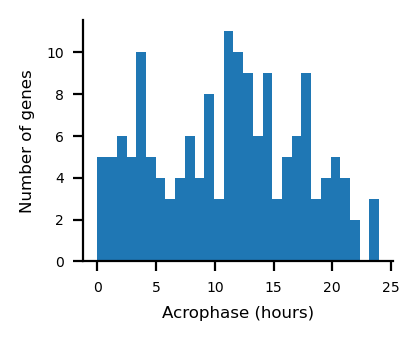

In [16]:
# --- LOOK AT THE ACROPHASE DISTRIBUTION FOR CYCLERS ---

for cluster,cluster_cycler_metric_df in zip(clusters,cluster_cycler_metric_dfs):
    
    fig,ax=plt.subplots(figsize=(2,1.6),dpi=200)
    plt.hist((cluster_cycler_metric_df['expected_acrophase'] / np.pi) * 12.0,bins=np.linspace(0,24,30))
    sns.despine()
    plt.xlabel("Acrophase (hours)")
    plt.ylabel("Number of genes")
    fileout = '%s/cluster_%s_cycler_acrophase_distribution.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
    plt.savefig(fileout,bbox_inches='tight')
    plt.show()


In [788]:
# --- FOR EACH CLUSTER, LOOK AT WHEN EACH PATHWAY PEAKS ---

import importlib
import helper_functions
importlib.reload(helper_functions)


# ** set params **
description = 'male aligned bmal1-control'
enrichment_gene_set = 'KEGG_2016' # KEGG_2016 GO_Biological_Process_2018
genes_with_params = list(cluster_cycler_metric_dfs[cluster].index) # list(cluster_cycler_metric_dfs[cluster].index) # reg_genes_to_est
# genes_with_params = reg_genes_to_est
frac_samples_greater_threshold = 0.90
signif_thresh = 0.1

# ** run **
for cluster in clusters:

    print("RUNNING TEMPORAL ENRICHMENT FOR CLUSTER %s" % cluster)


    # --- GET THE SAMPLED LOG PROP ---
    import torch
    sampled_log_prop,genes_with_params = helper_functions.get_log_prop_samples(cluster,description,num_waveform_samples,cluster_description_folder_out_dict,gene_list=genes_with_params)


    # --- GET UP AND DOWN REGULATED GENES AT EACH TIME POINT ---


    # ** get the sampled mesor **
    sampled_mesor = torch.mean(sampled_log_prop,dim=1)

    # ** compute fraction of samples greater than the mesor at each time point **
    fraction_samples_greater = torch.mean((sampled_log_prop >= sampled_mesor.unsqueeze(1)).float(),dim=0) # [time points x num_genes]

    # get the upregulated genes at each time point
    up_genes_over_time = []
    for time_index in [0,1,2,3]:
        up_genes = list(np.array(genes_with_params)[np.where(fraction_samples_greater[time_index,:] >= frac_samples_greater_threshold)[0]])
        up_genes_over_time.append(up_genes)

    # get the downregulated genes at each time point
    down_genes_over_time = []
    for time_index in [0,1,2,3]:
        down_genes = list(np.array(genes_with_params)[np.where(fraction_samples_greater[time_index,:] <= 1.0 - frac_samples_greater_threshold)[0]])
        down_genes_over_time.append(down_genes)



    # --- GET ENRICHED PATHWAYS OVER TIME ---
    importlib.reload(helper_functions)
    helper_functions.run_enrichment_over_time(up_genes_over_time,
                                        down_genes_over_time,
                                        enrichment_gene_set,
                                        genes_with_params,
                                        folder_out,
                                        cluster_cell_type_dict,
                                        cluster,
                                        sampled_log_prop,
                                        signif_thresh=signif_thresh)








321

In [41]:
# --- SET THE ENRICHMENT LIST ---

enrichment_gene_sets = ['GO_Biological_Process_2018','KEGG_2016', 'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X']
# 'KEGG_2016'
# 'Chromosome_Location'
# 'GO_Biological_Process_2018'
# 'Reactome_2016'
# 'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X'




In [80]:
# --- GET GENE SET DICTIONARIES ---
import importlib
importlib.reload(helper_functions)
gene_set_dict_of_dicts = helper_functions.get_gene_set_dicts(head_folder,reg_genes_to_est)



In [81]:
# --- FILTER THE DICT'S TO ONLY INCLUDE GENES W/ PARAMS ESTIMATED ----


for gene_set_name in list(gene_set_dict_of_dicts.keys()):
    gene_set_dict_of_dicts[gsea_set_name] = bayesian_gene_set_enrichment.filter_gsea_dict(gene_set_dict_of_dicts[gsea_set_name],set(reg_genes_to_est))







Dropping 15 keys
Dropping 0 keys
Dropping 0 keys
Dropping 0 keys
Dropping 0 keys
Dropping 0 keys
Dropping 0 keys
Dropping 0 keys
Dropping 0 keys
Dropping 0 keys
Dropping 0 keys


In [789]:
# --- FIND THAT PATHWAYS THAT HAVE 1 MODE ---


print("DO IT")

head_folder = head_folder
circadian_index = circadian_index
num_grid_points = 24
cluster = 2
description = 'male aligned bmal1-control'
enrichment_gene_set = 'KEGG_2016' # KEGG_2016 GO_Biological_Process_2018
num_samples = 100
genes_with_params = list(cluster_cycler_metric_dfs[cluster].index) # list(cluster_cycler_metric_dfs[cluster].index) # reg_genes_to_est
# genes_with_params = reg_genes_to_est
# genes_with_params = list(cluster_metric_dfs[cluster][cluster_metric_dfs[cluster]['waveform_over_circadian_component_subtracted_log10_bf'] >= 1].index)
len(genes_with_params)




DO IT


In [ ]:

# gene_set_bin_lrt_mat = np.zeros((len(gene_set_dict),num_grid_points))
# for gene_set_index,gene_set in enumerate(list(gene_set_dict.keys())):

#     # get the gene set indices
#     gene_set_indices = list(map(lambda x: gene_name_index_map[x], gene_set_dict[gene_set]))

#     # get acrophase samples
#     acrophase_samples = np.arctan2(fft_res[:,circadian_index,gene_set_indices].flatten().imag, fft_res[:,circadian_index,gene_set_indices].flatten().real) % (2 * np.pi)

#     # bin
#     phases_discretized_indices = np.round((acrophase_samples / (2 * np.pi)) * num_grid_points) # convert [0,1] to [0,num_grid_points] (float), and then discretize
#     phases_discretized_indices[np.where(phases_discretized_indices == num_grid_points)] = 0 # since bins actually go from [0,num_grid_points - 1], let's wrap back around
#     phases_discretized_indices = phases_discretized_indices.astype(int)


#     # get density
#     bin_density = np.zeros((num_grid_points))
#     for bin_index in np.arange(0,num_grid_points):
#         bin_density[bin_index] = np.sum(phases_discretized_indices == bin_index)
#     bin_density = bin_density / np.sum(bin_density)


#     # get the density of uniform distribution
#     uniform_val = 1.0 / num_grid_points

#     # compute the LRT compared to the uniform
#     gene_set_bin_lrt_mat[gene_set_index,:] = bin_density / uniform_val



In [48]:
# # --- WHAT PATHWAYS ARE THE CIRCADIAN CYCLERS ENRICHED IN? ---

# import gseapy
# import warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)



# for cluster in clusters:
#     for gene_set in enrichment_gene_sets:
#         print(cluster)

#         # get the corresponding metric DF for the cluster
#         cluster_cycler_metric_df = cluster_cycler_metric_dfs[cluster]

#         # get enrichment results
#         res = gseapy.enrichr(gene_list=list(cluster_cycler_metric_df.index),
#                              gene_sets = gene_set,
#                             organism = 'mouse',
#                             background=list(reg_genes_to_est))


#         # get the DF
#         res_df = res.results
#         res_df = res_df.set_index("Gene_set")
        
#         # make the subfolder
#         subfolder_out = '%s/cycler_enrichment/%s' % (folder_out,gene_set)
#         if not os.path.exists(subfolder_out):
#             os.makedirs(subfolder_out)
#         fileout = '%s/cluster_%s_cycler_enrichment.tsv' % (subfolder_out,cluster_cell_type_dict[cluster])
#         res_df.to_csv(fileout,sep='\t')







0
0
0
1
1
1
2
2
2
3
3
3


In [32]:
# # --- ASSIGN GENES TO PEAKING AT ZT0, 6, 12, 18 ---


# def compute_angle_dif(angle_1,angle_2):
#     angle_1 = angle_1 % (2 * np.pi)
#     angle_2 = angle_2 % (2 * np.pi)
#     angle_dif = np.abs(angle_2 - angle_1)
#     angle_dif[np.where(angle_dif > np.pi)] = (2 * np.pi) - angle_dif[np.where(angle_dif > np.pi)]
#     return angle_dif


# for cluster in clusters:
#     for zt in [0,6,12,18]:
#         angle_dif = compute_angle_dif(np.array(cluster_cycler_metric_dfs[cluster]['expected_acrophase']),(zt / 12.0) * np.pi)
#         hour_dif = (angle_dif / np.pi) * 12.0
#         cluster_cycler_metric_dfs[cluster]['is_zt%s_cycler' % zt] = hour_dif <= 3




In [35]:
# # --- WHAT PATHWAYS ARE ENRICHED AT EACH OF THE 4 TIME POINTS ---



# import gseapy
# import warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)



# for cluster in clusters:
#     for zt in [0,6,12,18]:
#         for gene_set in enrichment_gene_sets:
            
#             # get ZT cyclers
#             zt_cyclers = list(cluster_cycler_metric_dfs[cluster][cluster_cycler_metric_dfs[cluster]['is_zt%s_cycler' % zt]].index)

#             # get enrichment results
#             res = gseapy.enrichr(gene_list=zt_cyclers,
#                                  gene_sets = gene_set,
#                                 organism = 'mouse',
#                                 background=list(reg_genes_to_est),
#                                 cutoff=1.0)


#             # get the DF
#             res_df = res.results
#             res_df = res_df.set_index("Gene_set")

#             # make the subfolder
#             subfolder_out = '%s/zt_%s_peak_cycler_enrichment/%s' % (folder_out,zt,gene_set)
#             if not os.path.exists(subfolder_out):
#                 os.makedirs(subfolder_out)
#             fileout = '%s/cluster_%s_cycler_enrichment.tsv' % (subfolder_out,cluster_cell_type_dict[cluster])
#             res_df.to_csv(fileout,sep='\t')



            
            
        






ConnectionError: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))

In [230]:
# # --- ASSIGN GENES TO 'DAWN' / 'DUSK' CYCLERS ---



# for cluster in clusters:
#     print(cluster)


#     # ** assign genes to Dbp in phase or antiphase **
#     dbp_acrophase = cluster_cycler_metric_dfs[cluster].loc['Dbp']['expected_acrophase']
#     angle_dif = compute_angle_dif(np.array(cluster_cycler_metric_dfs[cluster]['expected_acrophase']),dbp_acrophase)
#     is_dawn_cycler = angle_dif >= np.pi / 2 # angle_dif <= np.pi / 2
#     cluster_cycler_metric_dfs[cluster]['is_dawn_cycler'] = is_dawn_cycler




0
1
2
3


/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_33111/3022255882.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_cycler_metric_dfs[cluster]['is_dawn_cycler'] = is_dawn_cycler
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_33111/3022255882.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_cycler_metric_dfs[cluster]['is_dawn_cycler'] = is_dawn_cycler
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_33111/3022255882.py:13: SettingWithCopyWarning: 
A valu

In [272]:
# # --- WHAT PATHWAYS ARE THE DAWN CIRCADIAN CYCLERS ENRICHED IN? ---

# import gseapy
# import warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)


# for cluster in clusters:
#     for gene_set in enrichment_gene_sets:
#         print(cluster)

#         # get the corresponding metric DF for the cluster
#         dawn_cyclers = list(cluster_cycler_metric_dfs[cluster][cluster_cycler_metric_dfs[cluster]['is_dawn_cycler']].index)

#         # get enrichment results
#         res = gseapy.enrichr(gene_list=dawn_cyclers,
#                              gene_sets = gene_set,
#                             organism = 'mouse',
#                             background=list(reg_genes_to_est))


#         # get the DF
#         res_df = res.results
#         res_df = res_df.set_index("Gene_set")
        
#         # make the subfolder
#         subfolder_out = '%s/dawn_cycler_enrichment/%s' % (folder_out,gene_set)
#         if not os.path.exists(subfolder_out):
#             os.makedirs(subfolder_out)
#         fileout = '%s/cluster_%s_cycler_enrichment.tsv' % (subfolder_out,cluster_cell_type_dict[cluster])
#         res_df.to_csv(fileout,sep='\t')







0
0
0
1
1
1
2
2
2
3
3
3


In [ ]:
# # --- WHAT PATHWAYS ARE THE DUSK CIRCADIAN CYCLERS ENRICHED IN? ---

# import gseapy
# import warnings
# warnings.simplefilter(action='ignore', category=FutureWarning)


# for cluster in clusters:
#     for gene_set in enrichment_gene_sets:
#         print(cluster)

#         # get dusk cyclers
#         dusk_cyclers = list(cluster_cycler_metric_dfs[cluster][~cluster_cycler_metric_dfs[cluster]['is_dawn_cycler']].index)

#         # get enrichment results
#         res = gseapy.enrichr(gene_list=dusk_cyclers,
#                              gene_sets = gene_set,
#                             organism = 'mouse',
#                             background=list(reg_genes_to_est))


#         # get the DF
#         res_df = res.results
#         res_df = res_df.set_index("Gene_set")
        
#         # make the subfolder
#         subfolder_out = '%s/dusk_cycler_enrichment/%s' % (folder_out,gene_set)
#         if not os.path.exists(subfolder_out):
#             os.makedirs(subfolder_out)
#         fileout = '%s/cluster_%s_cycler_enrichment.tsv' % (subfolder_out,cluster_cell_type_dict[cluster])
#         res_df.to_csv(fileout,sep='\t')







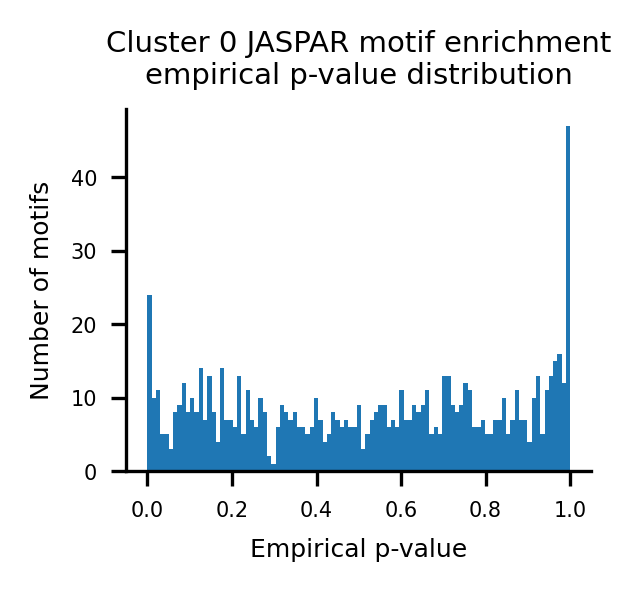

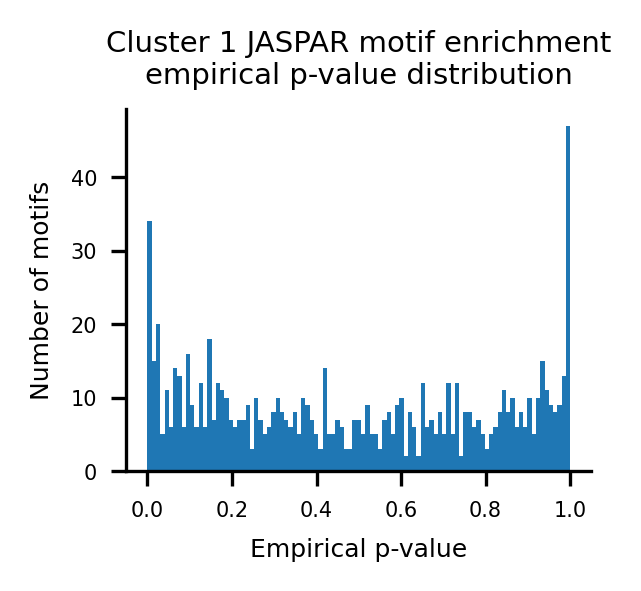

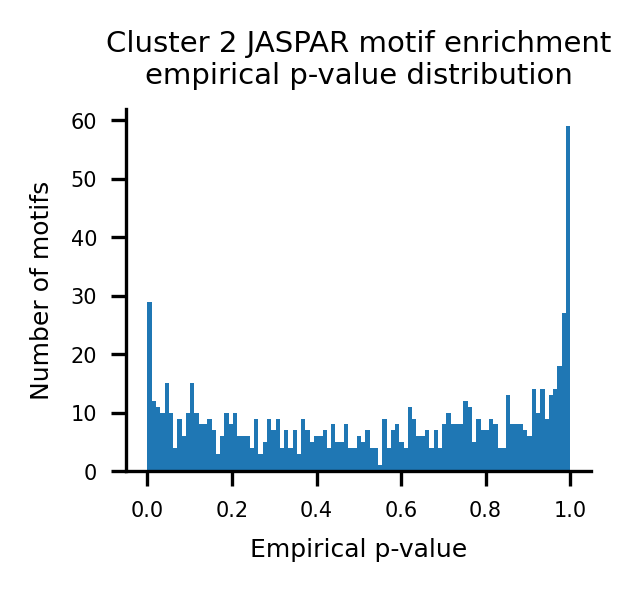

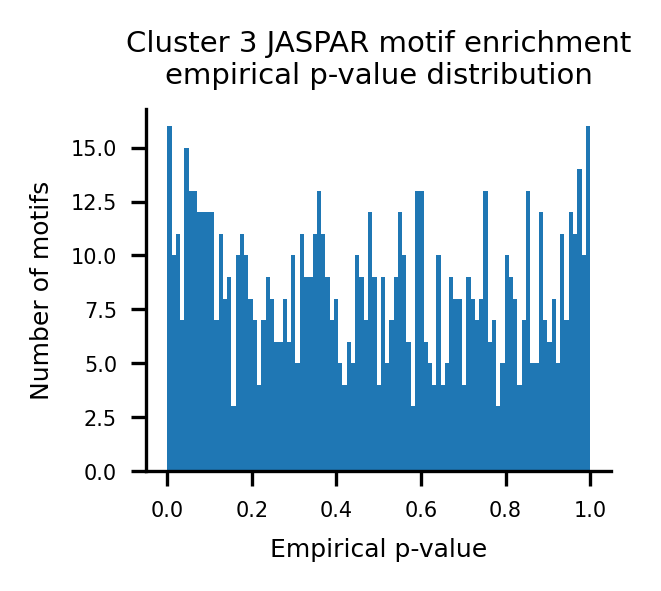

In [219]:
# --- WHAT TF MOTIFS ARE CYCLERS ENRICHED IN? ----



# ** make the subfolder **
subfolder_out = '%s/cycler_enrichment/jaspar_promoter_motif' % (folder_out)
if not os.path.exists(subfolder_out):
    os.makedirs(subfolder_out)

# ** compute enrichments **
num_shuffles = 1000
motif_p_val_dfs = []
for cluster in clusters:
    
    # ** get the enrichments **
    motif_p_val_df = helper_functions.compute_motif_enrichment(motif_lrt_df = motif_lrt_df,
                                          cluster_cyclers = list(cluster_cycler_metric_dfs[cluster].index),
                                          background_genes = list(cluster_metric_dfs[cluster].index), 
                                          num_shuffles = num_shuffles)

    # ** add **
    motif_p_val_dfs.append(motif_p_val_df)


    
    # ** viz the distribution **
    fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
    plt.hist(motif_p_vals,bins=np.linspace(0,1,100))
    sns.despine()
    plt.xlabel("Empirical p-value")
    plt.ylabel("Number of motifs")
    fileout = '%s/cluster_%s_p_val_dist.pdf' % (subfolder_out,cluster_cell_type_dict[cluster])
    plt.savefig(fileout,bbox_inches='tight')
    plt.title("Cluster %s JASPAR motif enrichment\nempirical p-value distribution" % cluster)
    plt.show()
    
    
    # ** write out DF **
    fileout = '%s/cluster_%s_cycler_enrichment.tsv' % (subfolder_out,cluster_cell_type_dict[cluster])
    motif_p_val_df.to_csv(fileout,sep='\t')

        



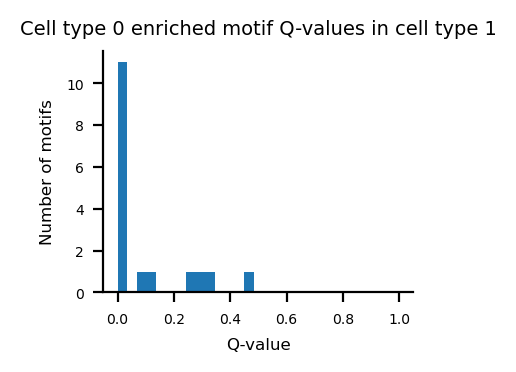

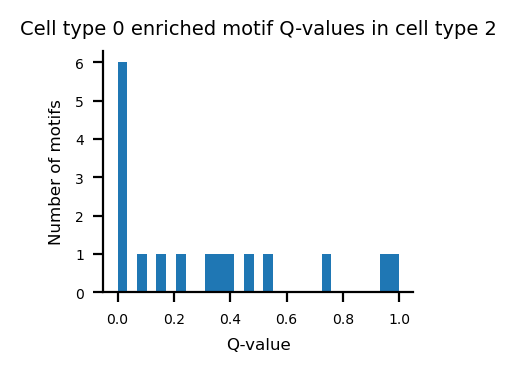

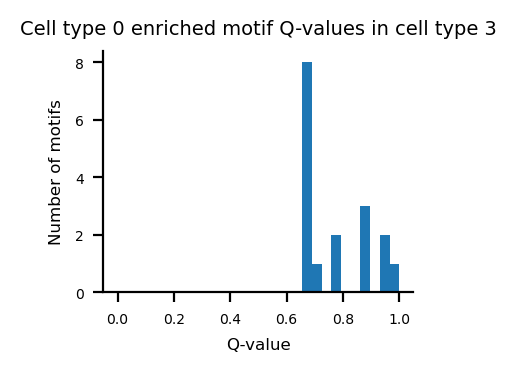

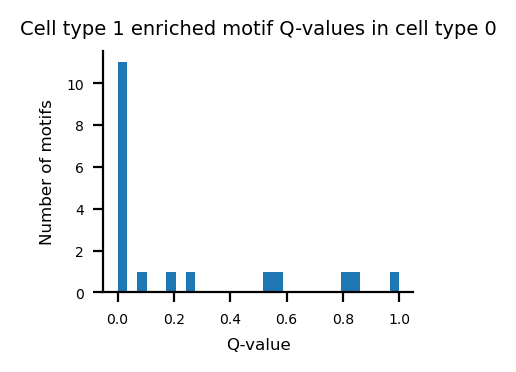

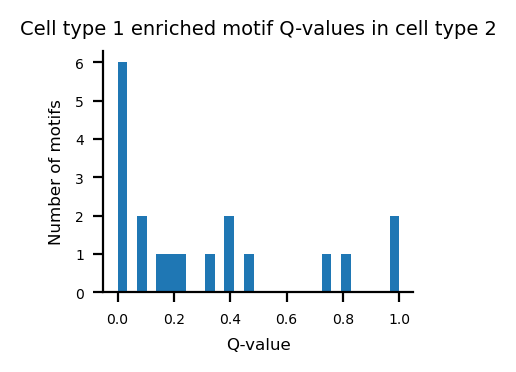

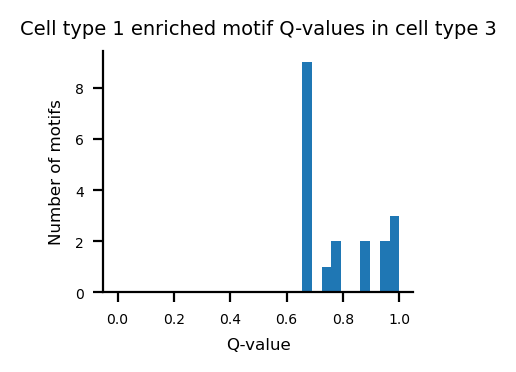

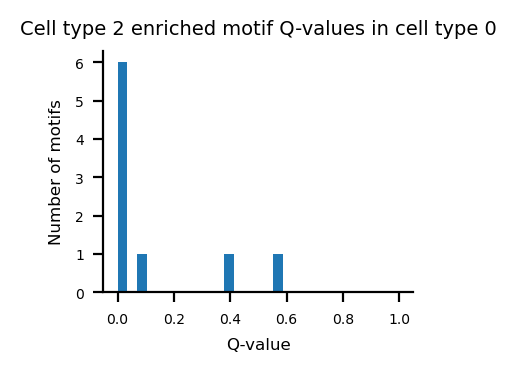

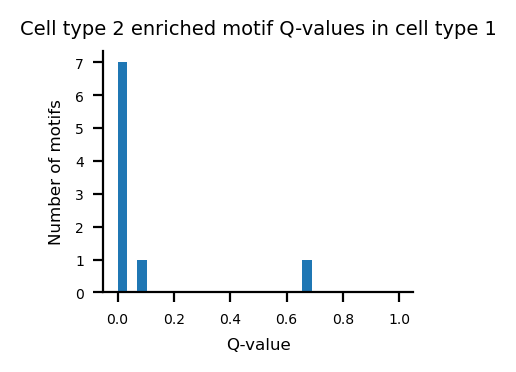

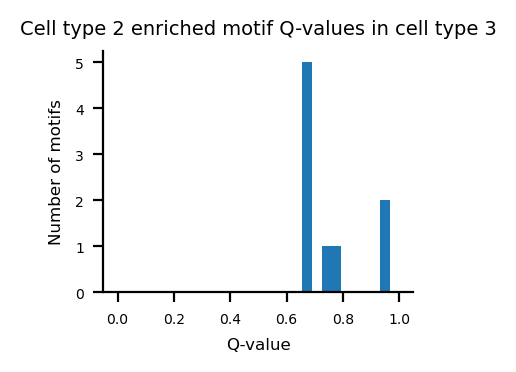

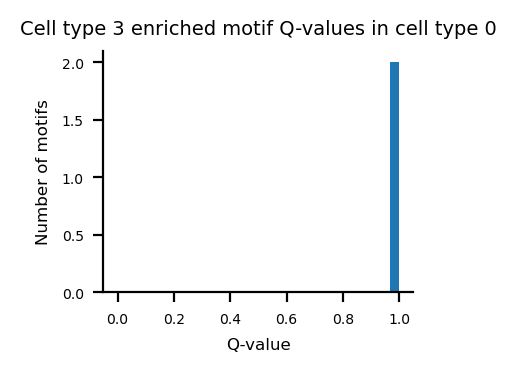

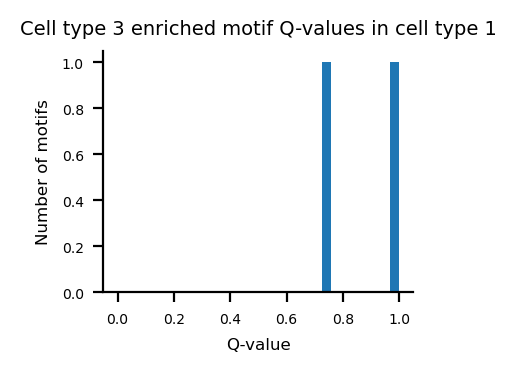

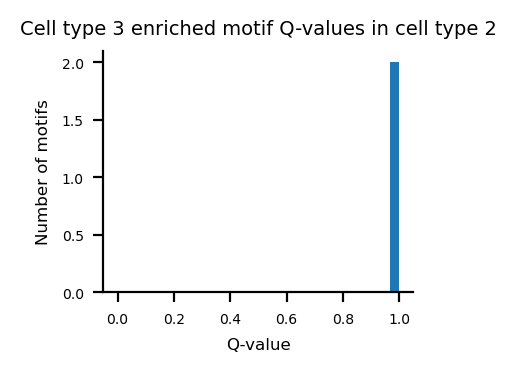

In [220]:
# --- LOOK AT HOW CORRELATED MOTIFS ARE ---


# ** get the enriched motifs for each cell type **
enriched_motif_p_val_dfs = []
for i, motif_p_val_df in enumerate(motif_p_val_dfs):
    enriched_motif_p_val_df = motif_p_val_df[motif_p_val_df['bh_q'] <= 0.10].sort_values(['bh_q'])
    enriched_motif_p_val_dfs.append(enriched_motif_p_val_df)
    
    
# ** for each pair of cell types, look at BH.Q of enriched motifs in the other cell types **
for cell_type_index, enriched_motif_p_val_df in enumerate(enriched_motif_p_val_dfs):
    
    # get the enriched motifs
    enriched_motifs = list(enriched_motif_p_val_df.index)
    
    # look at the Q values in the other cell types
    for cell_type_index_2, enriched_motif_p_val_df_2 in enumerate(enriched_motif_p_val_dfs):
        
        # skip if it's the same cell type
        if cell_type_index_2 == cell_type_index:
            continue
            
        # viz
        fig,ax = plt.subplots(figsize=(2,1.6),dpi=200)
        plt.hist(motif_p_val_dfs[cell_type_index_2].loc[enriched_motifs]['bh_q'],bins=np.linspace(0,1,30))
        plt.xlabel("Q-value")
        plt.ylabel("Number of motifs")
        plt.title("Cell type %s enriched motif Q-values in cell type %s" % (cell_type_index, cell_type_index_2))
        sns.despine()
        plt.show()
        




In [20]:
# --- GET SMC CYCLERS (AND DAWN / DUSK) AND SMC PHENOTYPIC SWITCHIN GENES (AND UP / DOWN) ----

# ** SMC cyclers **

# cycler
smc_cyclers = list(cluster_cycler_metric_dfs[0].index)

# # dawn
# smc_dawn_cyclers = list(cluster_cycler_metric_dfs[0][cluster_cycler_metric_dfs[0]['is_dawn_cycler']].index)

# # dusk
# smc_dusk_cyclers = list(cluster_cycler_metric_dfs[0][~cluster_cycler_metric_dfs[0]['is_dawn_cycler']].index)

# ** SMC phenotypic switching genes **

# DE
smc_switching_de_path = '%s/dropbox/athero_data/preprocessed/RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_scale_True_zero-centered_True_scale-per-batch_False_sample-min-disp_3.0_zsgreen-min_disp_3.0_all-min-disp_0.7/desc_results/subject_RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_dims_128_resolution_0.35_tol_0.005_run_0/pseudotime_X_velocity_results/nichenet_pseudotime-pseudotime_2_numbins-11_binsubset-[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_startdebins-[0]_enddebins-[4]/de_genes.txt' % head_folder
with open(smc_switching_de_path) as file_obj:
    smc_switching_de_genes = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))

# down
smc_switching_down_path = '%s/dropbox/athero_data/preprocessed/RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_scale_True_zero-centered_True_scale-per-batch_False_sample-min-disp_3.0_zsgreen-min_disp_3.0_all-min-disp_0.7/desc_results/subject_RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_dims_128_resolution_0.35_tol_0.005_run_0/pseudotime_X_velocity_results/nichenet_pseudotime-pseudotime_2_numbins-11_binsubset-[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_startdebins-[0]_enddebins-[4]/down_genes.txt' % head_folder
with open(smc_switching_down_path) as file_obj:
    smc_switching_down_genes = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))

# up
smc_switching_up_path = '%s/Dropbox/athero_data/preprocessed/RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_scale_True_zero-centered_True_scale-per-batch_False_sample-min-disp_3.0_zsgreen-min_disp_3.0_all-min-disp_0.7/desc_results/subject_RPS001-RPS002-RPS003-RPS004-RPS007-RPS008-RPS011-RPS012_dims_128_resolution_0.35_tol_0.005_run_0/pseudotime_X_velocity_results/nichenet_pseudotime-pseudotime_2_numbins-11_binsubset-[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]_startdebins-[0]_enddebins-[4]/up_genes.txt' % head_folder
with open(smc_switching_up_path) as file_obj:
    smc_switching_up_genes = list(map(lambda x: x.replace('\n',""), file_obj.readlines()))



In [51]:
# --- GET UP AND DOWN GENES OVER TIME FOR SMC'S ---

# ** set cluster **
cluster = 0
frac_samples_greater_threshold = 0.9
# genes_with_params = list(cluster_cycler_metric_dfs[cluster].index)
genes_with_params = list(cluster_metric_dfs[cluster][cluster_metric_dfs[cluster]['waveform_over_circadian_component_subtracted_log10_bf'] >= 1].index)


# ** sampled log prop **
import torch
sampled_log_prop,genes_with_params = helper_functions.get_log_prop_samples(cluster,description,num_waveform_samples,cluster_description_folder_out_dict,gene_list=genes_with_params)

# ** get the sampled mesor **
sampled_mesor = torch.mean(sampled_log_prop,dim=1)

# ** compute fraction of samples greater than the mesor at each time point **
fraction_samples_greater = torch.mean((sampled_log_prop >= sampled_mesor.unsqueeze(1)).float(),dim=0) # [time points x num_genes]

# get the upregulated genes at each time point
up_genes_over_time = []
for time_index in [0,1,2,3]:
    up_genes = list(np.array(genes_with_params)[np.where(fraction_samples_greater[time_index,:] >= frac_samples_greater_threshold)[0]])
    up_genes_over_time.append(up_genes)

# get the downregulated genes at each time point
down_genes_over_time = []
for time_index in [0,1,2,3]:
    down_genes = list(np.array(genes_with_params)[np.where(fraction_samples_greater[time_index,:] <= 1.0 - frac_samples_greater_threshold)[0]])
    down_genes_over_time.append(down_genes)

        



In [52]:
fft_sampled = np.fft.fft(sampled_log_prop.numpy(),axis=1)
acrophase_samples = (np.arctan2(fft_sampled[:,circadian_index.item(),:].imag,fft_sampled[:,circadian_index.item(),:].real) % (2 * np.pi))
acrophase_samples = ((2 * np.pi) - acrophase_samples) % (2 * np.pi)
smc_switching_up_cycling_genes = list(set(genes_with_params).intersection(set(smc_switching_up_genes)))
smc_switching_down_cycling_genes = list(set(genes_with_params).intersection(set(smc_switching_down_genes)))
smc_switching_up_cycling_gene_indices = np.where(np.isin(genes_with_params, smc_switching_up_cycling_genes))[0]
smc_switching_down_cycling_gene_indices = np.where(np.isin(genes_with_params, smc_switching_down_cycling_genes))[0]

gene_indices = np.where(np.isin(genes_with_params, gene_set_dict_of_dicts['klf4_oct4_targets']['klf_smc_targets_1']))[0]




In [59]:
gene_set_dict_of_dicts['smc_switching']['up']

['Ifitm3',
 'Mgp',
 'Ftl1',
 'Cd63',
 'Frzb',
 'Cxcl12',
 'Sncg',
 'Tm4sf1',
 'Vcam1',
 'Arpc1b',
 'Tmem176b',
 'Mt1',
 'Timp1',
 'Timp2',
 'Mt2',
 'Nbl1',
 'Ldha',
 'Tpm4',
 'Mgst1',
 'Sfrp2',
 'Cdo1',
 'Crispld2',
 'Col3a1',
 'Apoe',
 'Fn1',
 'Bgn',
 'Col1a1',
 'B2m',
 'Ctsl',
 'Myl12a',
 'Sulf2',
 'Cd200',
 'Tmem176a',
 'Gm12840',
 'Scn1b',
 'Fbln5',
 'Lgals3',
 'Tspo',
 'Nupr1',
 'Serping1',
 'Col1a2',
 'Ppic',
 'Cebpd',
 'Hexa',
 'S100a11',
 'Tsc22d1',
 'Gas6',
 'Rhoc',
 'Psme2',
 'Gja1',
 'Cfh',
 'Plpp3',
 'Clu',
 'Dcn',
 'Ifitm2',
 'Tmsb10',
 'Dbi',
 'Rnase4',
 'Lox',
 'Serpinh1',
 'Tspan4',
 'Abi3bp',
 'Sod3',
 'Anxa5',
 'Tuba1b',
 'Fxyd5',
 'Tuba1a',
 'Stat3',
 'Plvap',
 'C4b',
 'Ltbp3',
 'Lxn',
 'Cstb',
 'Rgs5',
 'Flot1',
 'Pcolce',
 'Nudt4',
 'Sec61b',
 'Npdc1',
 'Mprip',
 'Shisa5',
 'Adamts2',
 'Fuca1',
 'Ccdc80',
 'Clic1',
 'Phlda3',
 'Ace',
 'Mia',
 'Lgmn',
 'Cx3cl1',
 'Cd302',
 'Lum',
 'Lmo4',
 'Tcf4',
 'Nme1',
 'Cyba',
 'Sparc',
 'C1ra',
 'Tnfrsf1a',
 'Capg',
 'Col5a2',

In [62]:
np.array(np.array(genes_with_params)[gene_indices])

array(['Dbi', 'Tspan4', 'Frzb', 'Tm4sf1', 'Mt1', 'Crispld2', 'Smoc1',
       'Ifitm3', 'Col14a1', 'Tuba1b', 'Ccdc80', 'Aebp1', 'Gm12840',
       'Cdo1', 'Sncg', 'Tmsb10', 'Capg', 'Cebpd', 'Lox', 'Nfkbia', 'Lxn',
       'Mgp', 'Sfrp2', 'Nudt4', 'Plvap', 'Timp1', 'Mt2', 'Rhoc', 'C4b',
       'Cd200'], dtype='<U13')

30


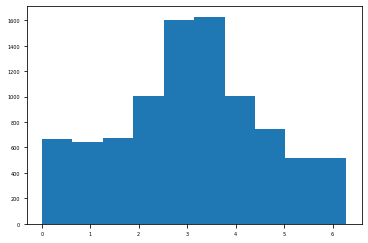

In [61]:
gene_indices = np.where(np.isin(genes_with_params, gene_set_dict_of_dicts['smc_switching']['up']))[0]

print(len(gene_indices))
plt.clf()
plt.hist(acrophase_samples[:,gene_indices].flatten())
plt.show()




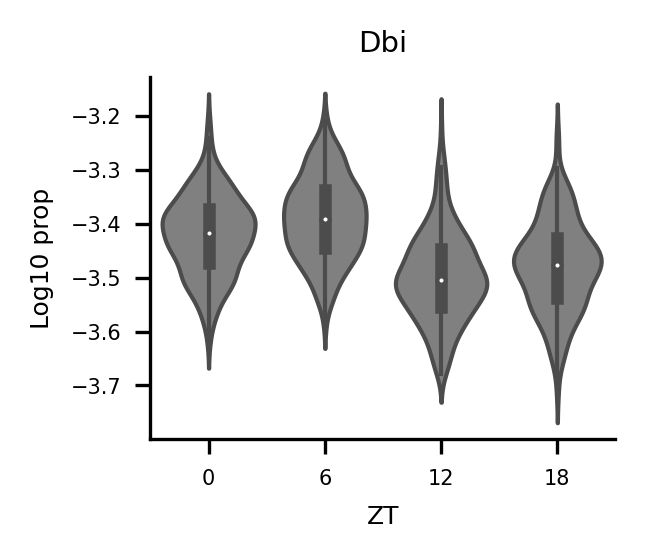

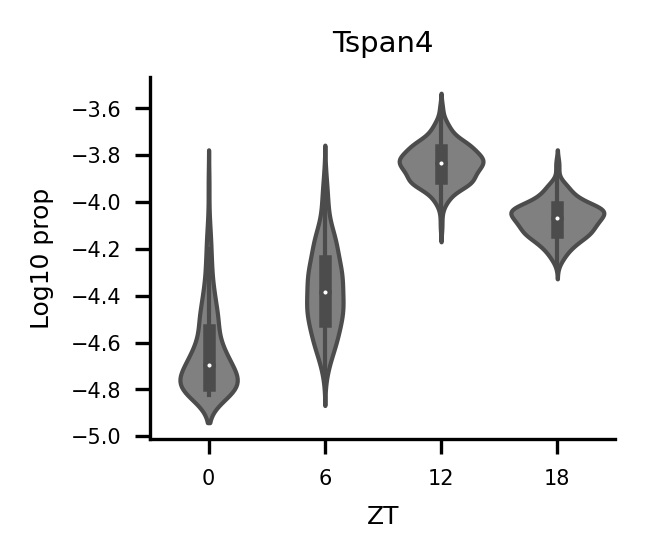

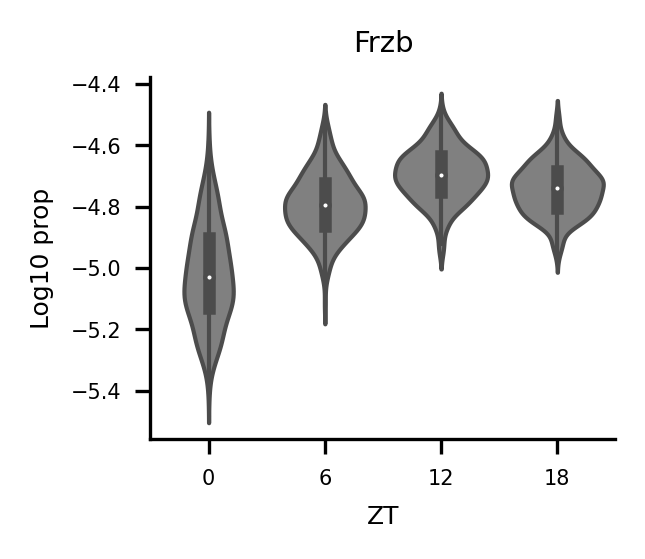

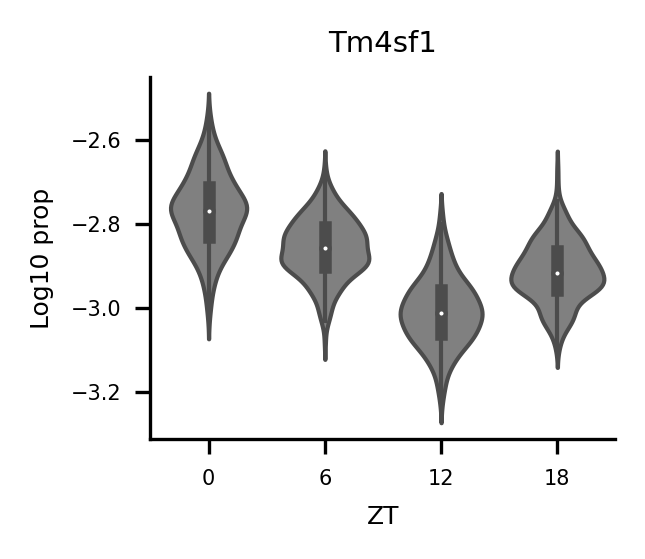

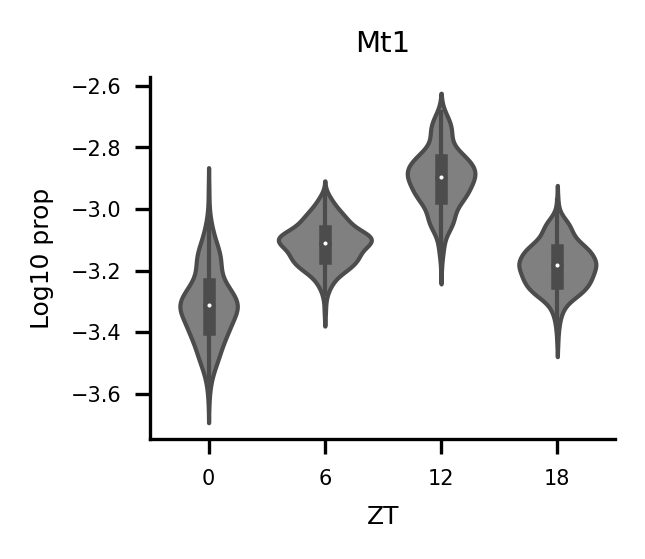

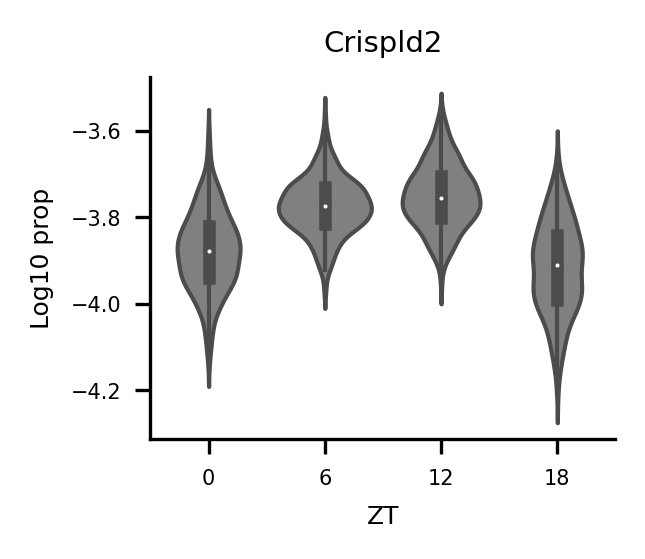

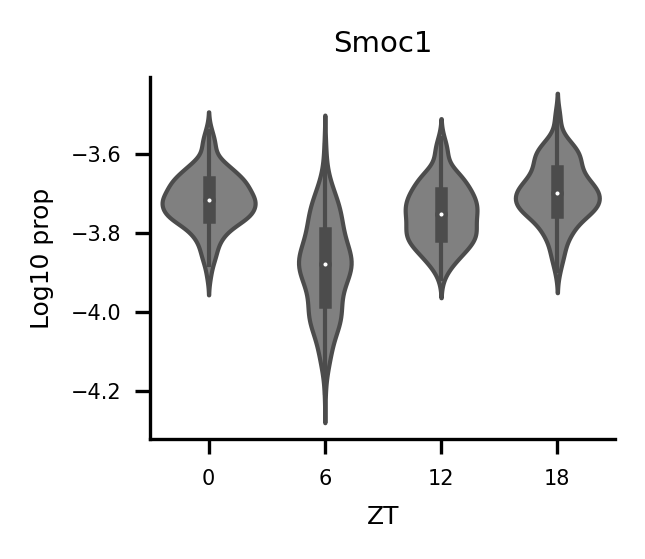

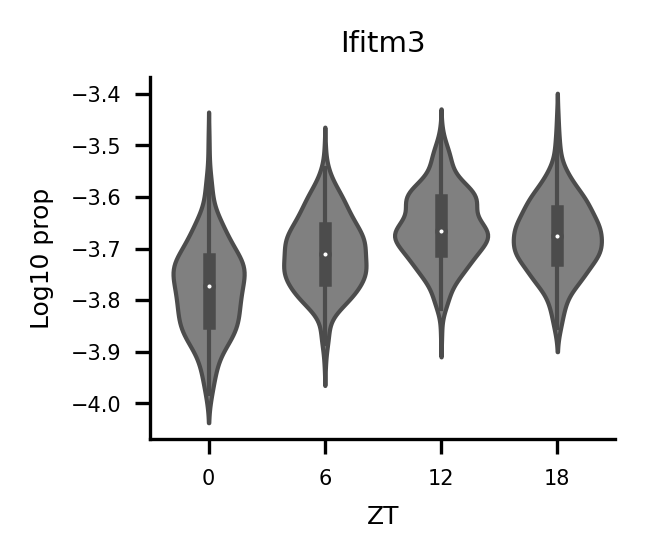

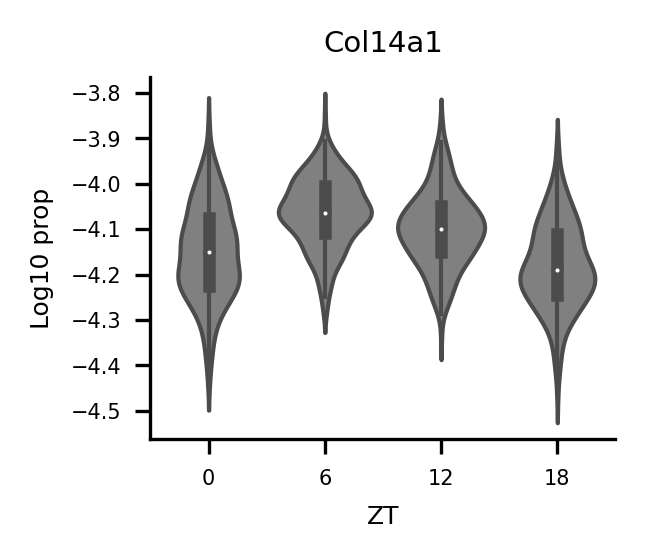

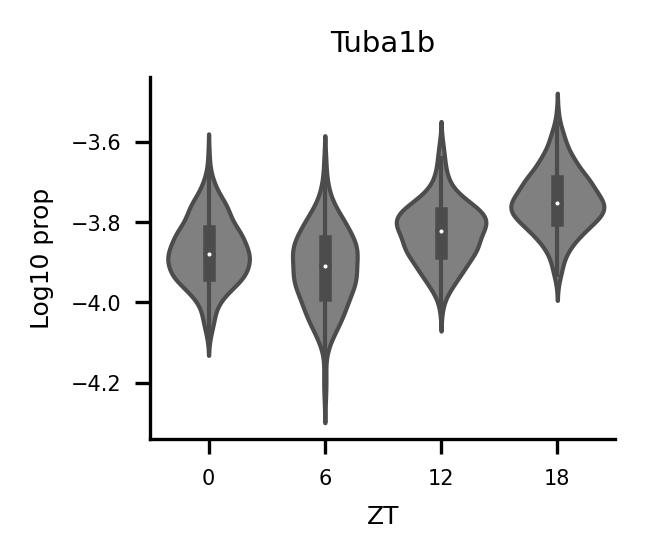

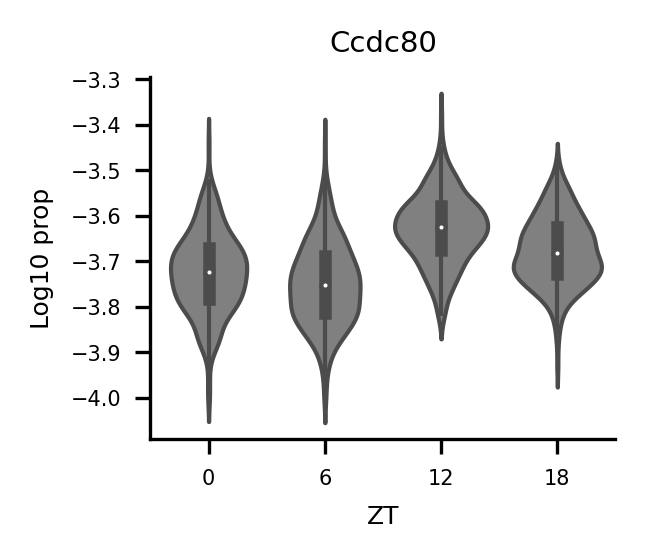

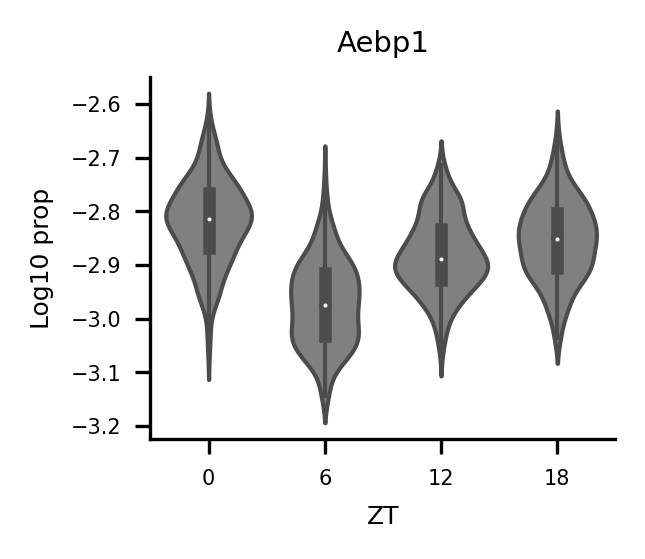

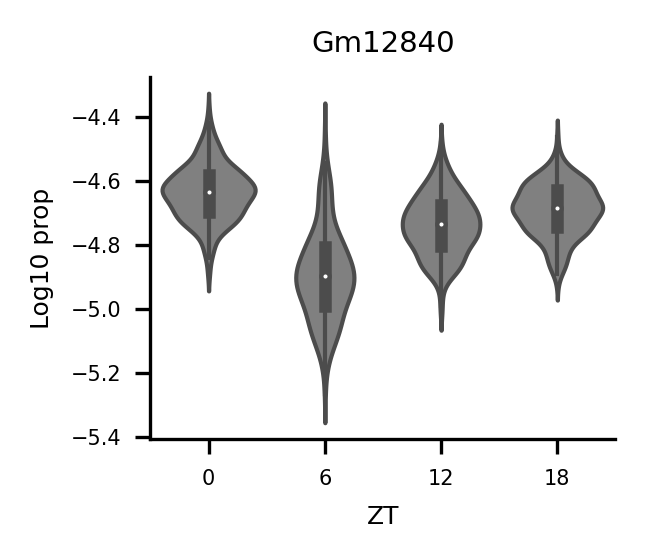

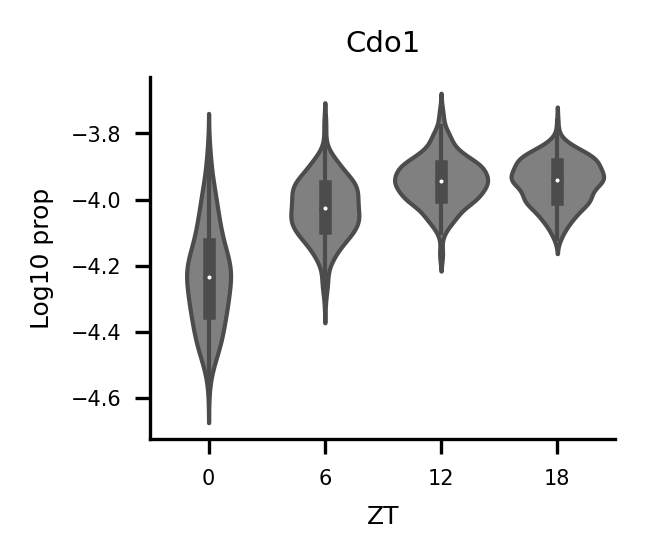

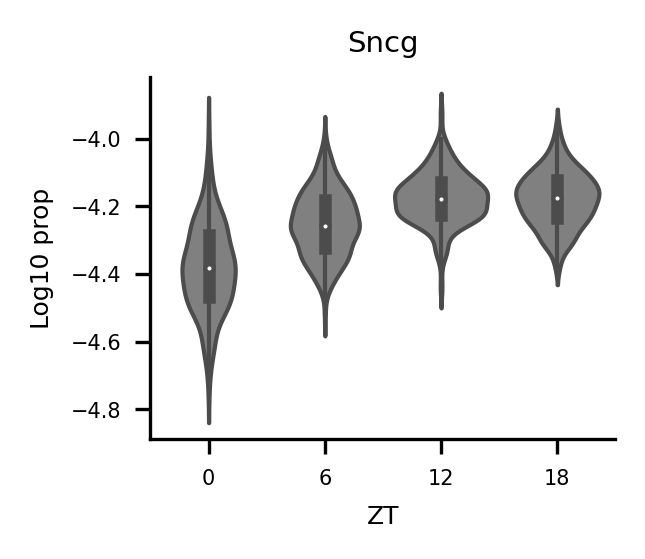

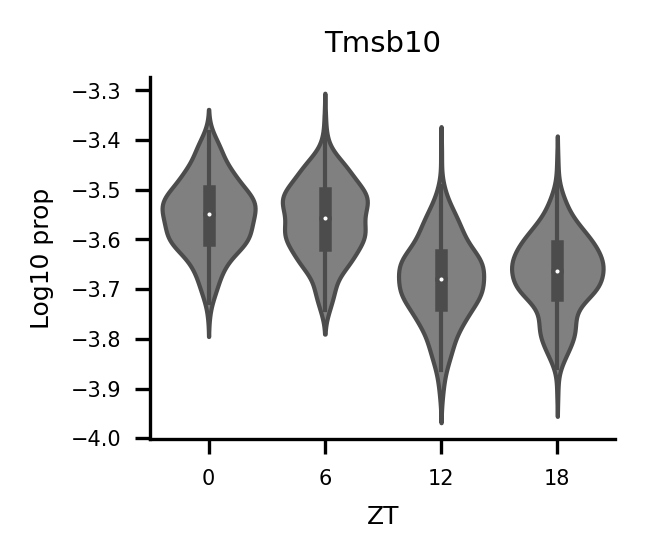

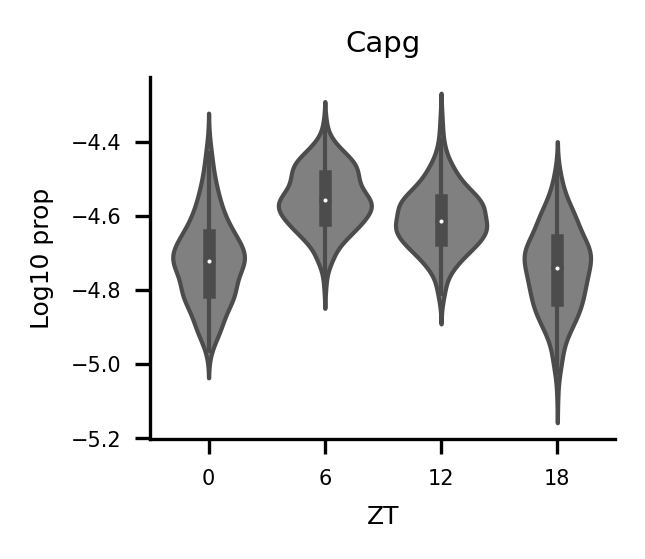

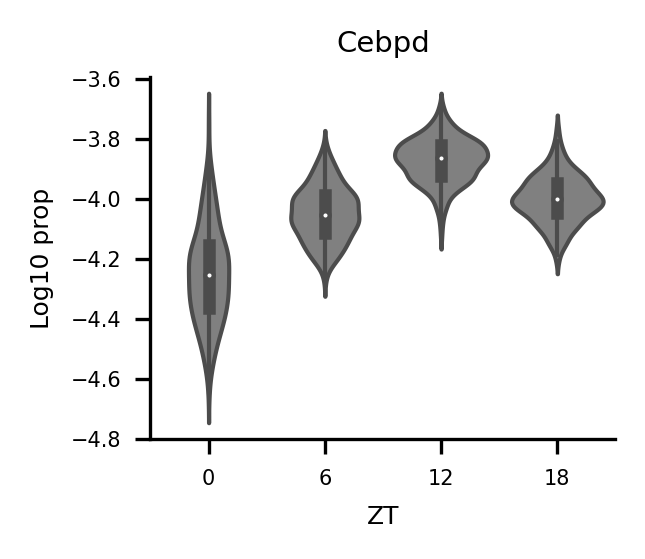

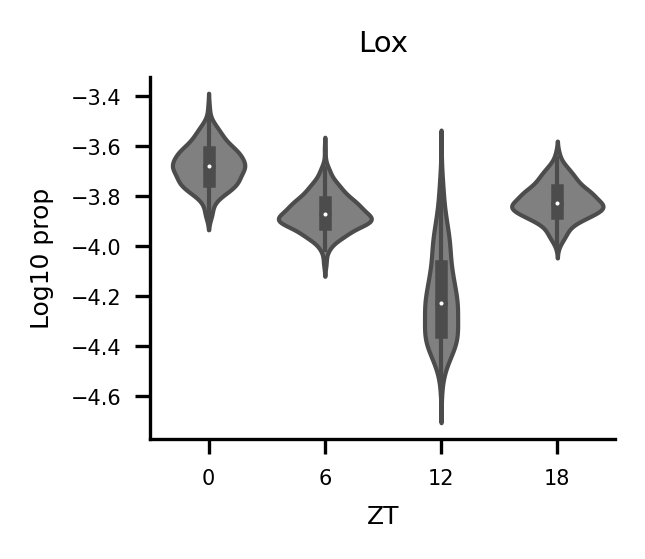

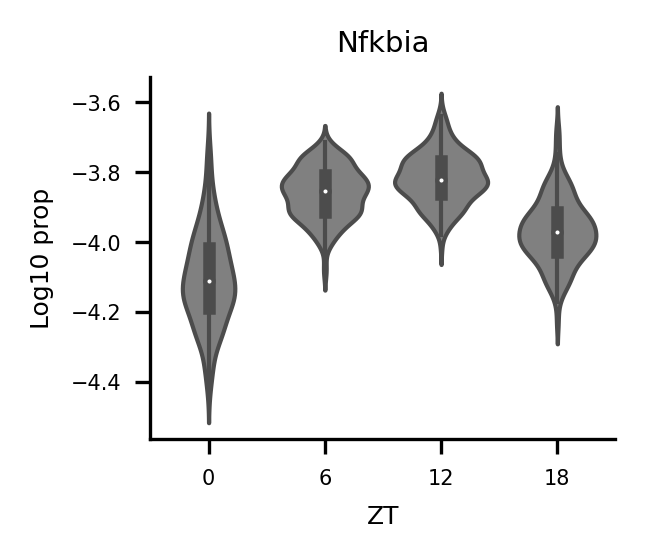

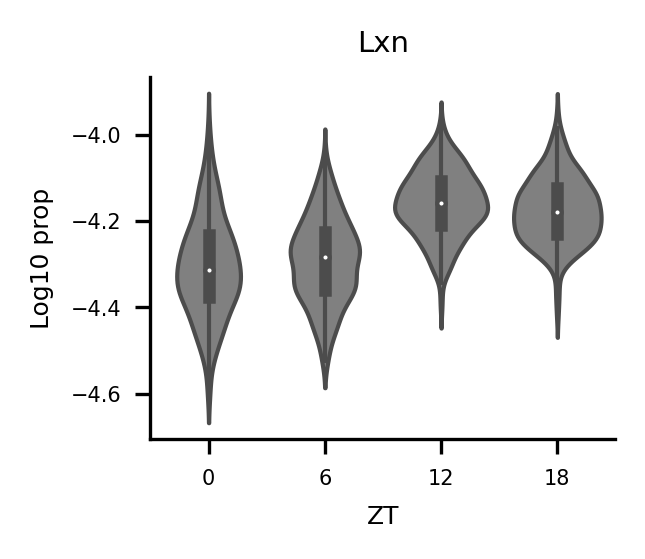

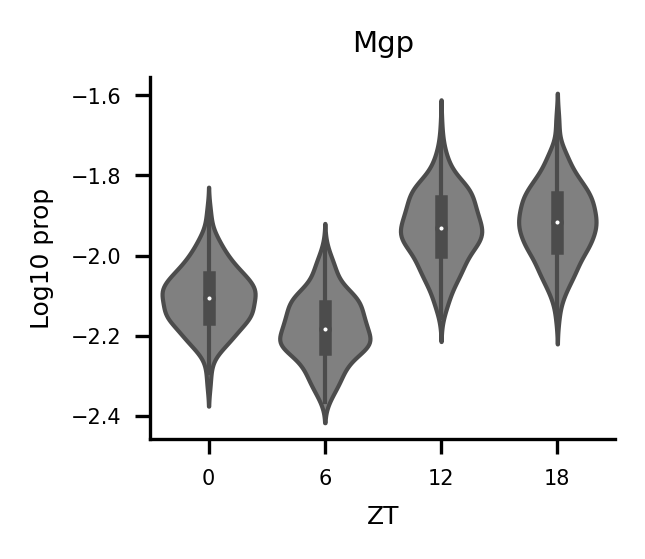

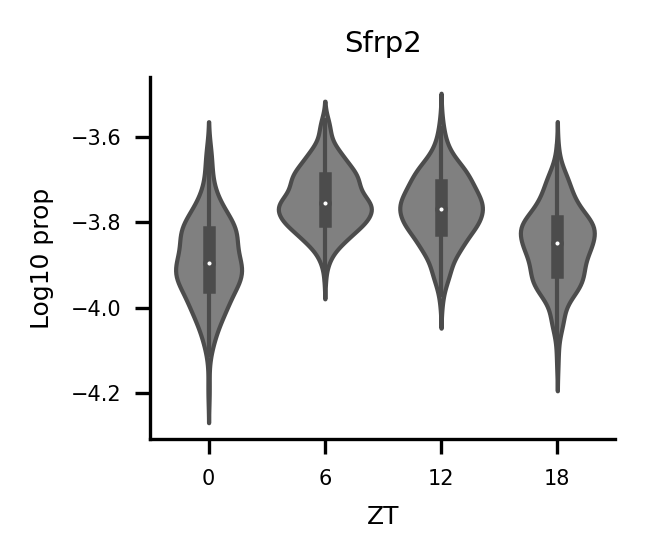

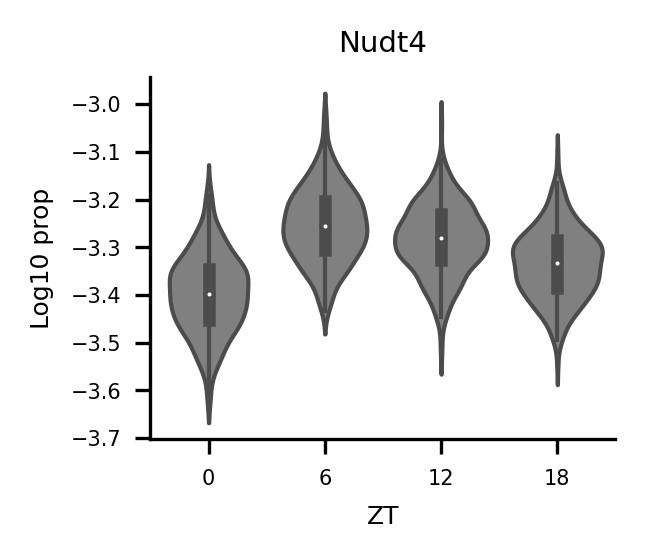

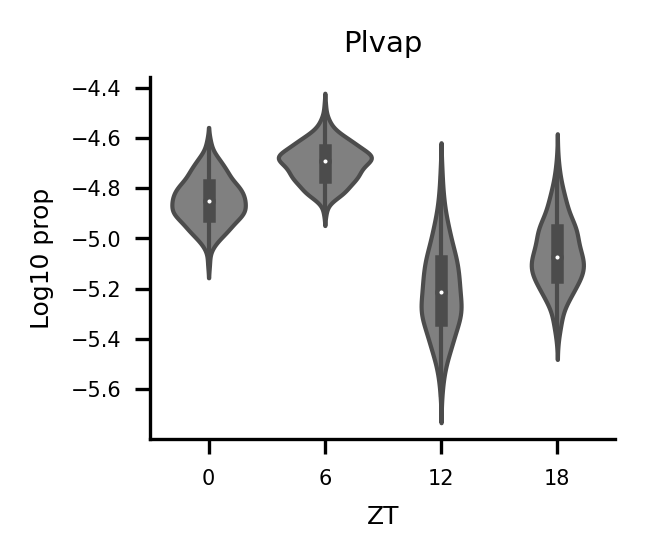

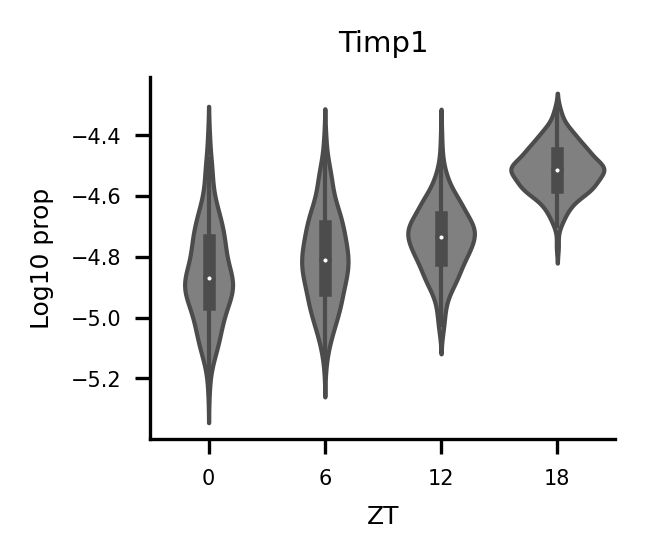

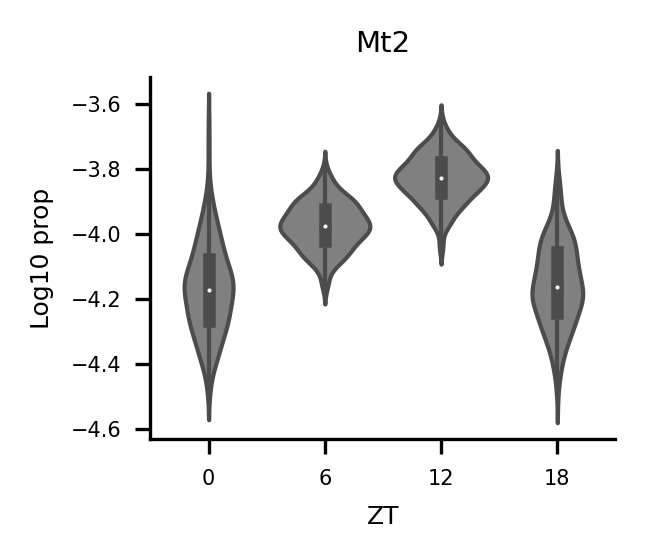

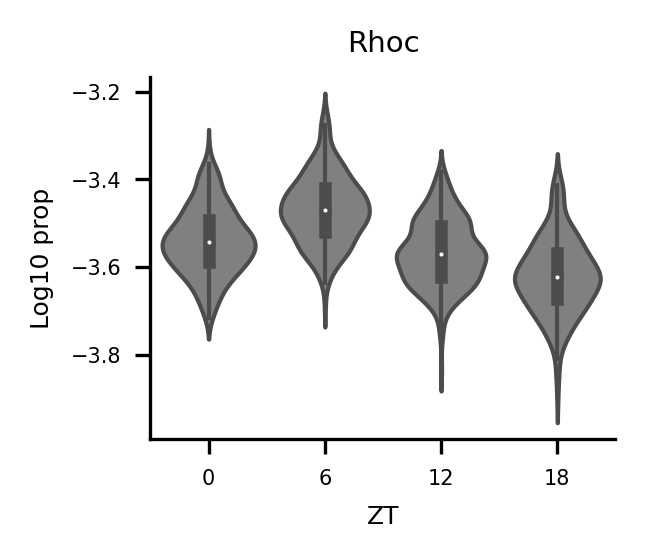

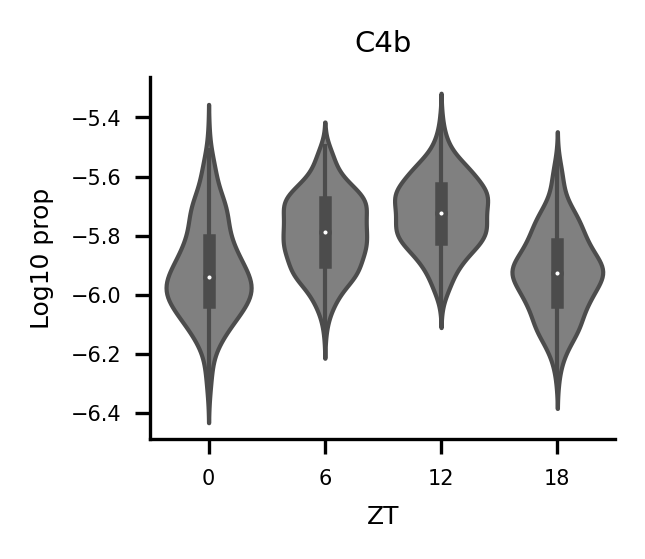

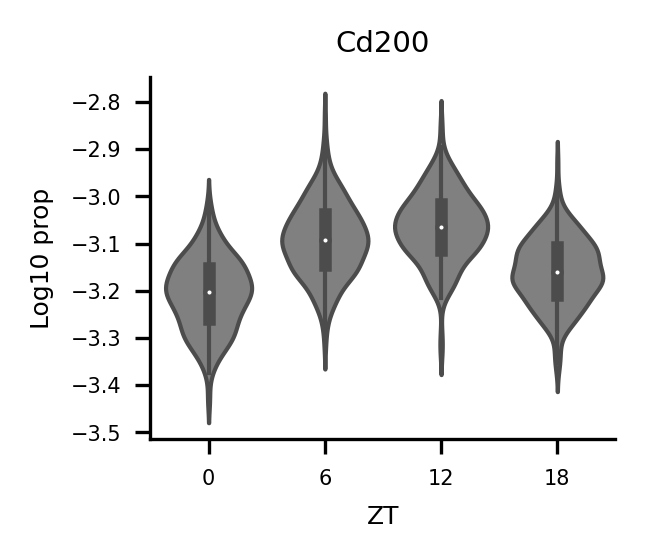

In [63]:
for gene in np.array(np.array(genes_with_params)[gene_indices]):
    gene_index = np.where(np.array(genes_with_params) == gene)[0].item()


    # get min and max vals for the gene
    min_val = torch.min(sampled_log_prop[:,:,gene_index].flatten()).item() / np.log(10)
    max_val = torch.max(sampled_log_prop[:,:,gene_index].flatten()).item() / np.log(10)


    # make gene df
    val_mat = sampled_log_prop[:,:,gene_index]
    time_mat = np.zeros((sampled_log_prop.shape[0], 4))
    time_mat[:,0] = 0
    time_mat[:,1] = 6
    time_mat[:,2] = 12
    time_mat[:,3] = 18
    gene_df = pd.DataFrame()
    gene_df['ZT'] = time_mat.flatten().astype(int)
    gene_df['Log10 prop'] = val_mat.flatten().numpy() / np.log(10)


    # viz
    fig,ax=plt.subplots(figsize=(2,1.6),dpi=300)
    sns.despine()
    sns.violinplot(x="ZT", y="Log10 prop", data=gene_df,ax=ax,color='0.5')
#     viz_subfolder_out = '%s/enriched_term_example_genes/%s' % (subfolder_out,term)
#     if not os.path.exists(viz_subfolder_out):
#         os.makedirs(viz_subfolder_out)
#     fileout = '%s/%s.pdf' % (viz_subfolder_out,gene)
#     plt.savefig(fileout,bbox_inches='tight')
    plt.title(gene)
    plt.show()
    
    

In [841]:
# # # --- ARE SMC CYCLERS ENRICHED FOR GENES CHANGING OVER SMC PHENOTYPIC SWITCHING ---


# # num shuffles
# num_shuffles = 1000

# # compute the statistic for the circadian cyclers
# circadian_cycler_stat = len(set(up_genes_over_time[1]).intersection(set(smc_switching_up_genes)))

# # generate the null distribution
# # background_gene_set = list(adata.var_names)
# background_gene_set = reg_genes_to_est
# null_dist = []
# for shuffle in range(0,num_shuffles):
#     random_genes = np.random.choice(background_gene_set,size=len(up_genes_over_time[1]),replace=True)
#     null_stat = len(set(random_genes).intersection(set(smc_switching_up_genes)))
#     null_dist.append(null_stat)




# print(scipy.stats.percentileofscore(null_dist,circadian_cycler_stat))    



# # Upregulated enrichment:
# # SMC switch up: 73.15, 35.3, 99.85, 97.55
# # SMC switch down: 99.45, 99.8, 98.85, 36.7


# # Downregulated enrichment:
# # SMC switch up: 100.0, 83.85, 92.6, 21.95
# # SMC switch down: 91.8, 64.65, 94.9, 98.35


21.95


smc_cyclers: smc_phenotypic_switch_de


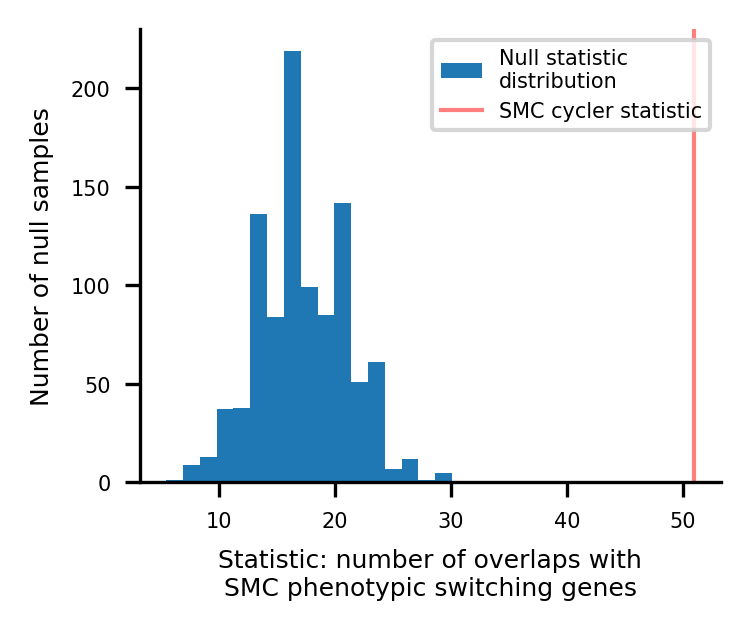

100.0
smc_cyclers: smc_phenotypic_switch_down


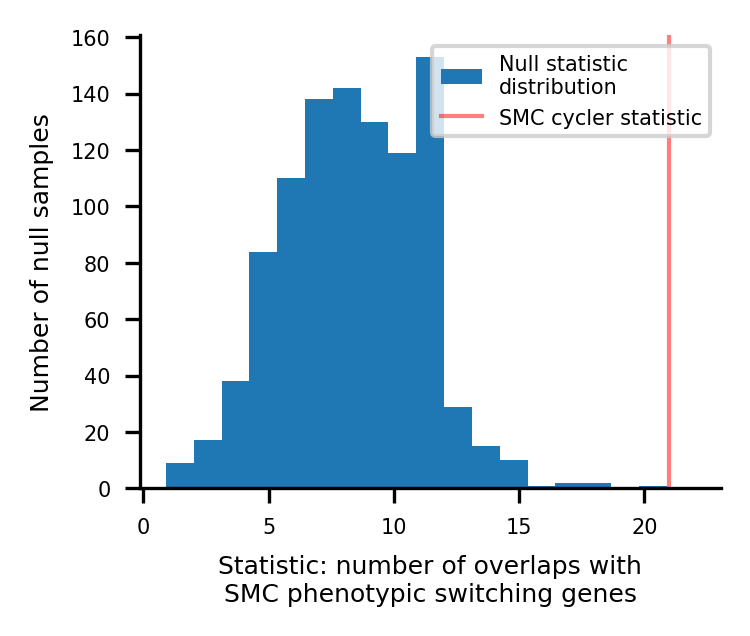

100.0
smc_cyclers: smc_phenotypic_switch_up


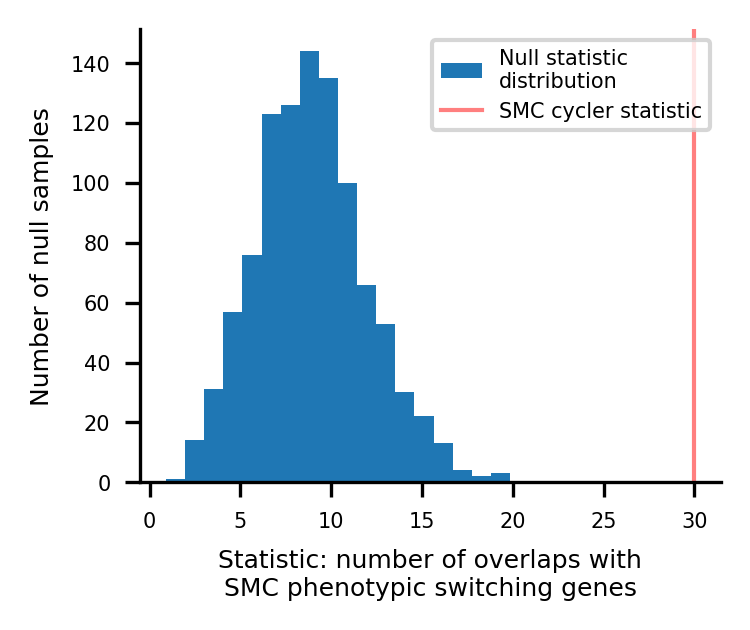

100.0
smc_dawn_cyclers: smc_phenotypic_switch_de


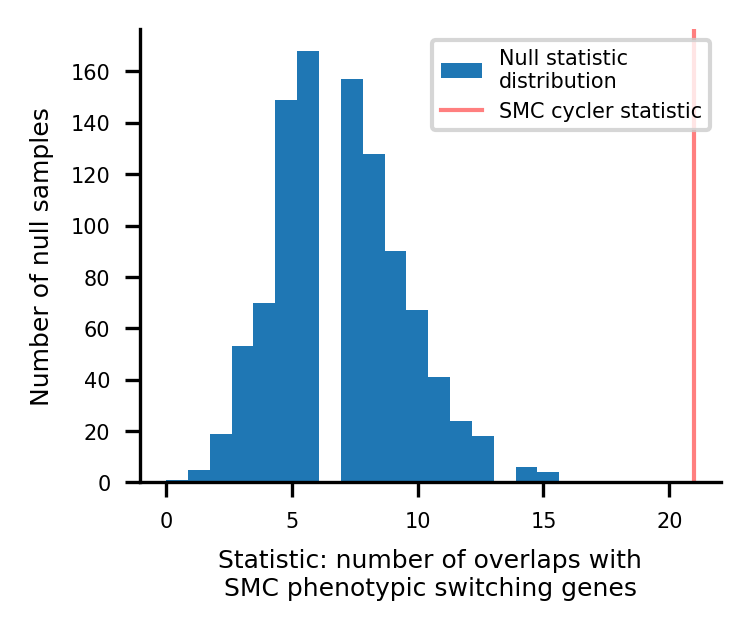

100.0
smc_dawn_cyclers: smc_phenotypic_switch_down


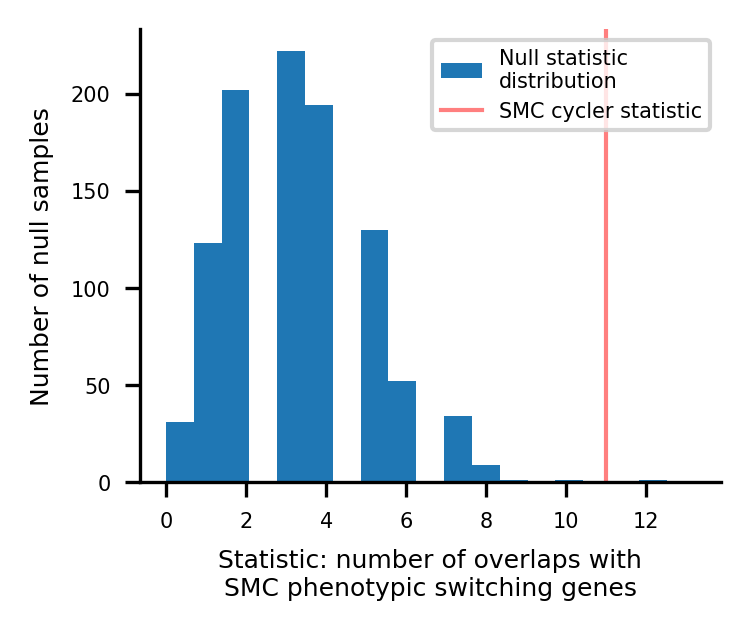

99.9
smc_dawn_cyclers: smc_phenotypic_switch_up


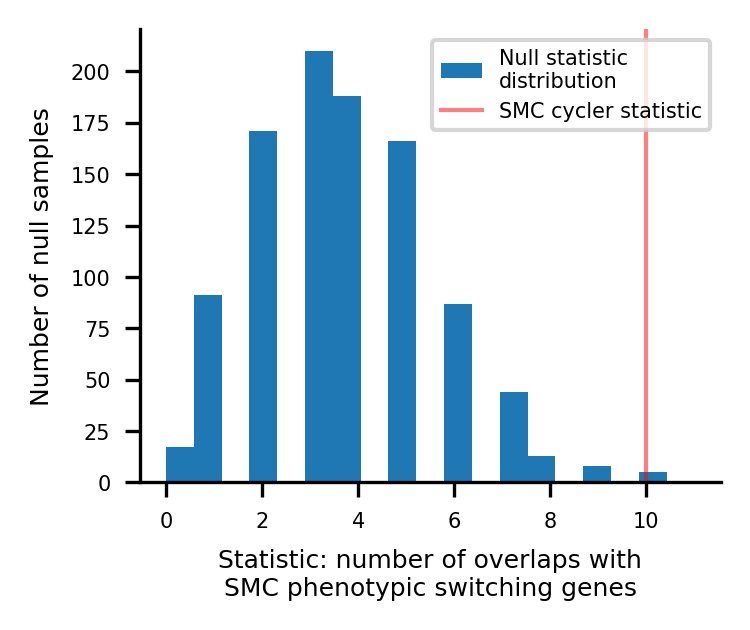

99.8
smc_dusk_cyclers: smc_phenotypic_switch_de


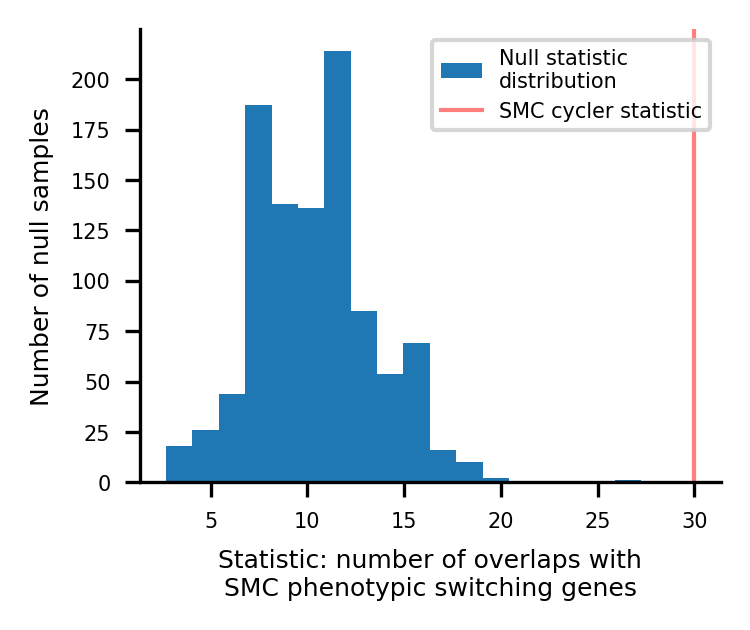

100.0
smc_dusk_cyclers: smc_phenotypic_switch_down


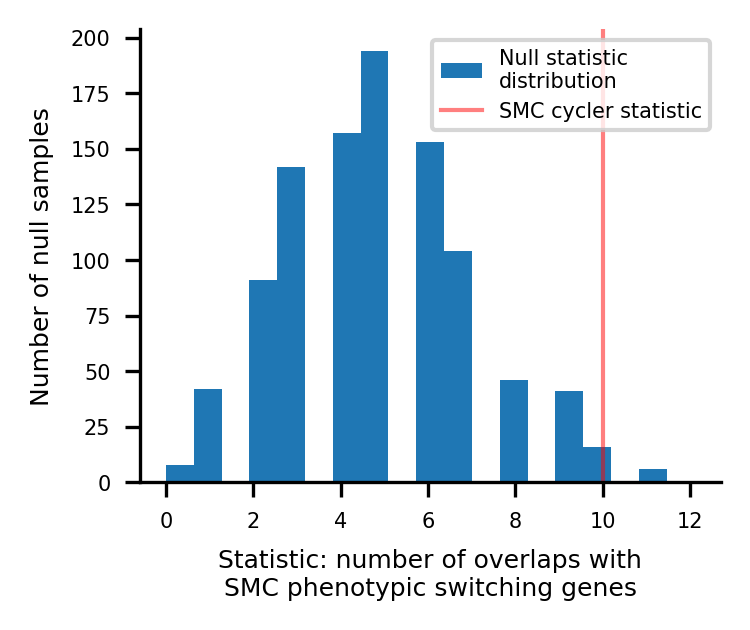

98.65
smc_dusk_cyclers: smc_phenotypic_switch_up


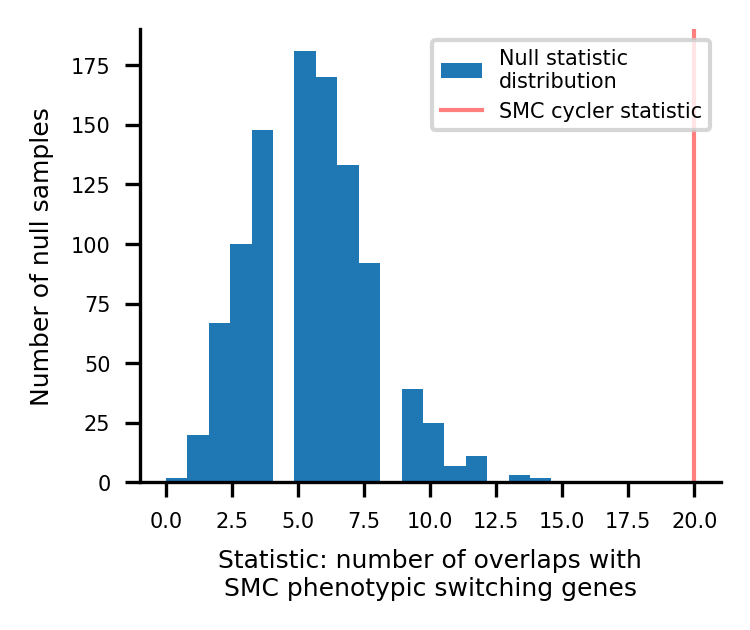

100.0


In [274]:
# # --- ARE SMC CYCLERS ENRICHED FOR GENES CHANGING OVER SMC PHENOTYPIC SWITCHING ---




# # num shuffles
# num_shuffles = 1000

# for smc_cycler_set,smc_cycler_annotation in zip([smc_cyclers,smc_dawn_cyclers,smc_dusk_cyclers],['smc_cyclers','smc_dawn_cyclers','smc_dusk_cyclers']):
#     for smc_switch_set,smc_switch_annotation in zip([smc_switching_de_genes,smc_switching_down_genes,smc_switching_up_genes],['smc_phenotypic_switch_de','smc_phenotypic_switch_down','smc_phenotypic_switch_up']):

#         print('%s: %s' % (smc_cycler_annotation, smc_switch_annotation))
        
#         # compute the statistic for the circadian cyclers
#         circadian_cycler_stat = len(set(smc_cycler_set).intersection(set(smc_switch_set)))

#         # generate the null distribution
#         # background_gene_set = list(adata.var_names)
#         background_gene_set = reg_genes_to_est
#         null_dist = []
#         for shuffle in range(0,num_shuffles):
#             random_genes = np.random.choice(background_gene_set,size=len(smc_cycler_set),replace=True)
#             null_stat = len(set(random_genes).intersection(set(smc_switch_set)))
#             null_dist.append(null_stat)


#         # ** viz **
#         starting_bin = max(np.min(null_dist) * 0.9,0)
#         ending_bin = np.max(null_dist) * 1.1
#         num_bins = 20
#         fig, ax = plt.subplots(figsize = (2.5,2),dpi=300)
#         plt.hist(null_dist,bins=np.linspace(starting_bin,ending_bin,num_bins),label='Null statistic\ndistribution')
#         sns.despine()
#         plt.axvline(x = circadian_cycler_stat,c='r',label='SMC cycler statistic',alpha=0.5)
#         plt.legend()
#         plt.xlabel("Statistic: number of overlaps with\nSMC phenotypic switching genes")
#         plt.ylabel("Number of null samples")
#         fileout = '%s/%s_enrichment_of_%s.pdf' % (folder_out,smc_switch_annotation,smc_cycler_annotation)
#         plt.savefig(fileout,bbox_inches='tight')
#         plt.show()

#         print(scipy.stats.percentileofscore(null_dist,circadian_cycler_stat))    
    
    

    
    
    



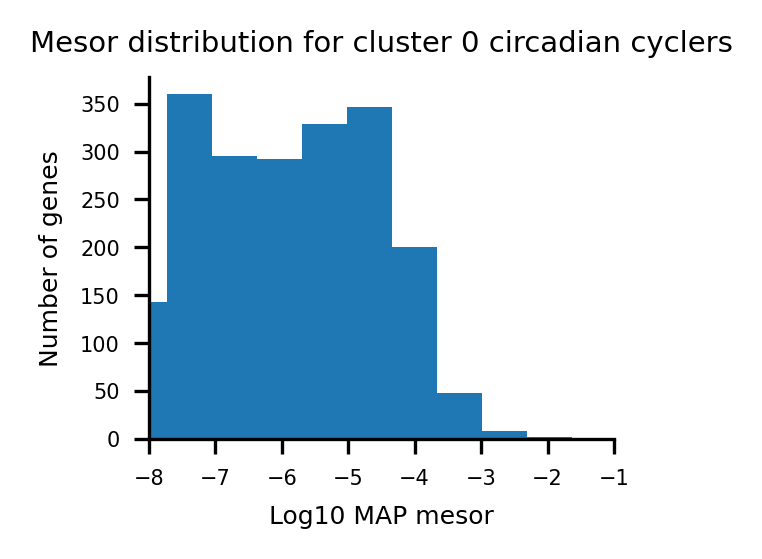

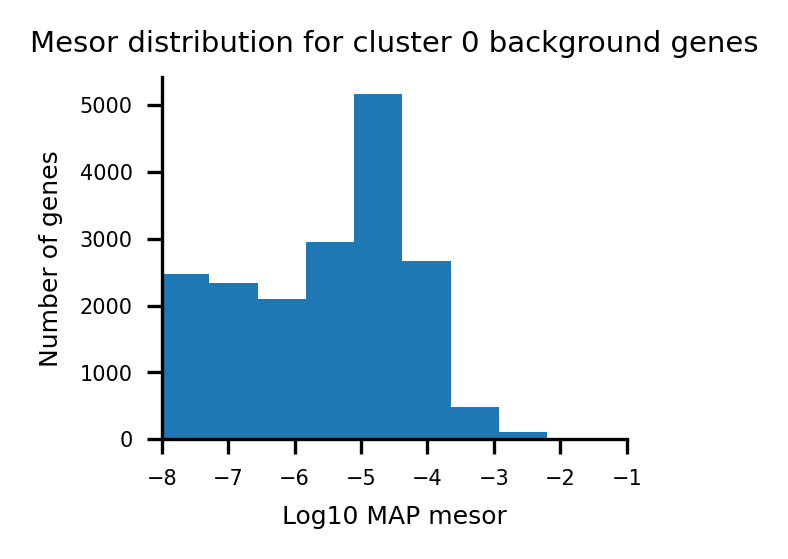

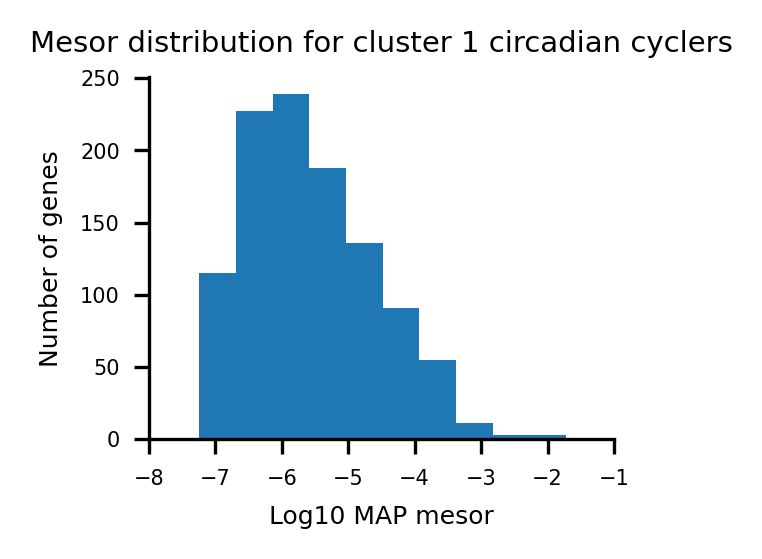

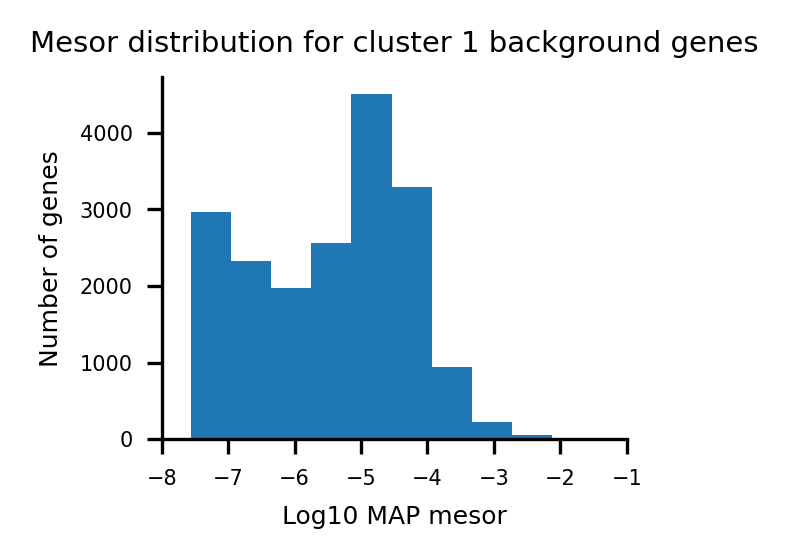

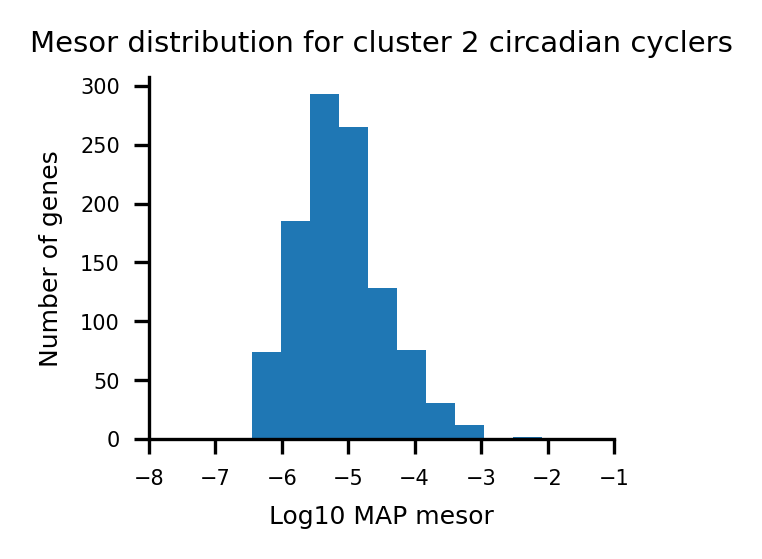

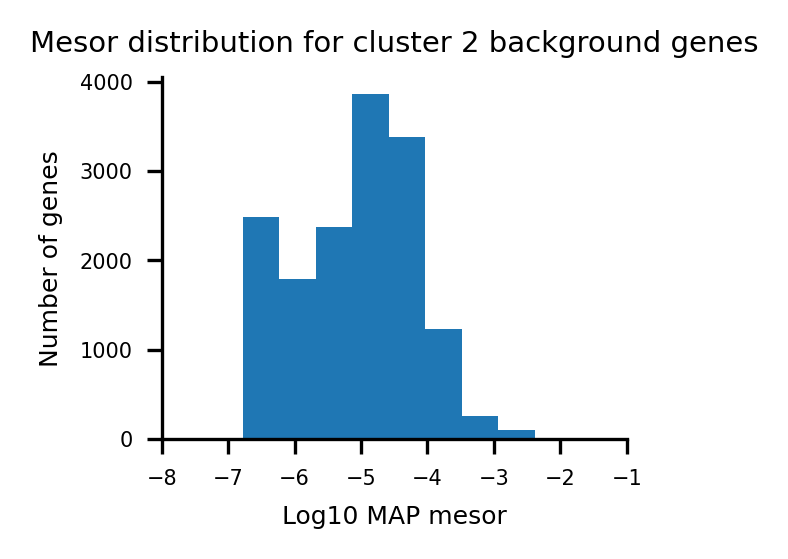

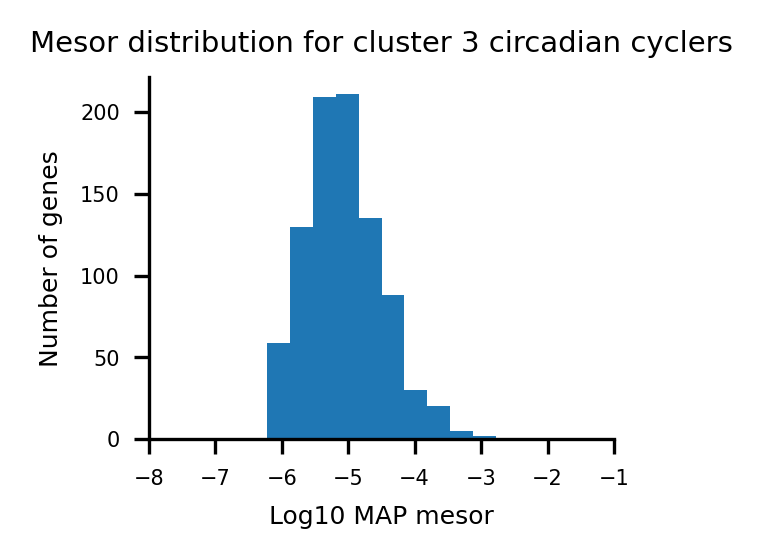

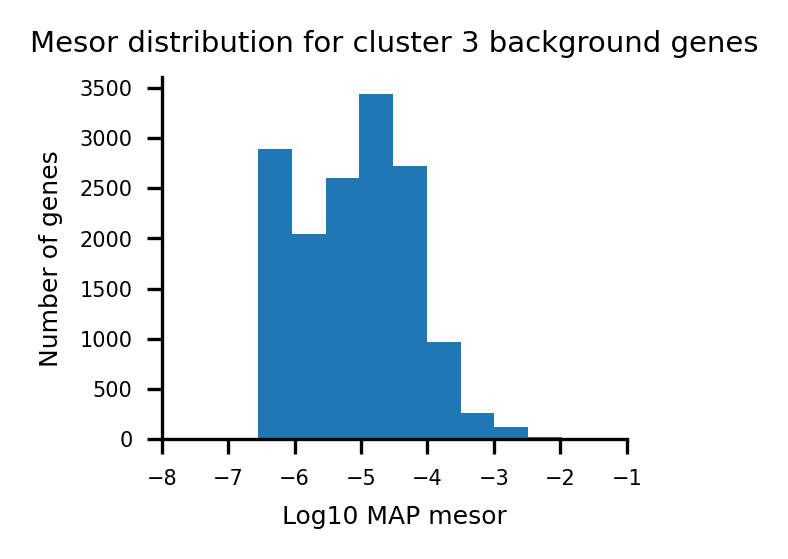

In [33]:
# # --- RELATIVE TO BACKGROUND SET, DO SMC CYCLERS HAVE PARTICULARLY HIGH MESORS? ---



# for cluster,metric_df,cycler_metric_df in zip(clusters,cluster_metric_dfs,cluster_cycler_metric_dfs):
        
    
#     # ** visualize the expected mesor distribution for cyclers **
#     fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
#     plt.hist(cycler_metric_df['expected_mesor'] / np.log(10))
#     sns.despine()
#     plt.xlim((-8,-1))
#     plt.xlabel("Log10 MAP mesor")
#     plt.ylabel("Number of genes")
#     plt.title("Mesor distribution for cluster %s circadian cyclers" % cluster)
#     plt.show()


#     # ** visualize the expected mesor distribution for background genes **
#     fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
#     plt.hist(metric_df['expected_mesor'] / np.log(10))
#     sns.despine()
#     plt.xlim((-8,-1))
#     plt.xlabel("Log10 MAP mesor")
#     plt.ylabel("Number of genes")
#     plt.title("Mesor distribution for cluster %s background genes" % cluster)
#     plt.show()
    
    
    

    
    




NameError: name 'get_log_prop_samples_and_fft' is not defined

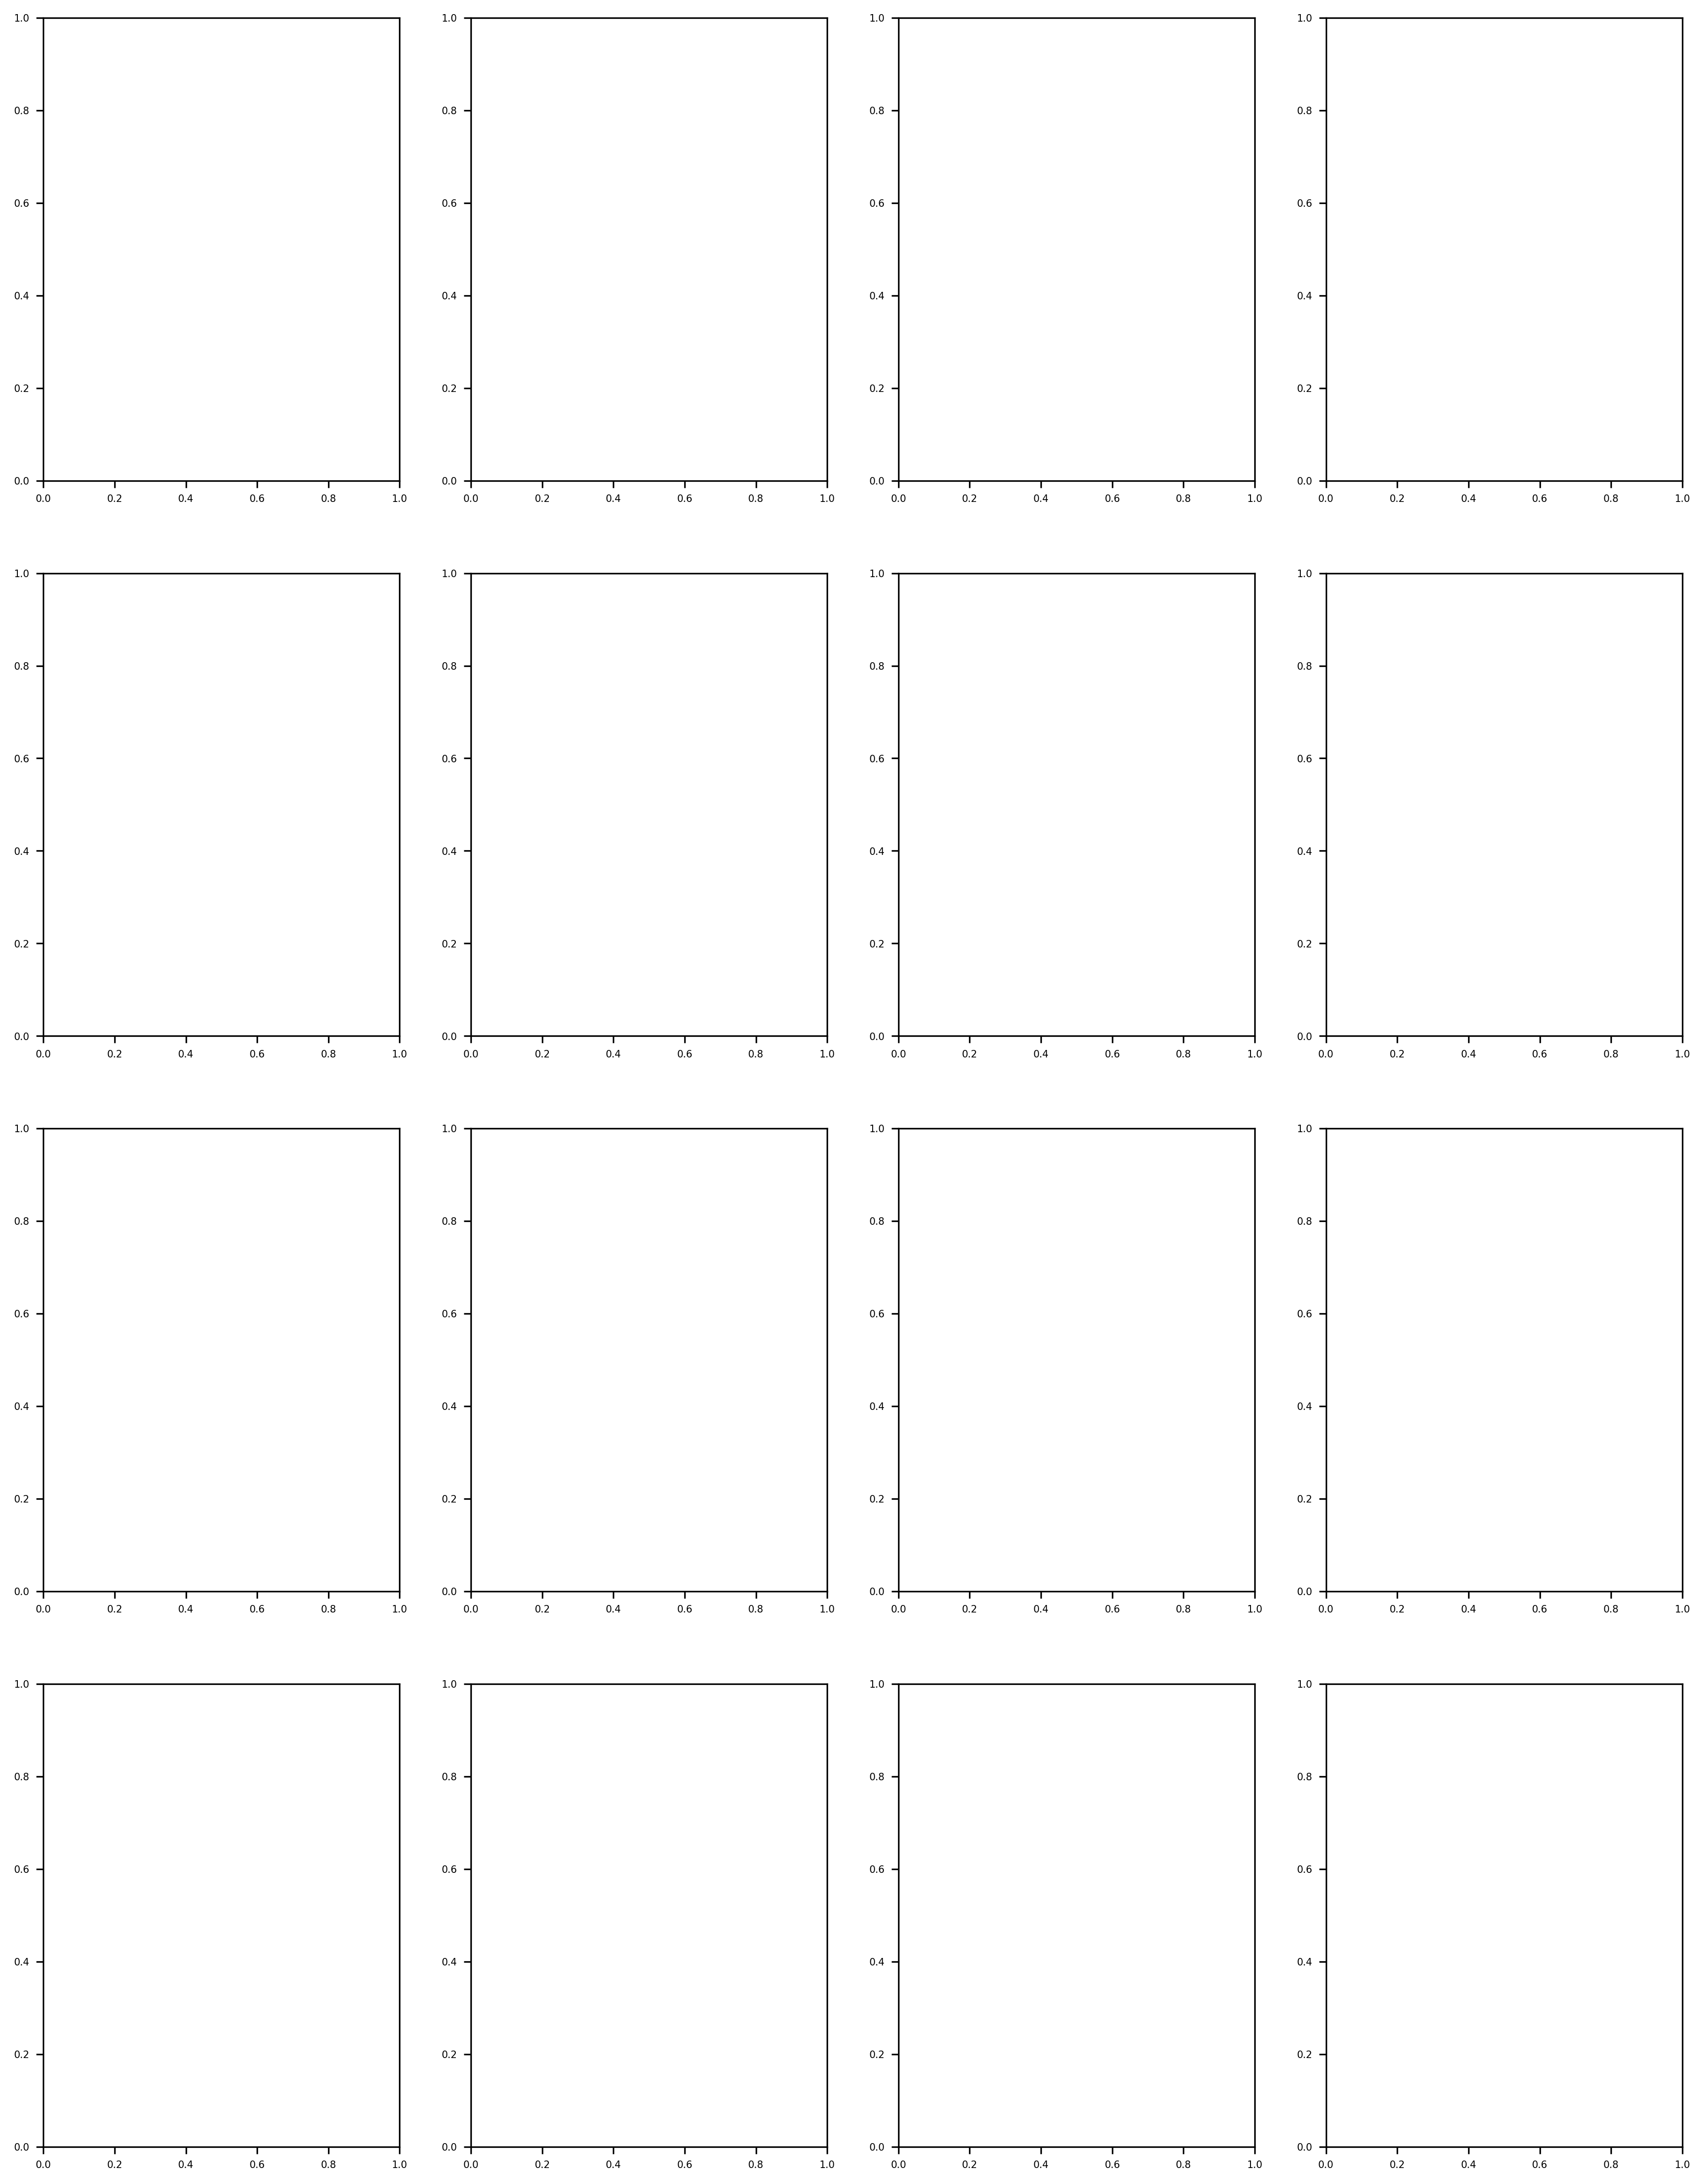

In [50]:
# --- VIZ CORE CLOCK GENES OVER CELL TYPES ---



clock_genes = ['Arntl', 'Nfil3', 'Dbp', 'Nr1d2']
condition = 'male aligned bmal1-control'


# ** init fig **
fig, axs = plt.subplots(nrows=len(clusters),ncols=len(clock_genes),figsize = (15,20),dpi=300)

# ** init min, max val lists for each gene **
gene_min_log10_vals, gene_max_log10_vals = np.ones((len(clock_genes))) * np.inf, np.ones((len(clock_genes))) * -1 * np.inf

# ** make the violins
for z,cluster in enumerate(clusters):
    
    # get the clock sampled log prop for the cluster
    clock_sampled_log_prop, male_fft_res,clock_genes_with_params = get_log_prop_samples_and_fft(cluster,condition,num_grid_points,num_waveform_samples,gene_list=clock_genes)
    # get_log_prop_samples(cluster,description,num_samples,cluster_description_folder_out_dict,gene_list=None)
    
    
    for y,gene in enumerate(clock_genes):
    
        
        try:
    
            # get gene index in sampled_log_prop
            # gene_index = np.where(np.array(genes_with_params) == gene)[0].item()
            gene_index = np.where(np.array(clock_genes_with_params) == gene)[0].item()


            # update the LOG10 min and max values for the gene
            min_val = torch.min(clock_sampled_log_prop[:,:,gene_index].flatten()).item() / np.log(10)
            max_val = torch.max(clock_sampled_log_prop[:,:,gene_index].flatten()).item() / np.log(10)
            if min_val < gene_min_log10_vals[y]:
                gene_min_log10_vals[y] = min_val
            if max_val > gene_max_log10_vals[y]:
                gene_max_log10_vals[y] = max_val



            # make gene df
            # val_mat = sampled_log_prop[:,:,gene_index]
            val_mat = clock_sampled_log_prop[:,:,gene_index]
            time_mat = np.zeros((num_waveform_samples, 4))
            time_mat[:,0] = 0
            time_mat[:,1] = 6
            time_mat[:,2] = 12
            time_mat[:,3] = 18
            gene_df = pd.DataFrame()
            gene_df['ZT'] = time_mat.flatten().astype(int)
            gene_df['Log10 prop'] = val_mat.flatten().numpy() / np.log(10)


            # viz
            sns.despine()
            axs[z,y] = sns.violinplot(x="ZT", y="Log10 prop", data=gene_df,ax=axs[z,y],color='0.5')
        except:
            pass

        

# ** for each gene, update the y-axis min and max to be the same for all clusters **

# give ourselves some more wiggle room
margin = 0.2
gene_max_log10_vals = gene_max_log10_vals + margin
gene_min_log10_vals = gene_min_log10_vals - margin
for z,cluster in enumerate(clusters):    
    for y,gene in enumerate(clock_genes):
        axs[z,y].set_ylim((gene_min_log10_vals[y],gene_max_log10_vals[y]))
        
        
# ** add gene titles to columns **  
for y,gene in enumerate(clock_genes):
    axs[0,y].set_title(gene)
        
        
# ** savefig **
fileout = '%s/%s_cell_type_clock_gene_violins.pdf' % (folder_out, condition)
plt.savefig(fileout,bbox_inches='tight')


# ** show **
plt.show()














Dropping 0 keys


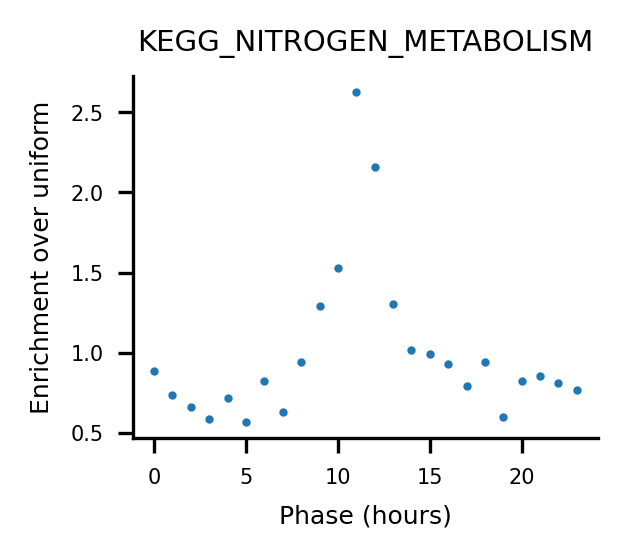

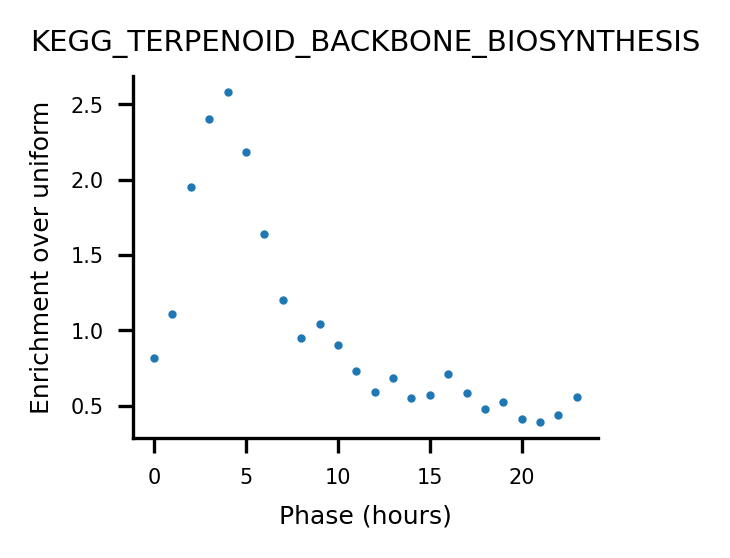

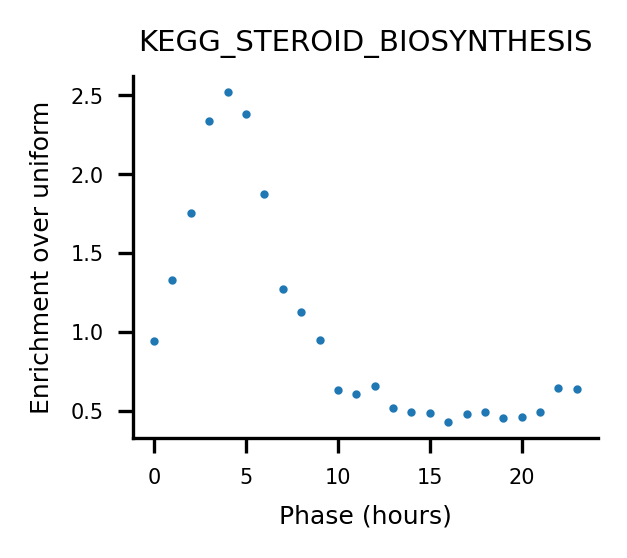

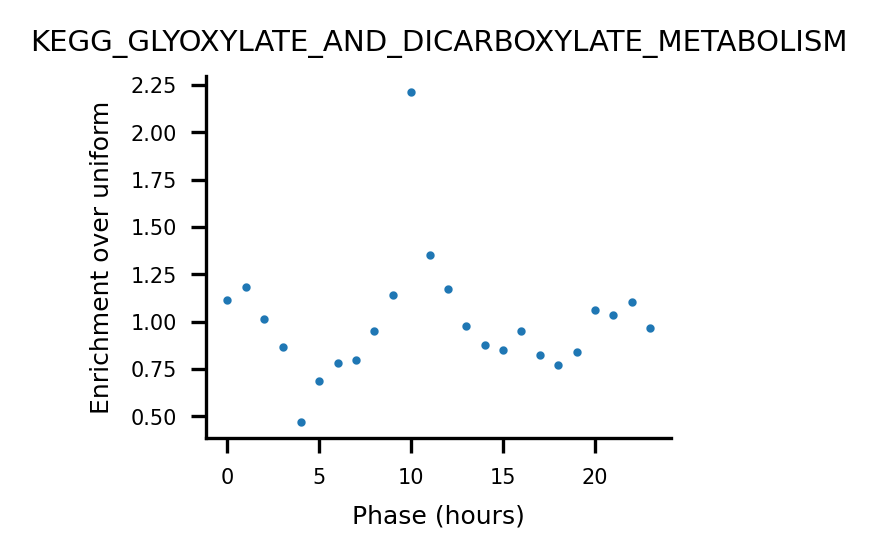

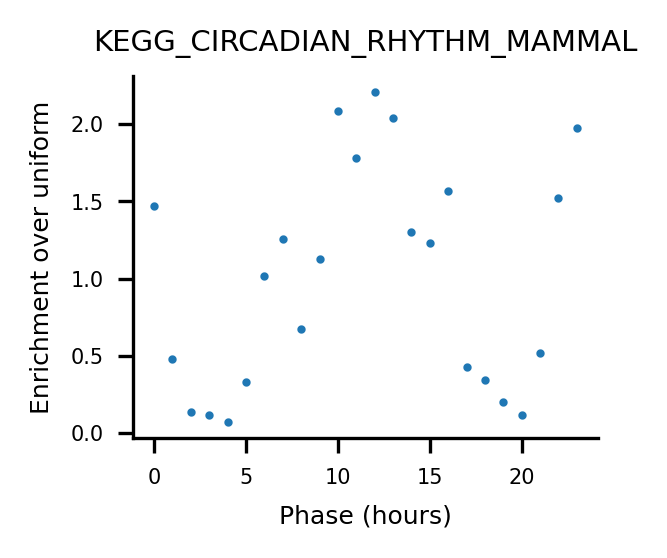

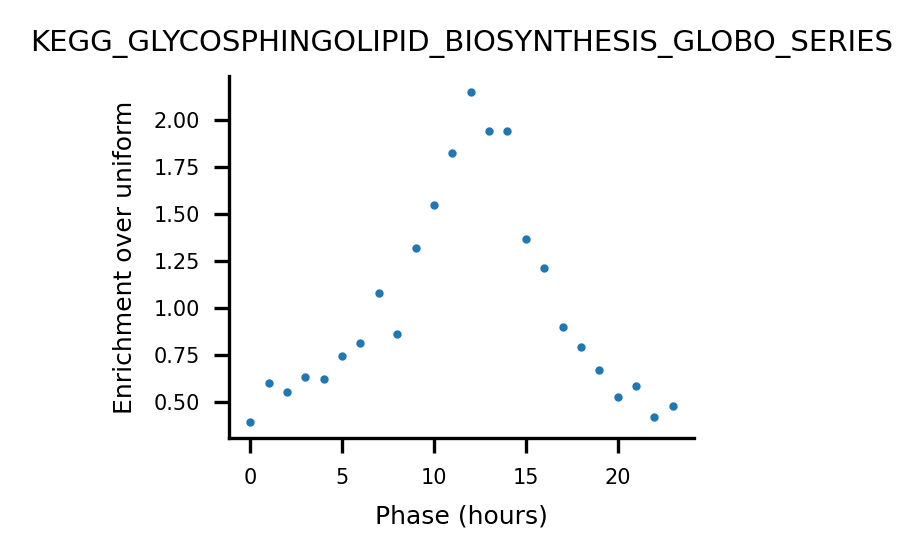

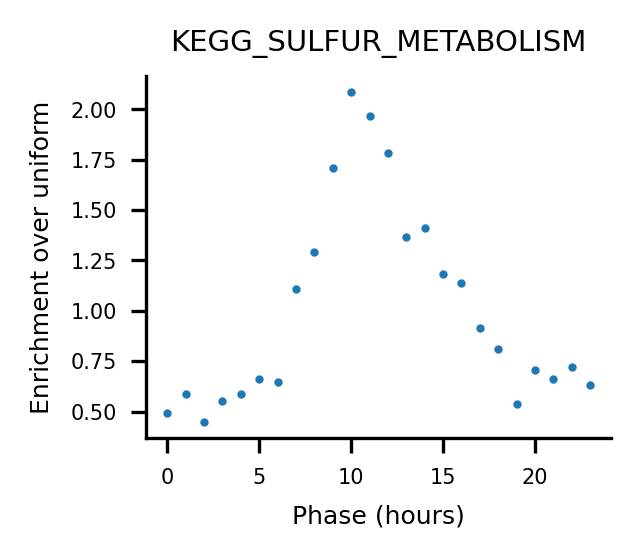

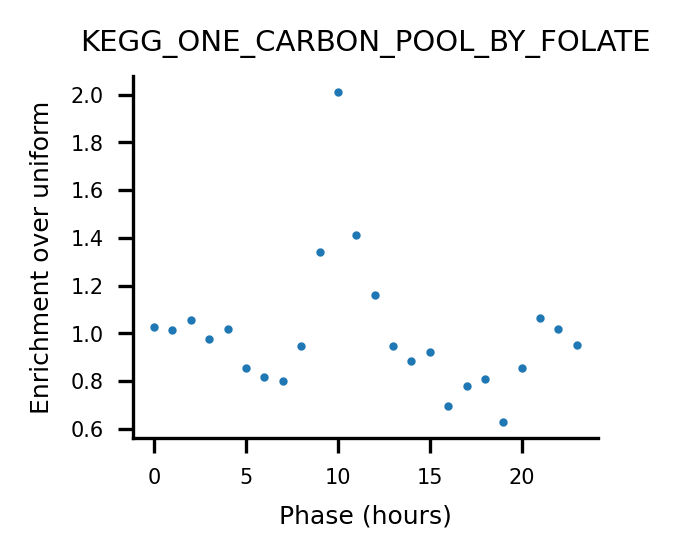

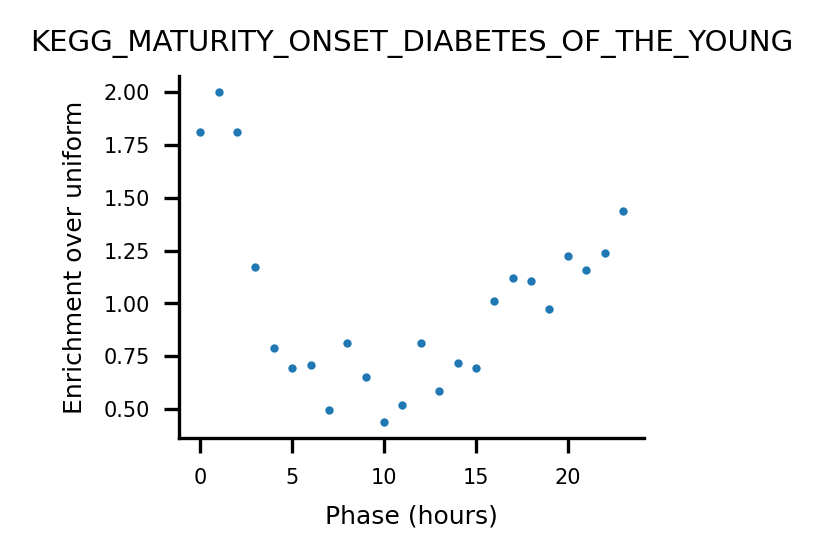

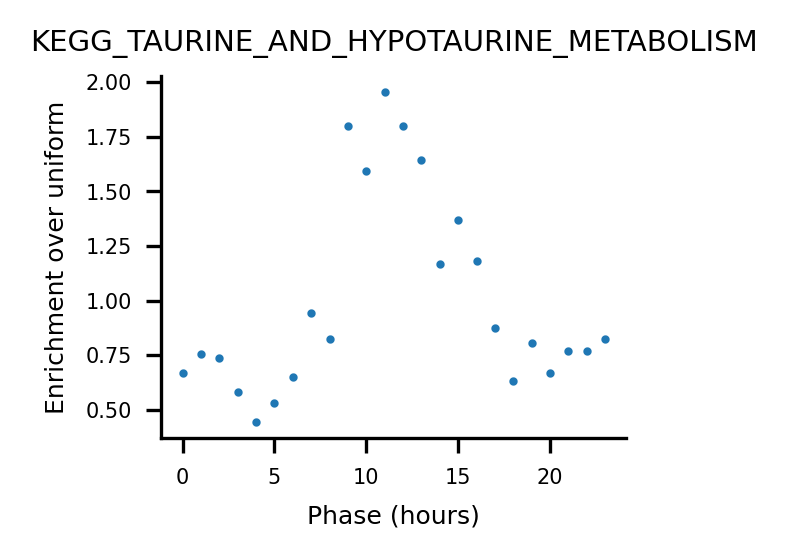

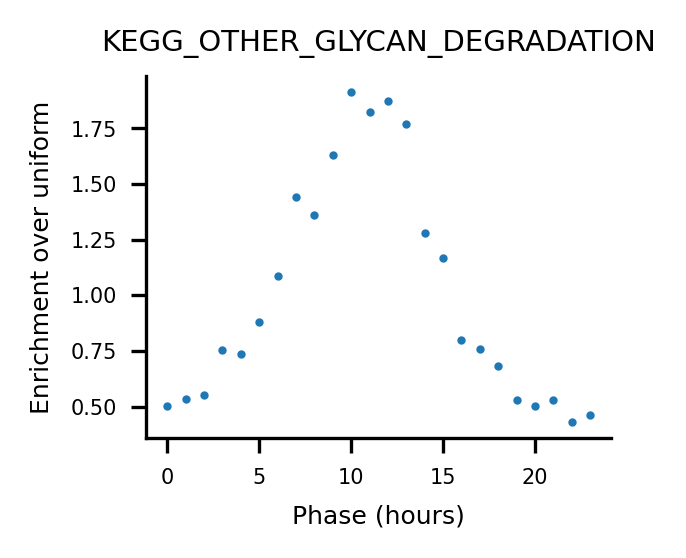

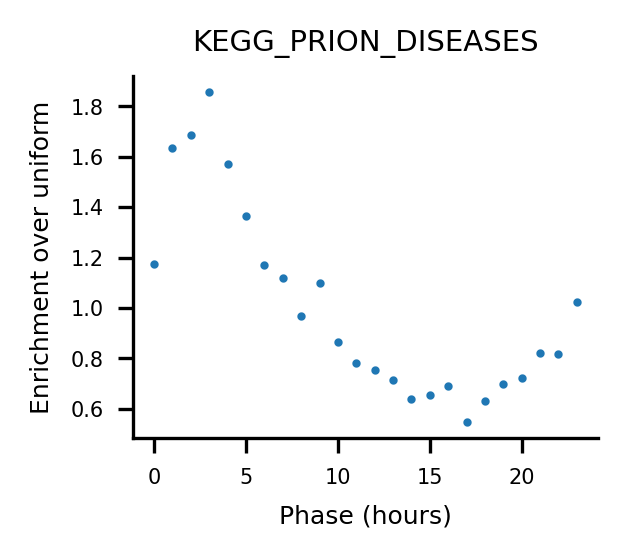

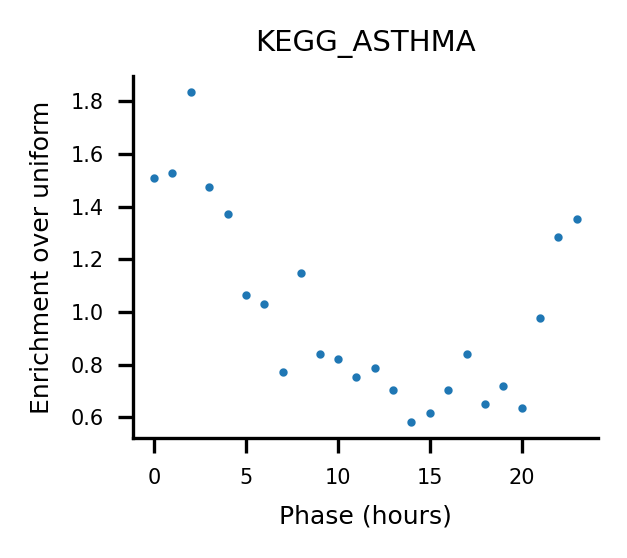

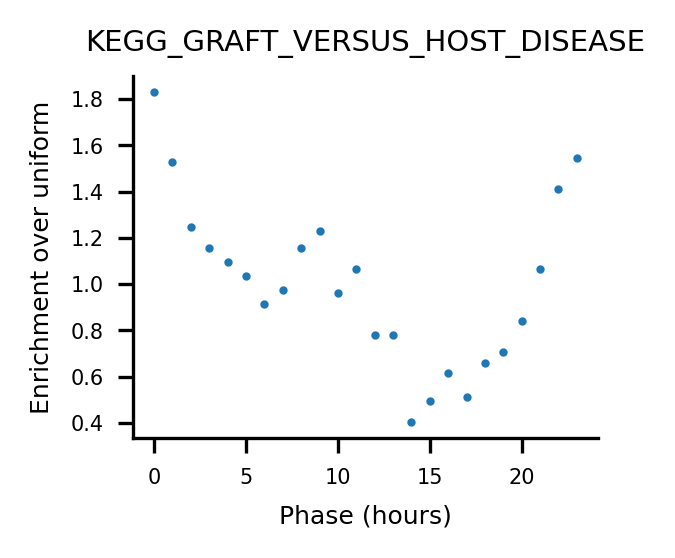

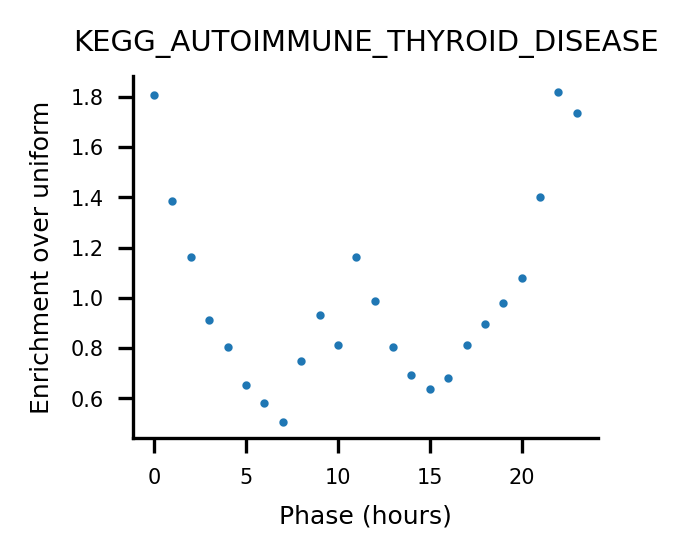

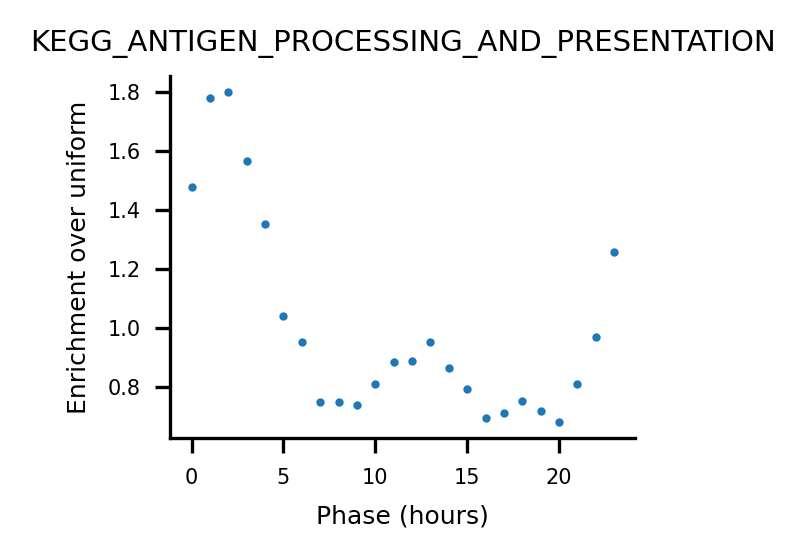

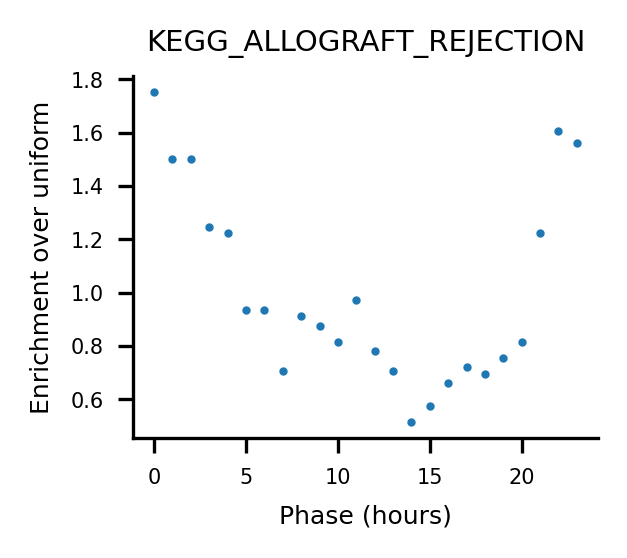

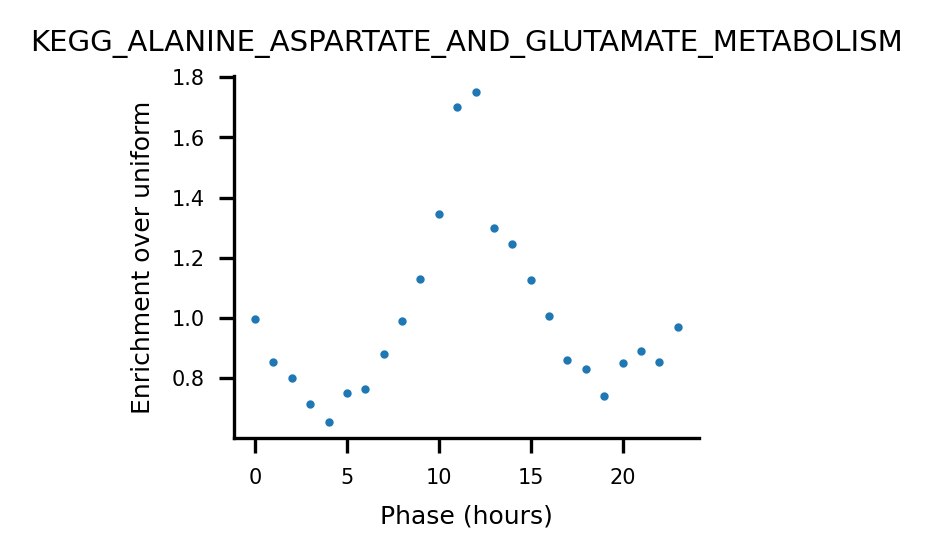

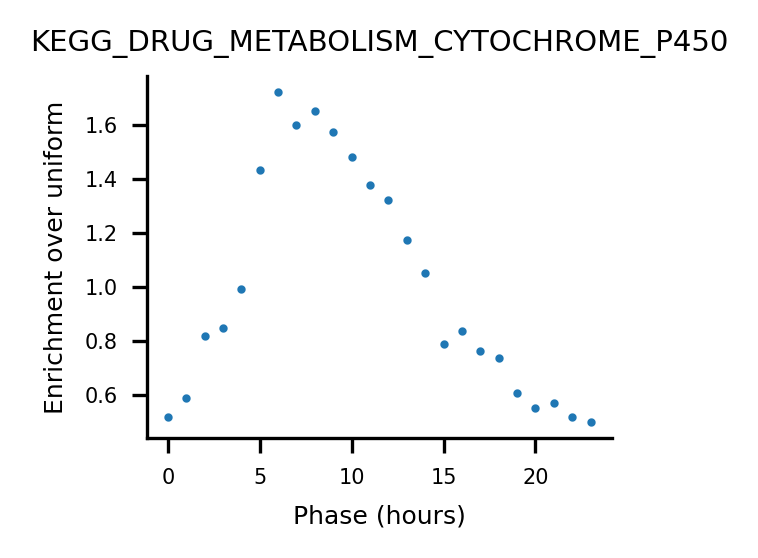

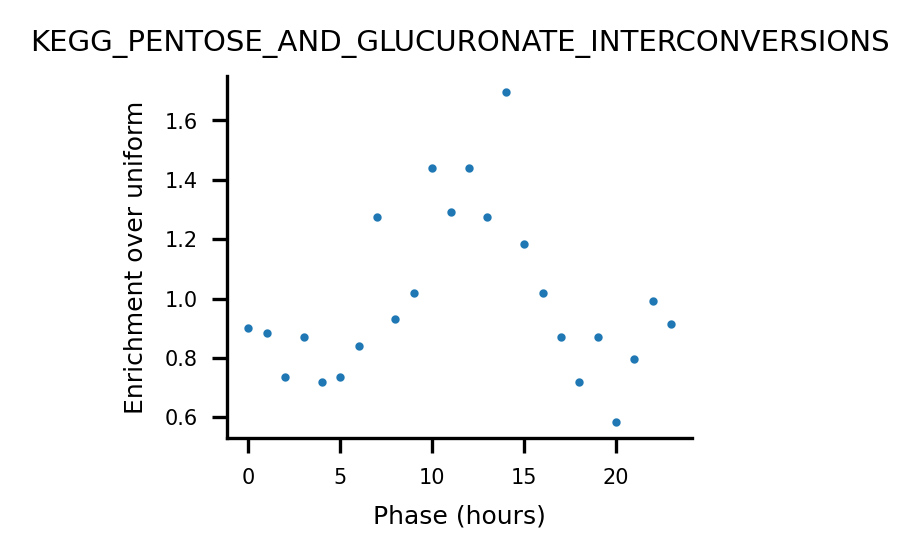

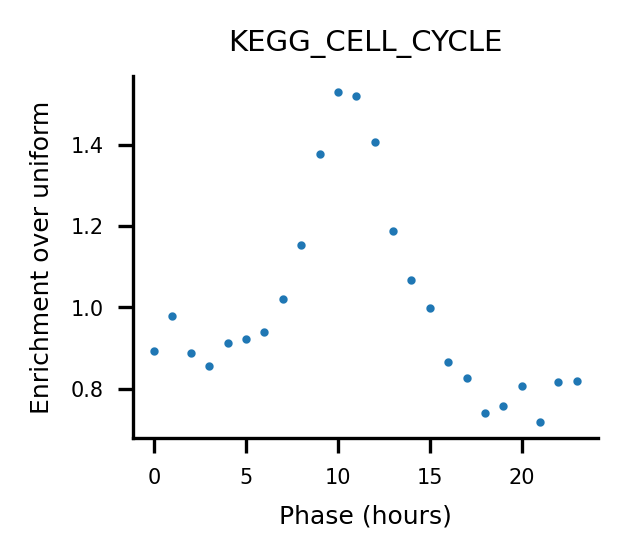

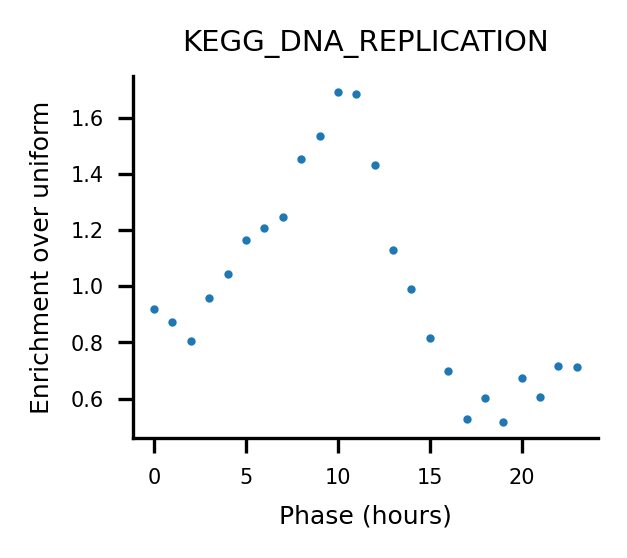

Dropping 0 keys


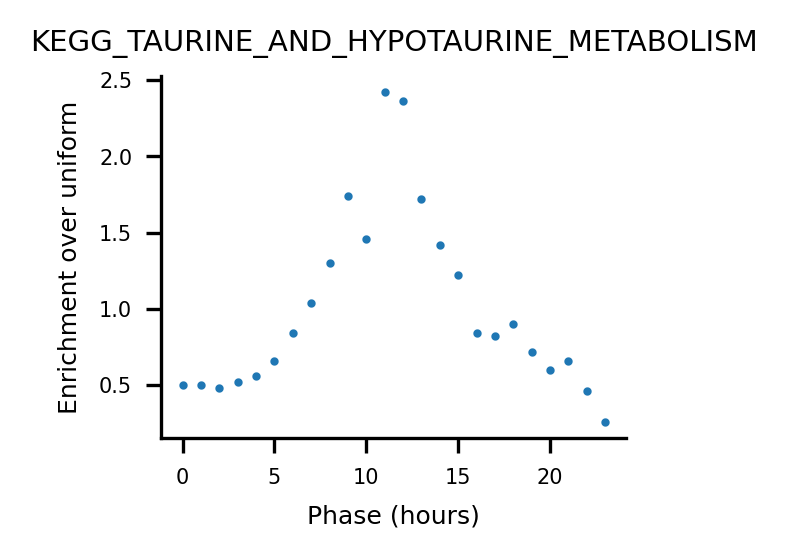

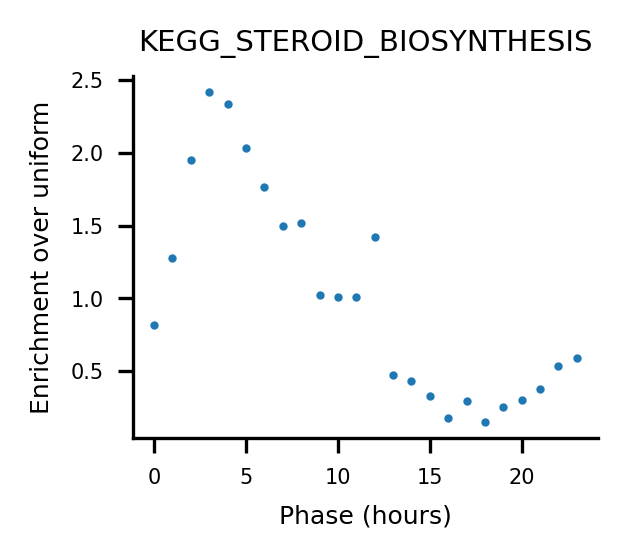

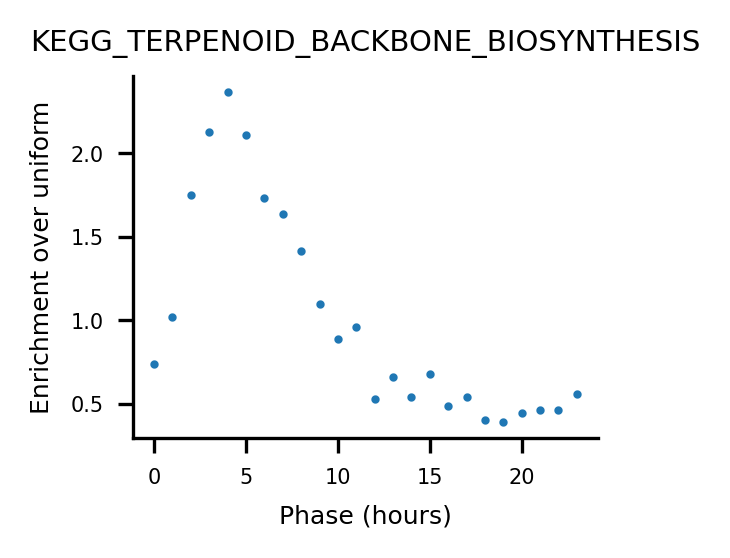

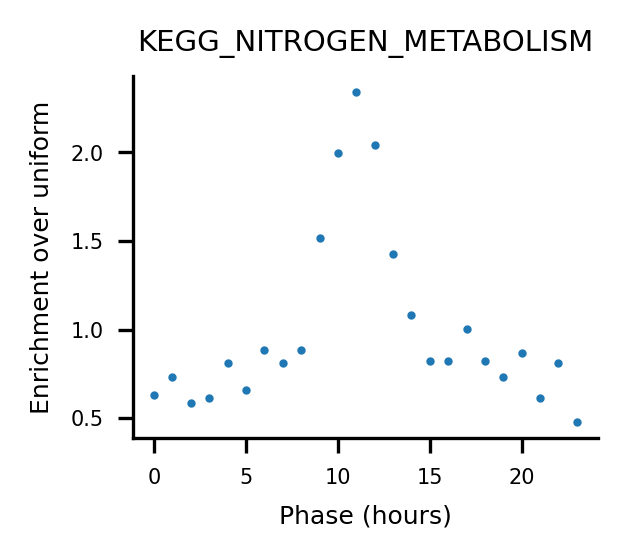

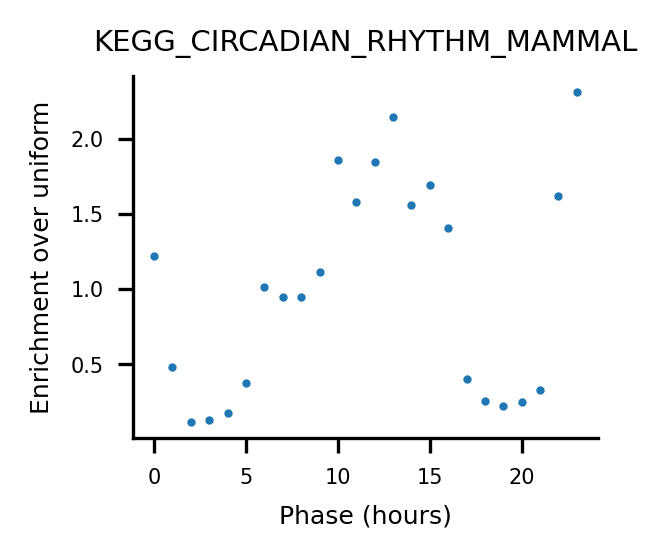

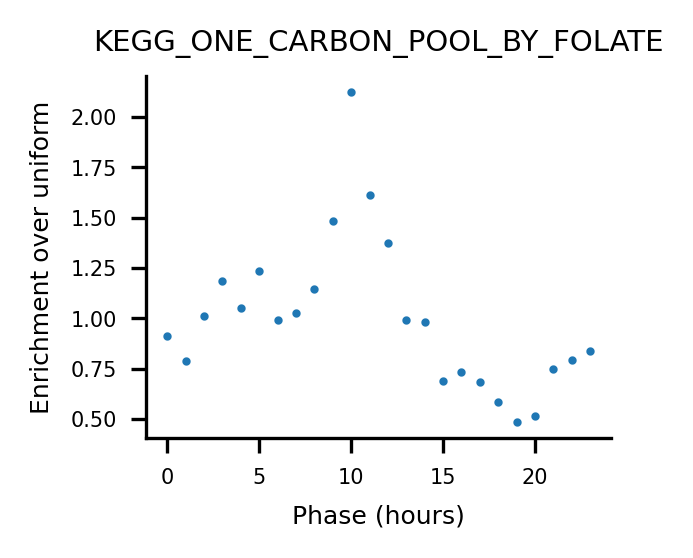

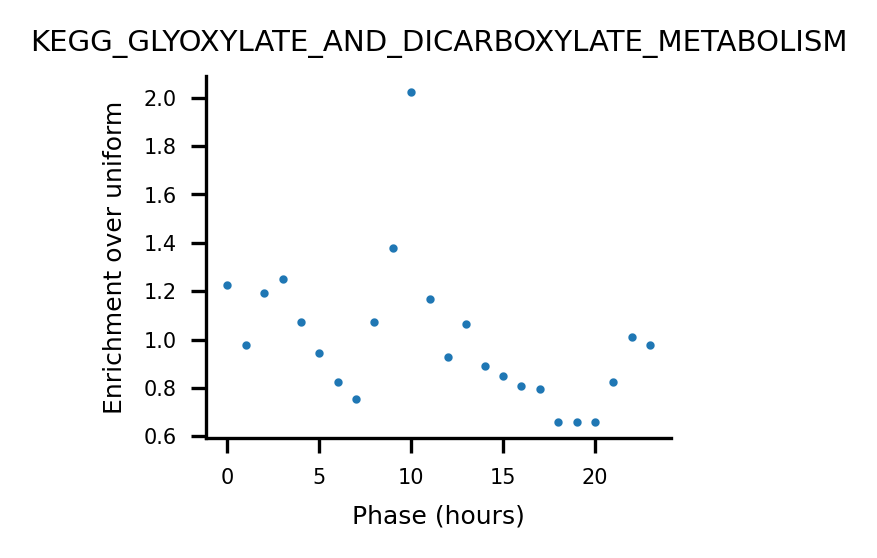

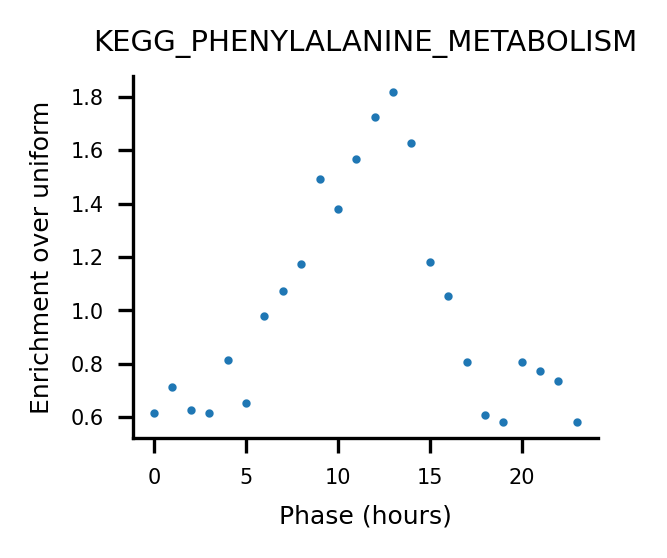

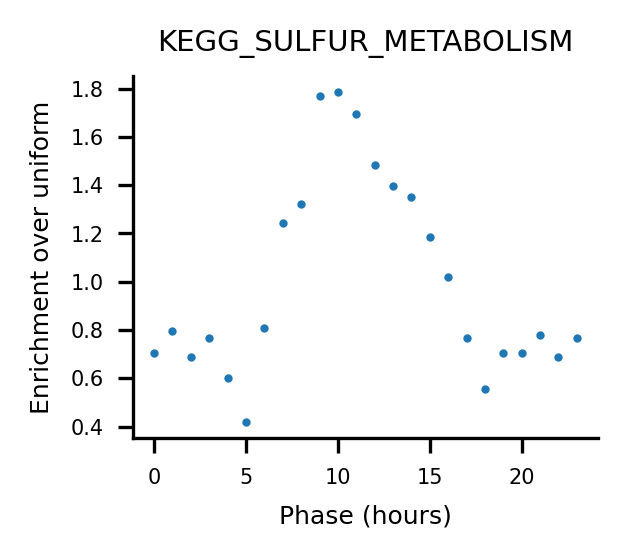

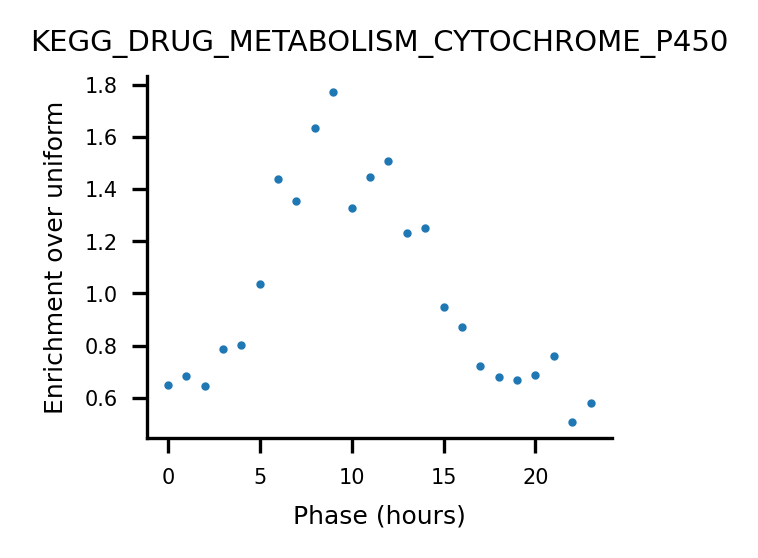

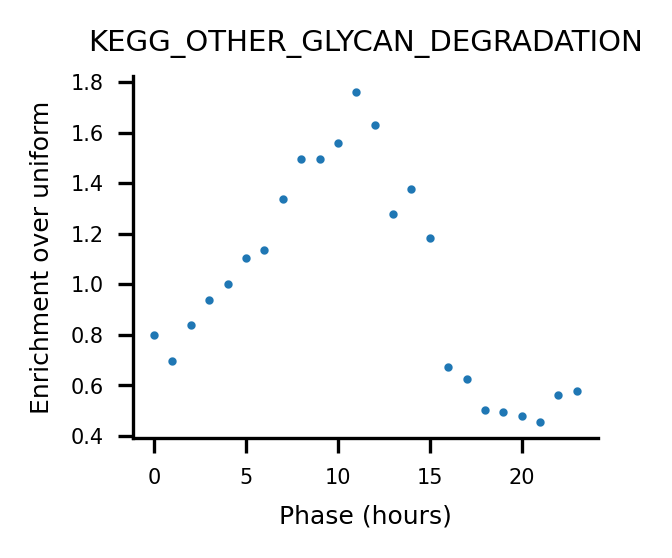

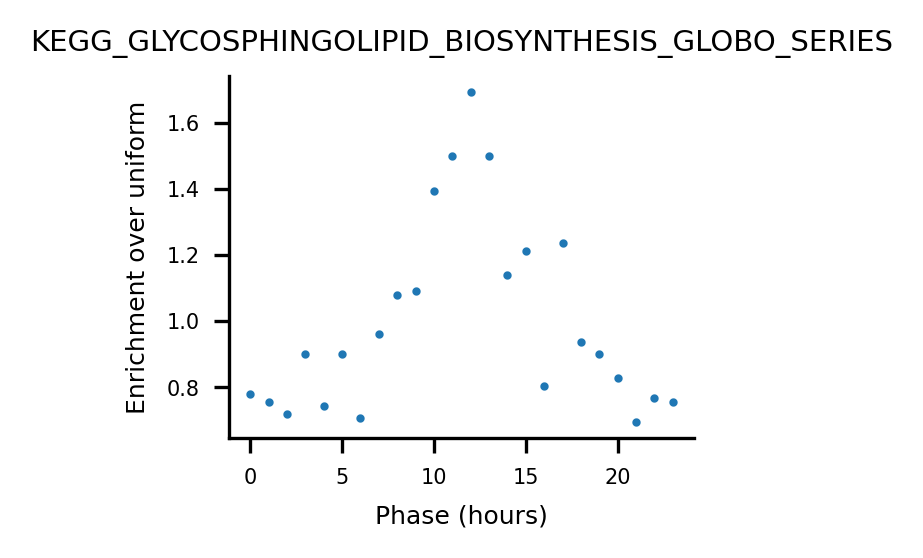

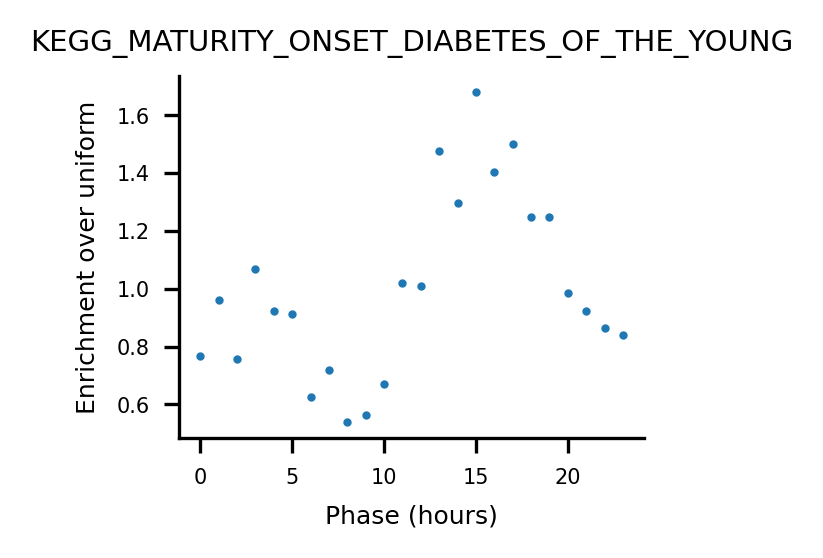

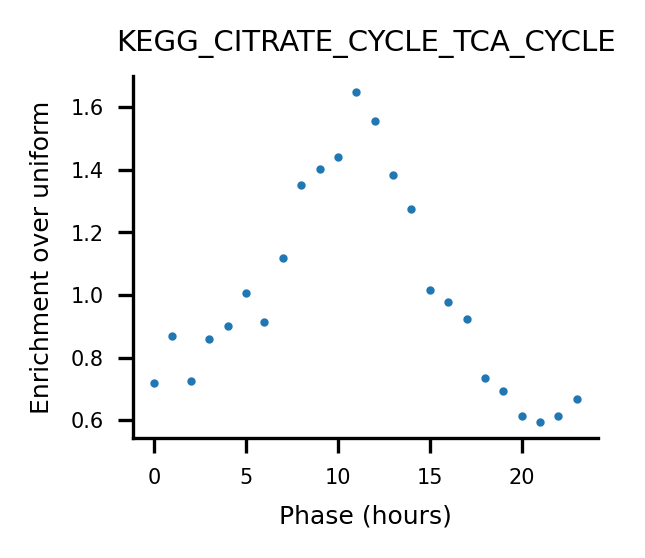

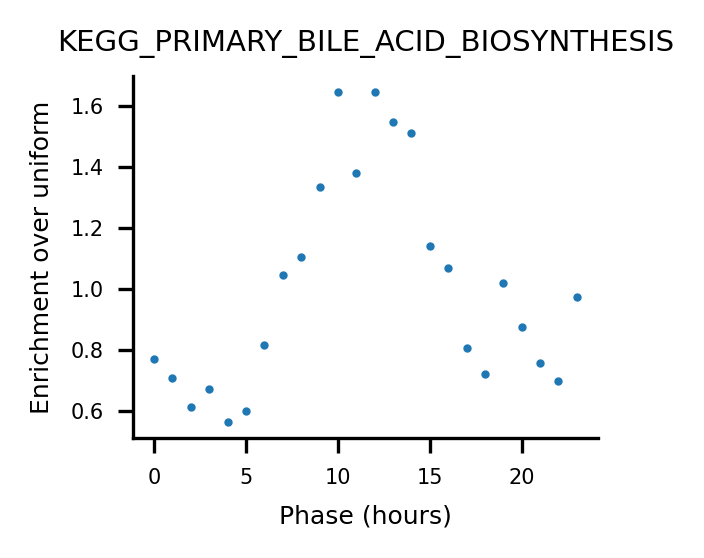

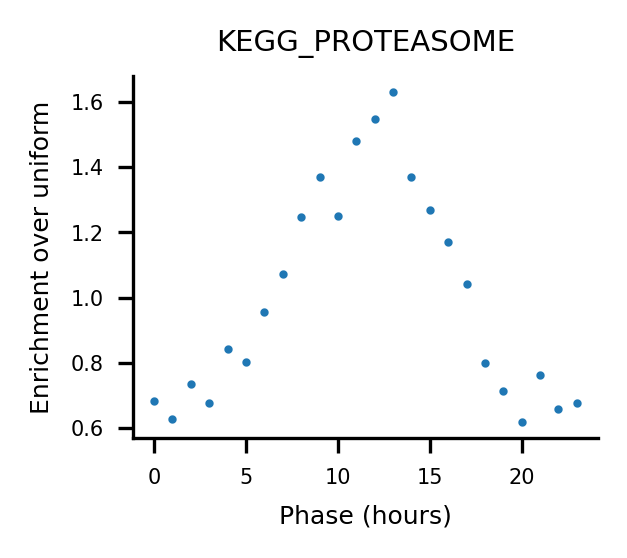

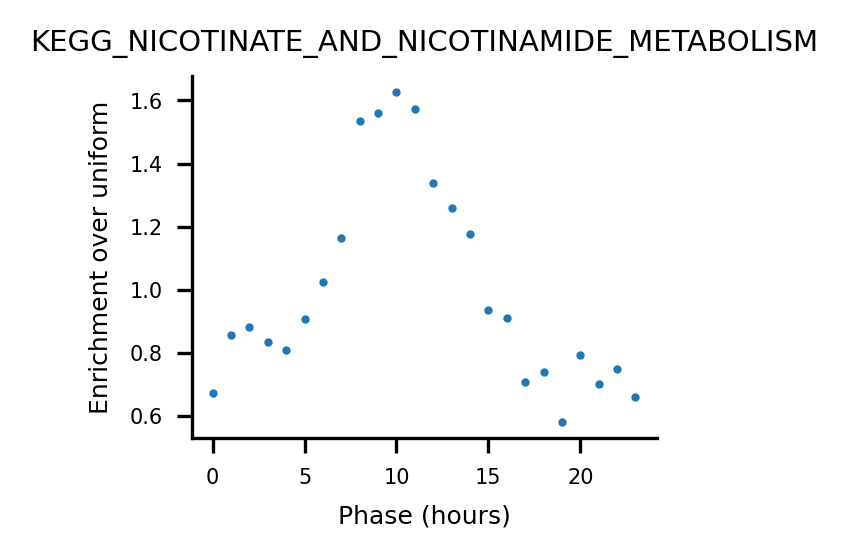

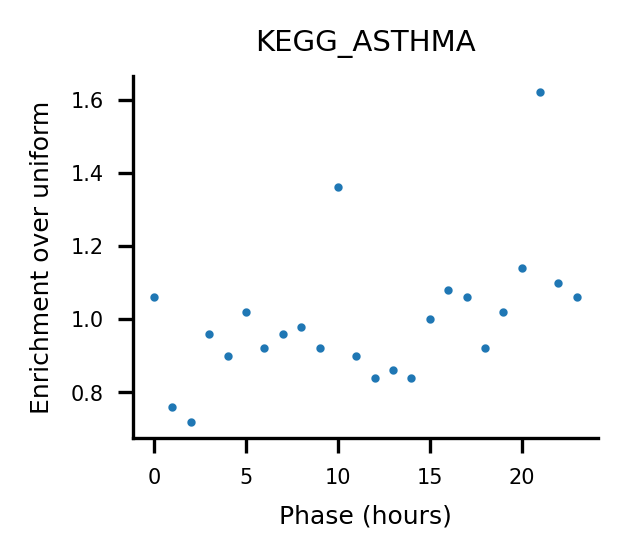

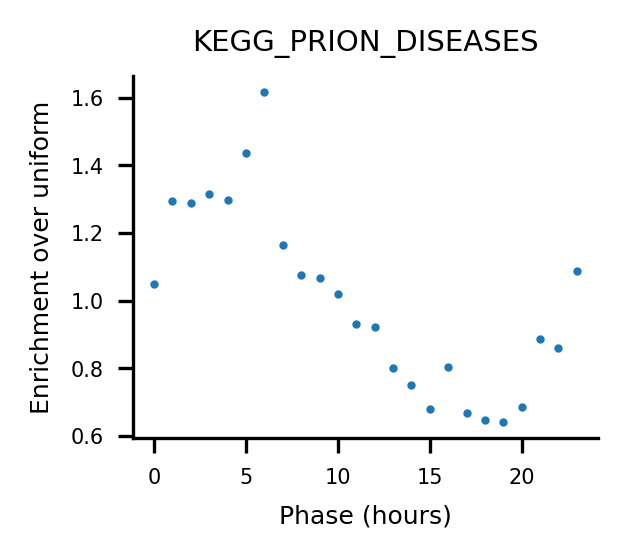

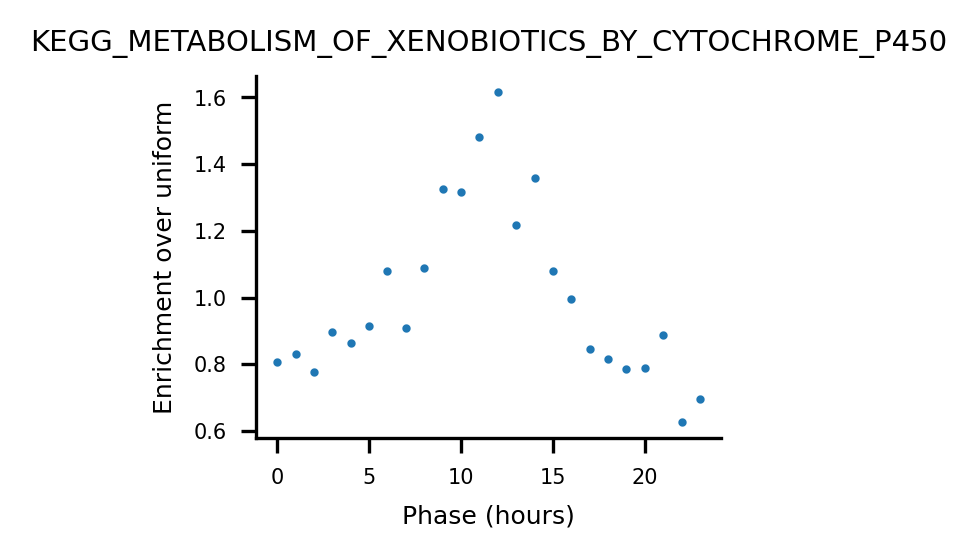

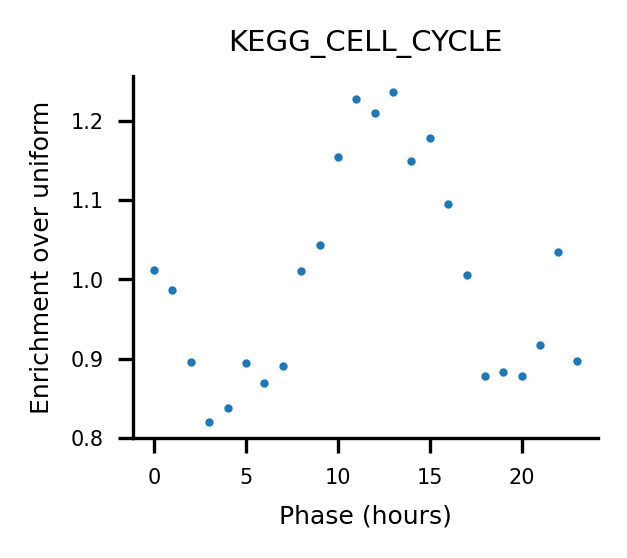

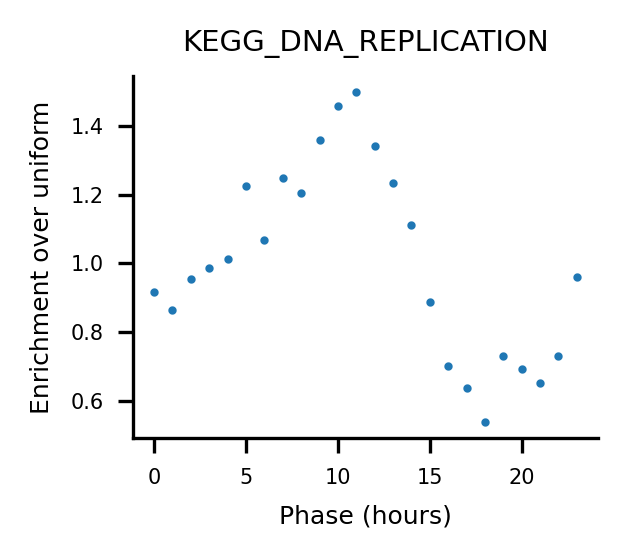

Dropping 0 keys


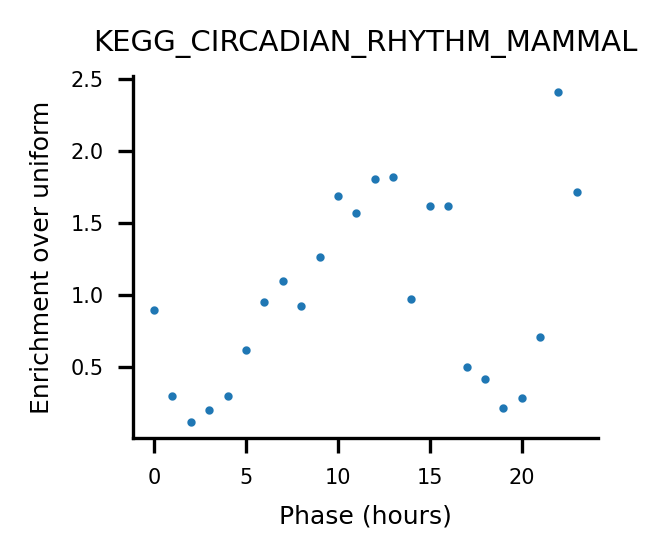

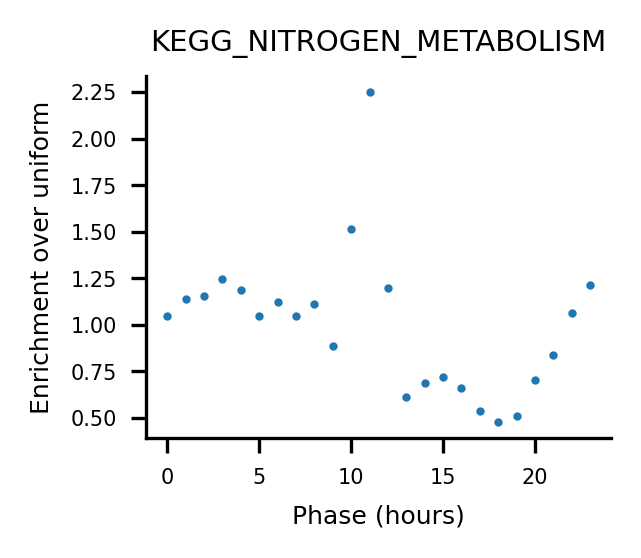

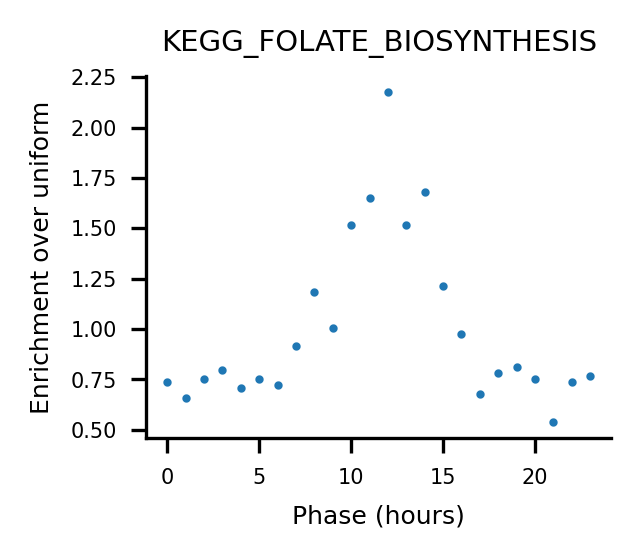

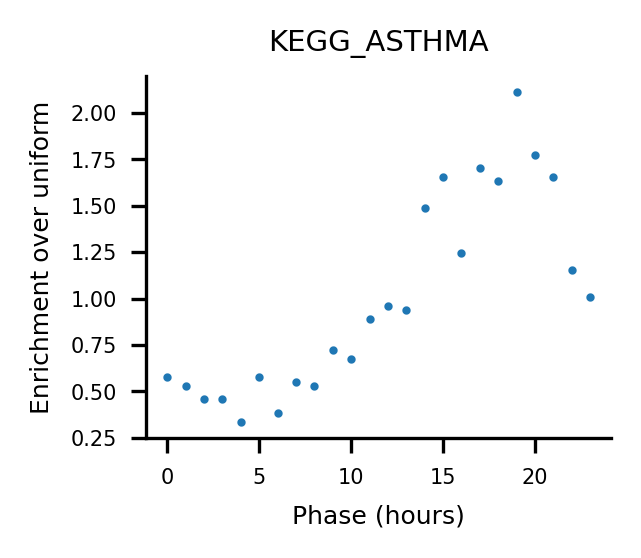

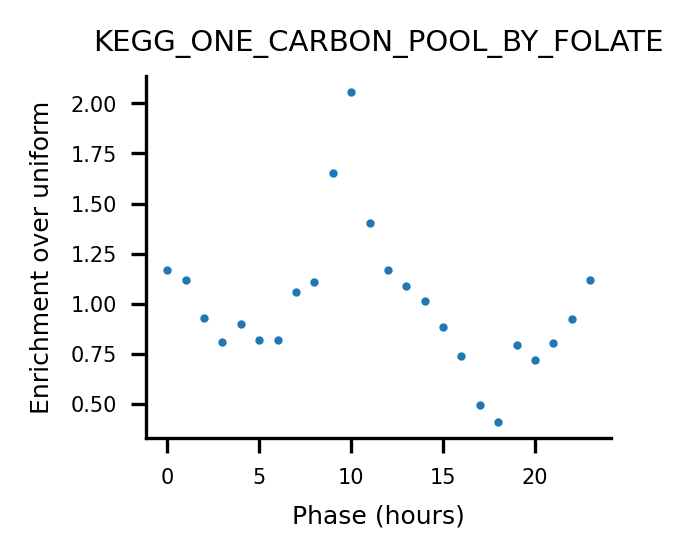

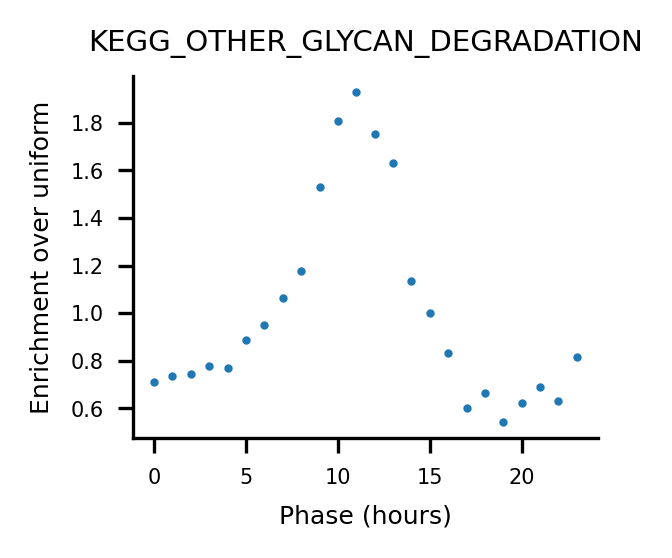

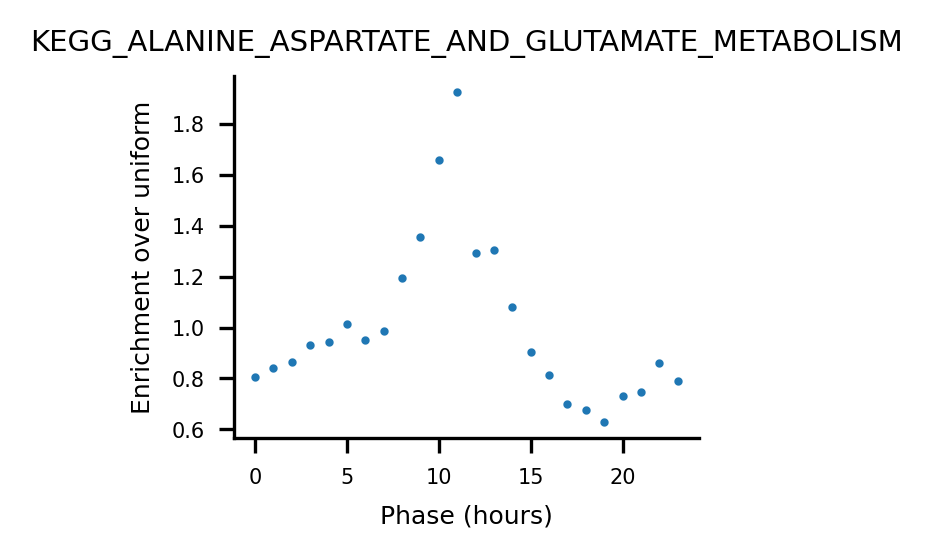

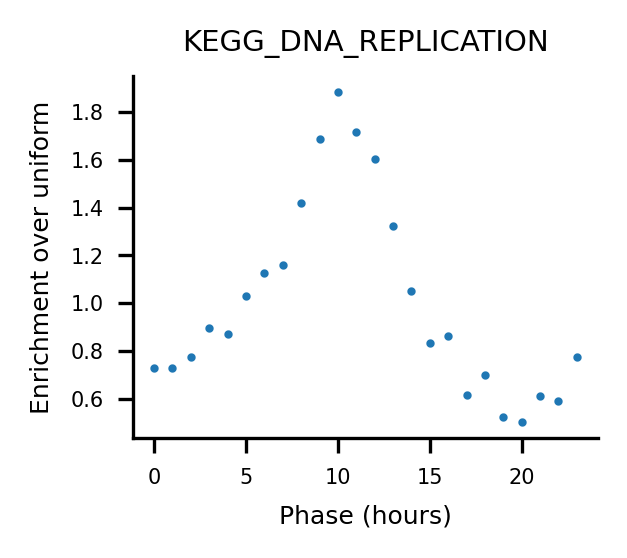

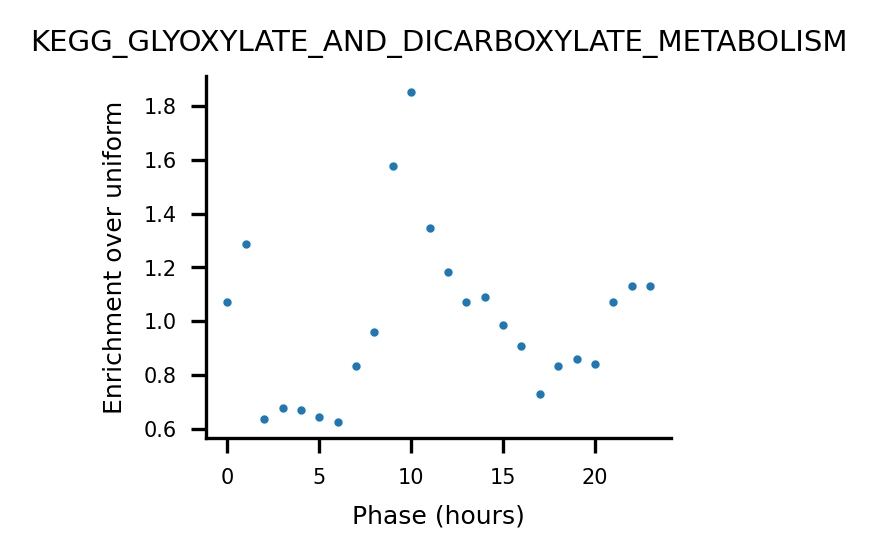

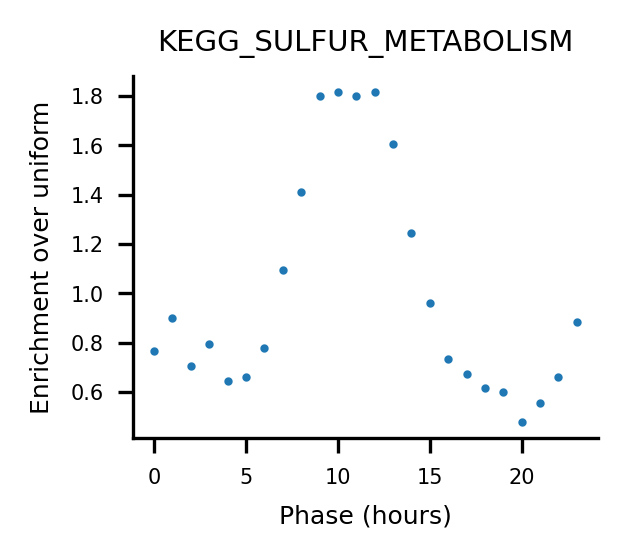

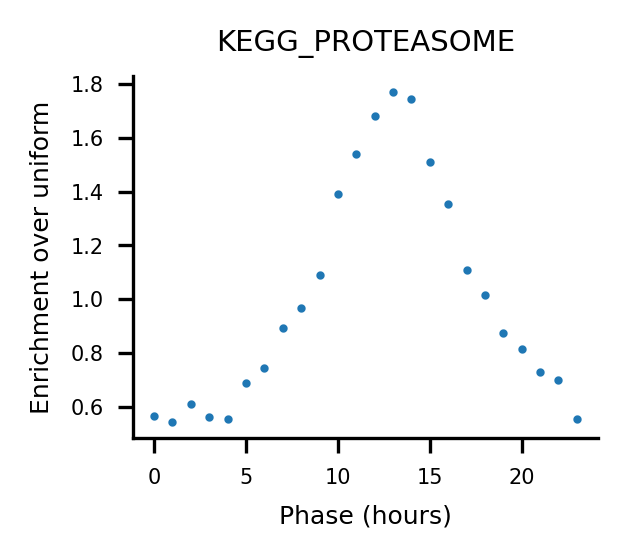

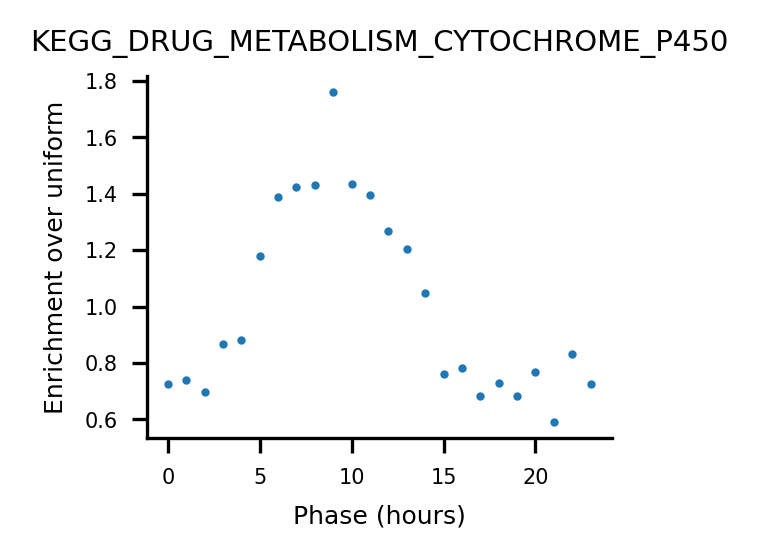

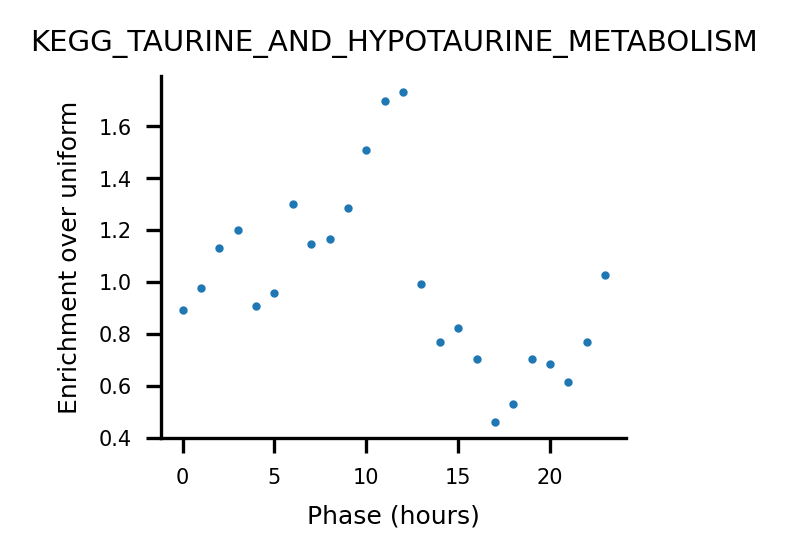

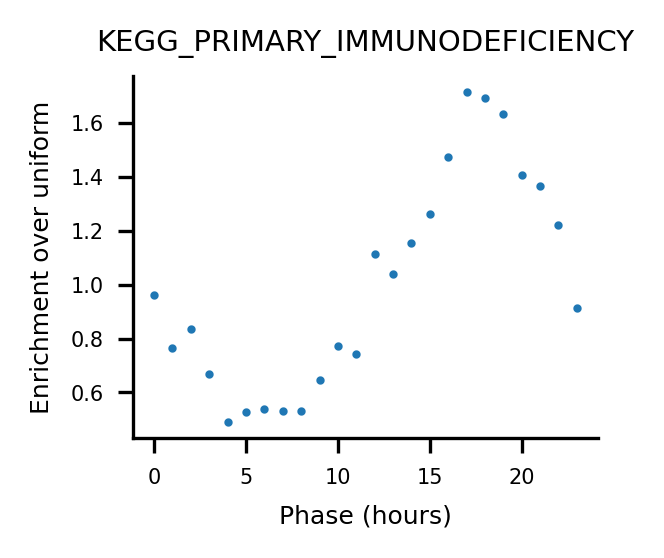

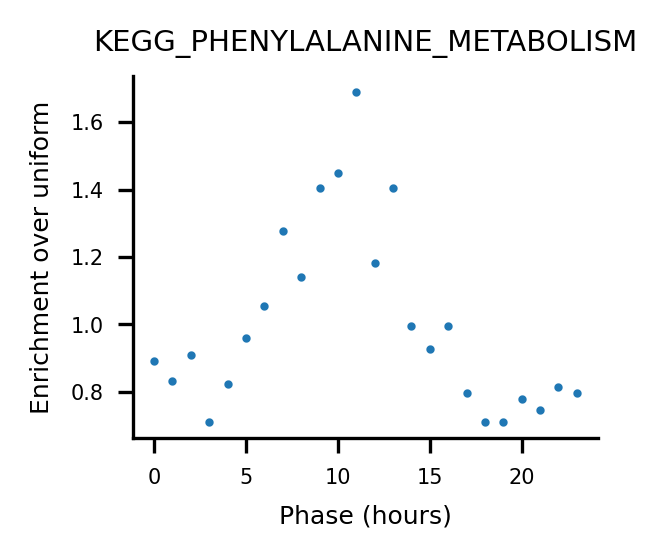

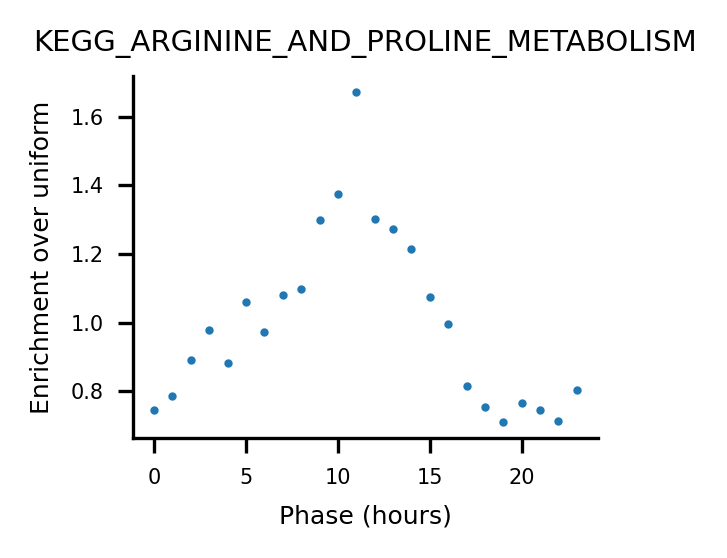

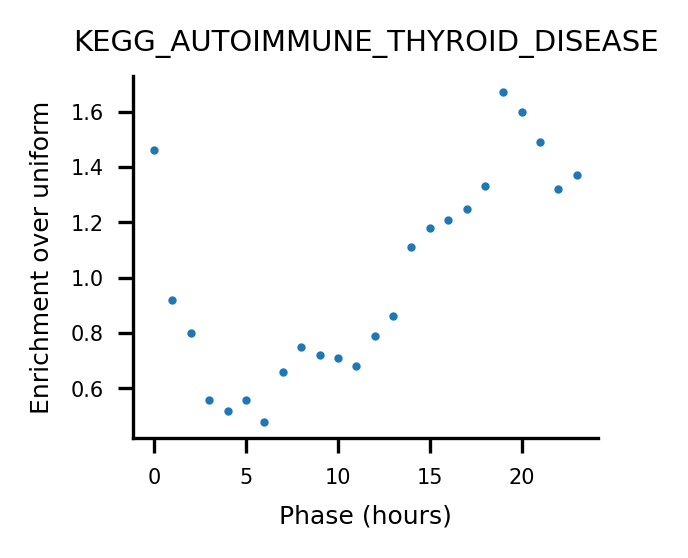

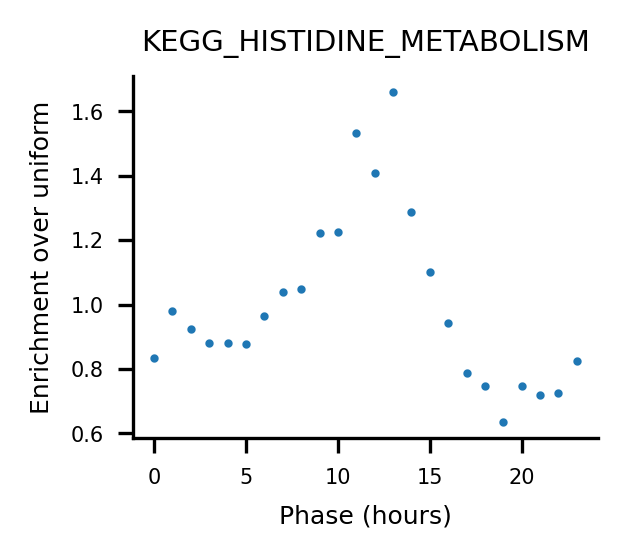

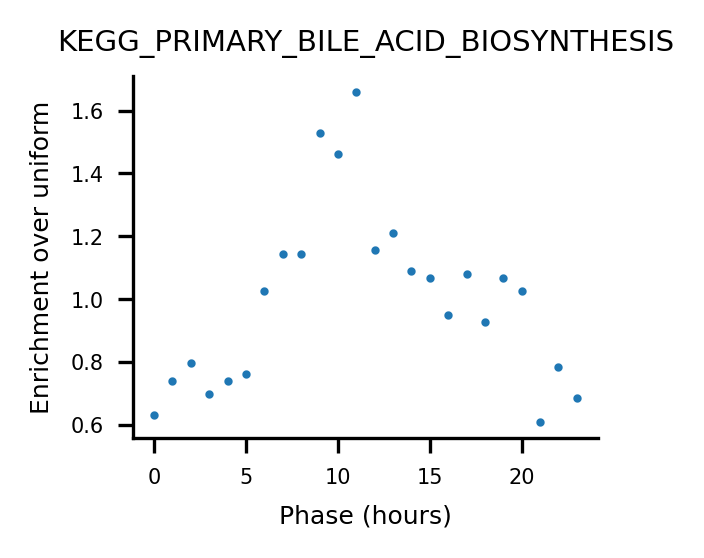

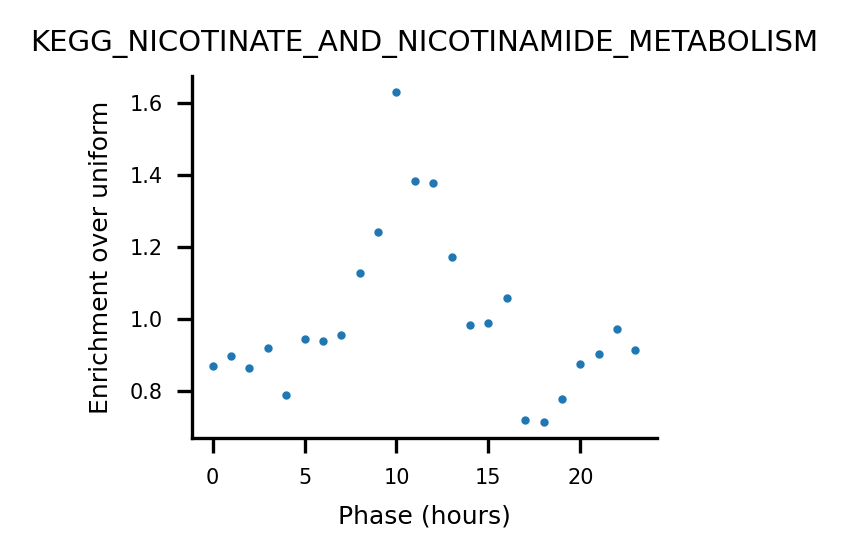

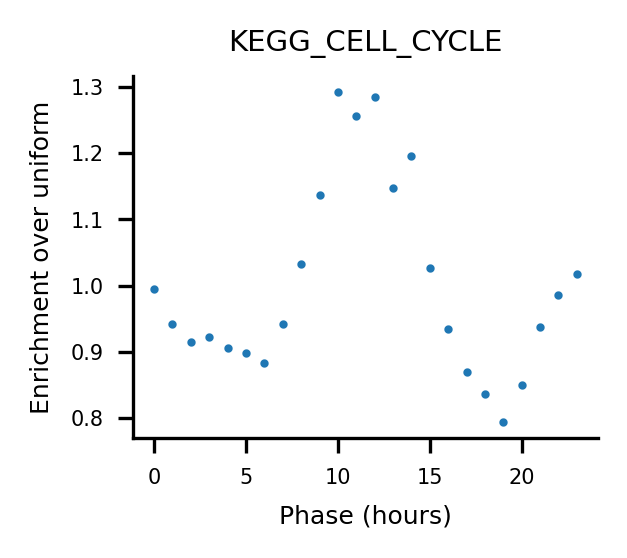

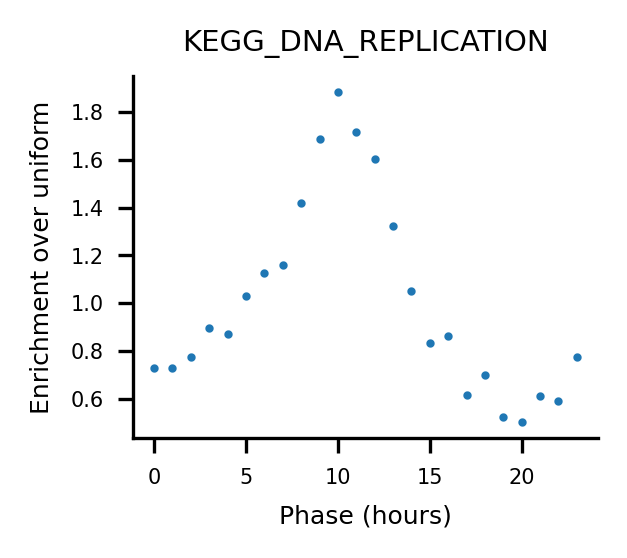

Dropping 0 keys


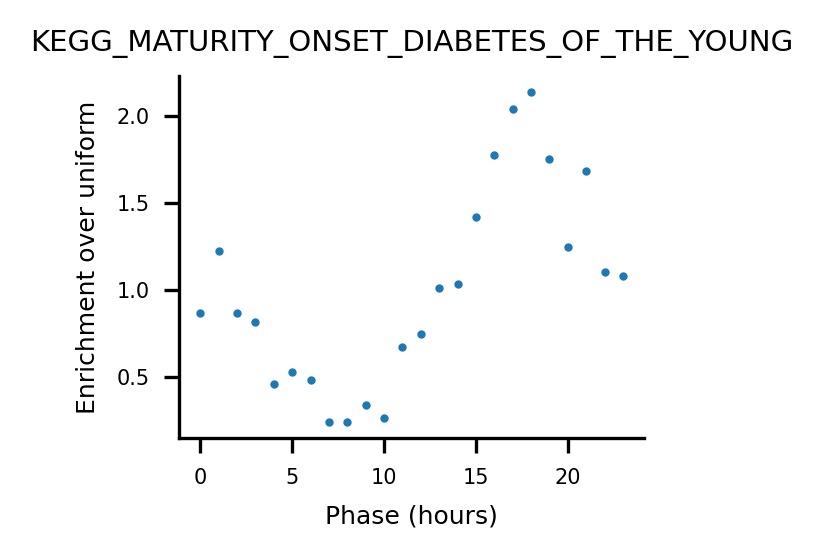

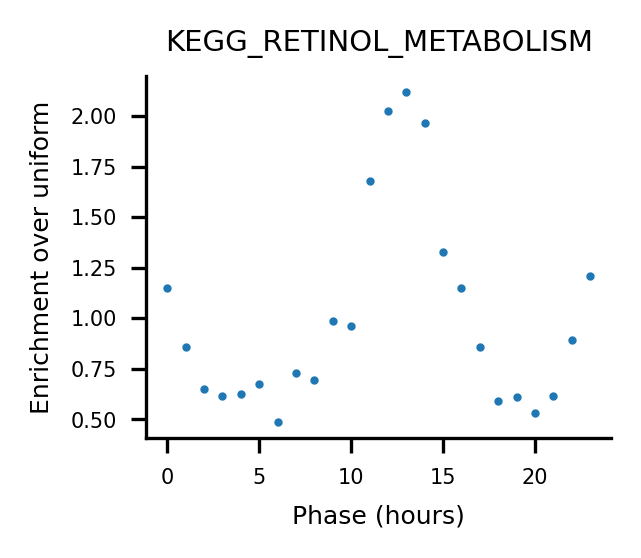

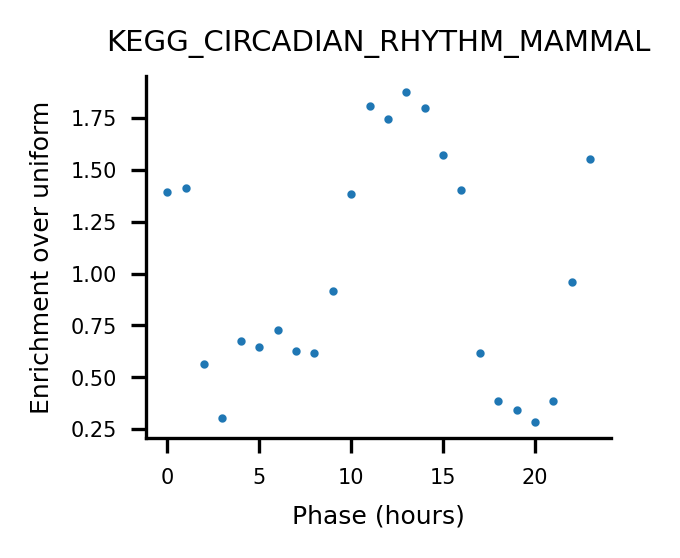

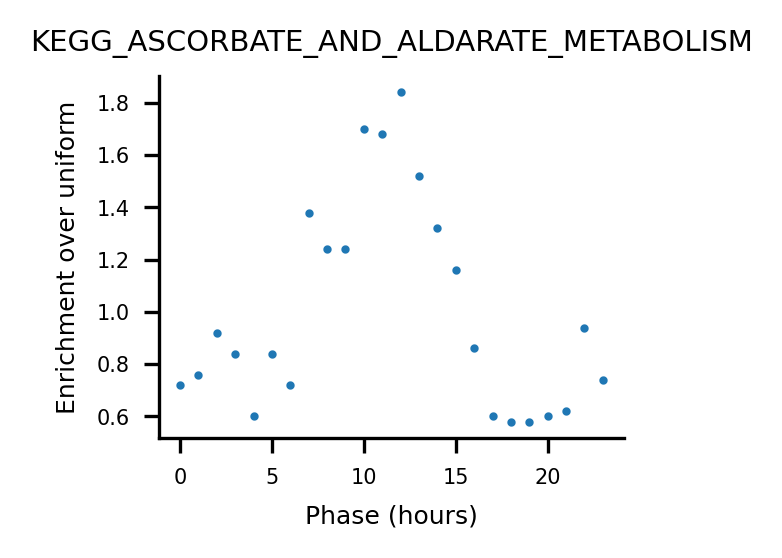

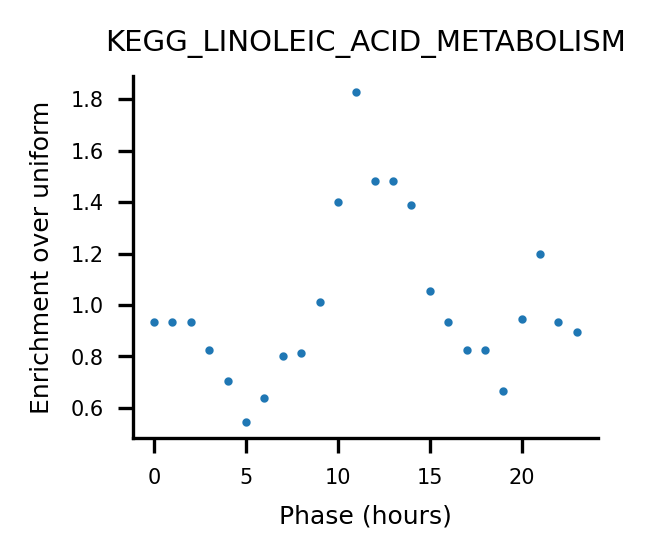

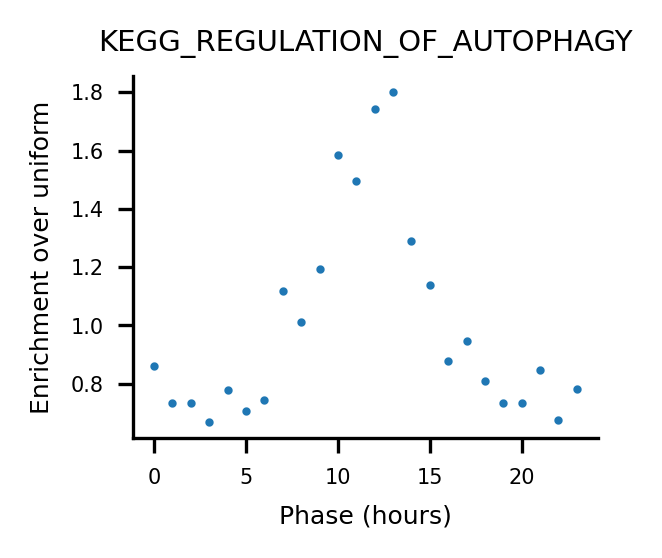

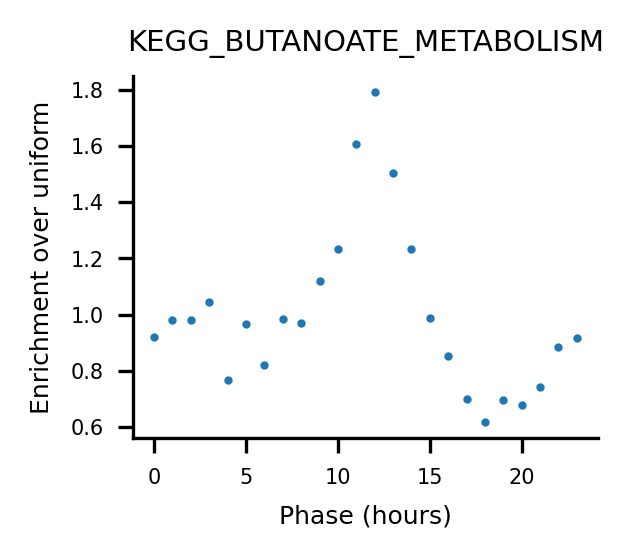

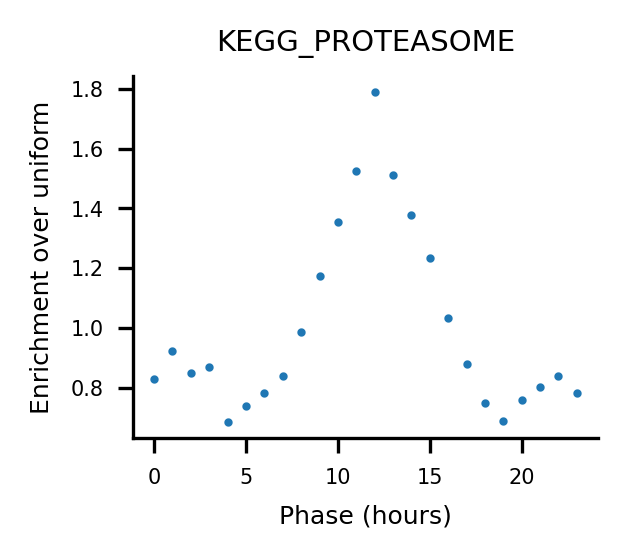

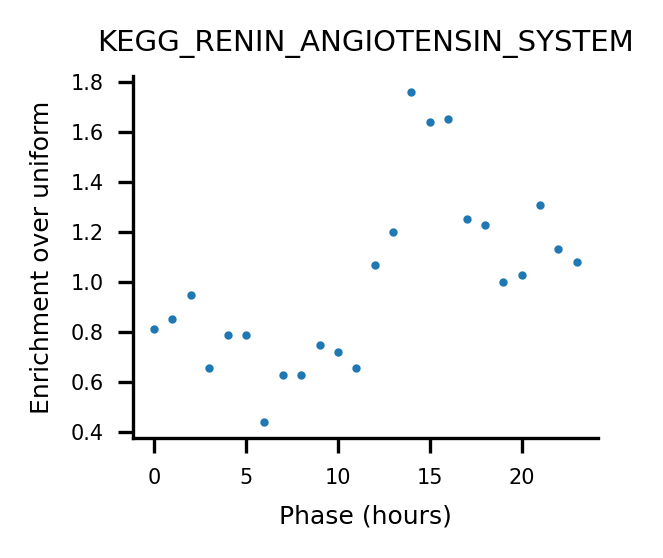

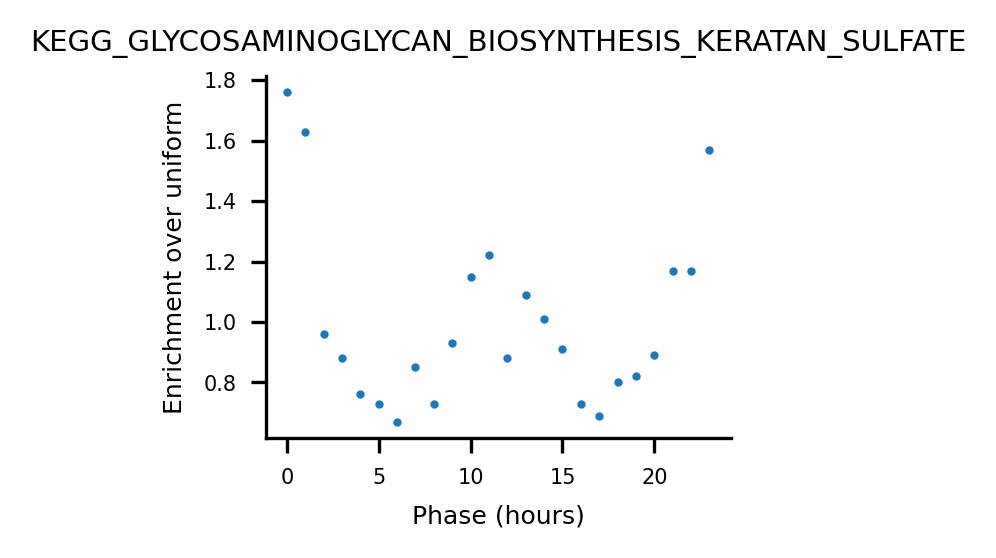

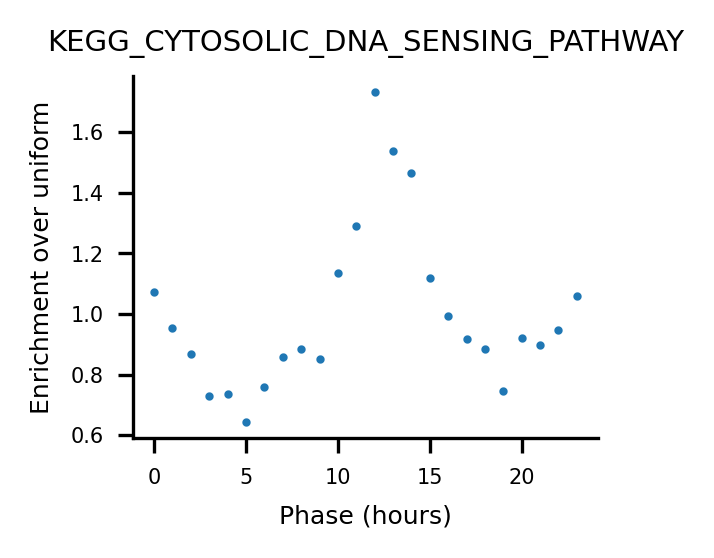

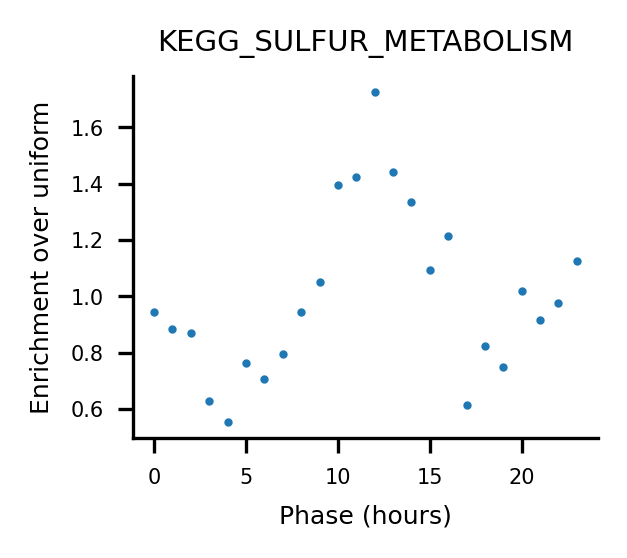

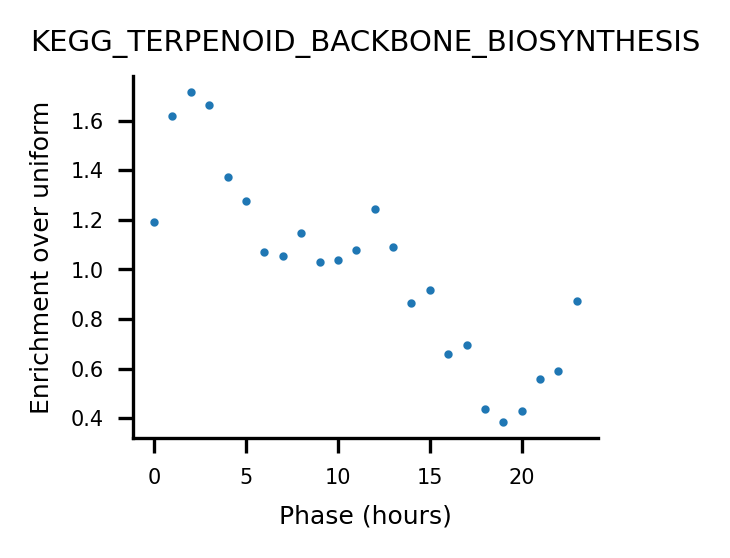

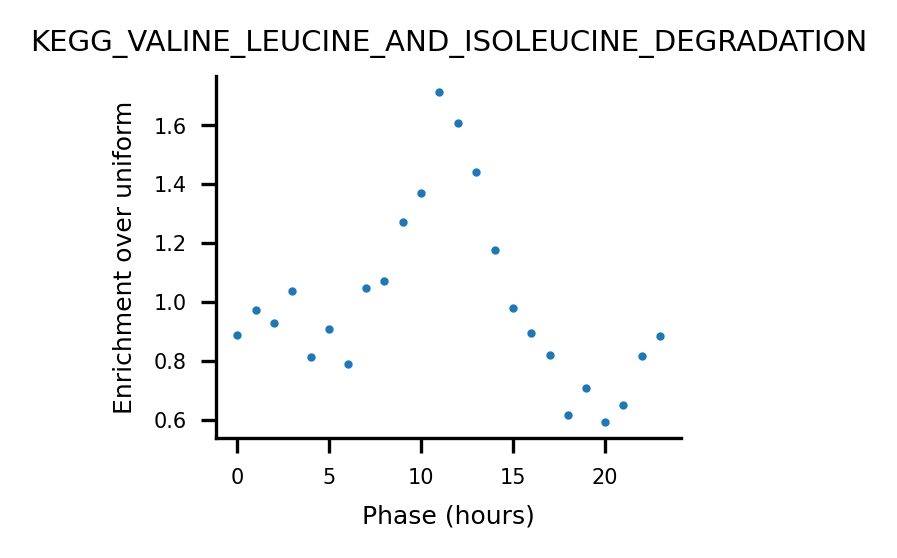

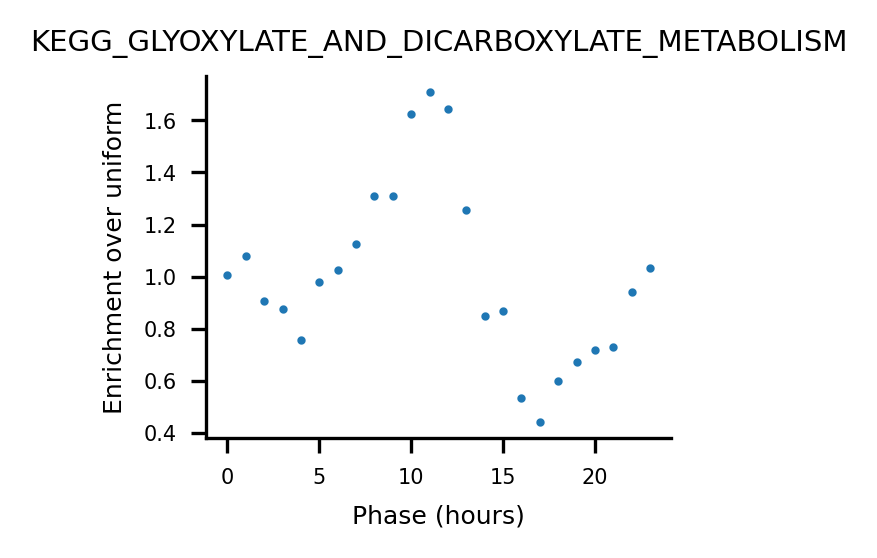

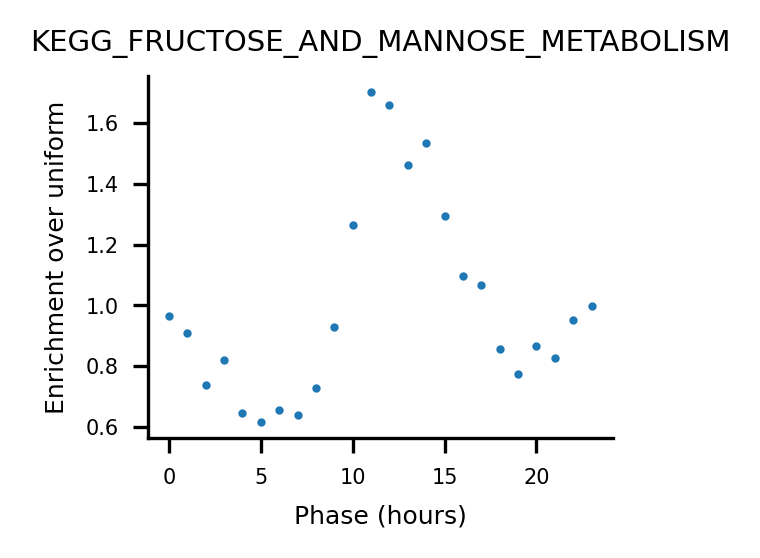

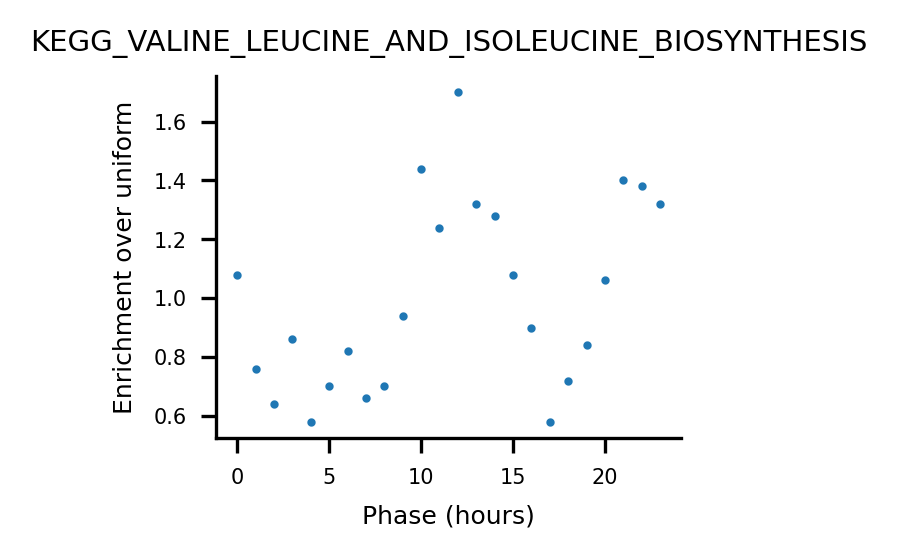

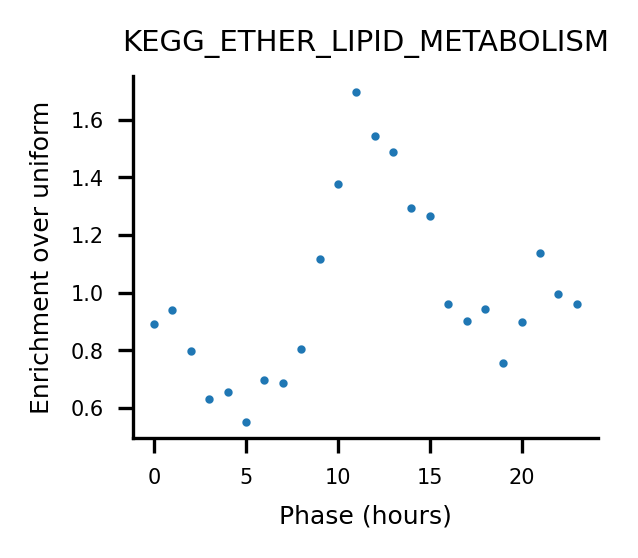

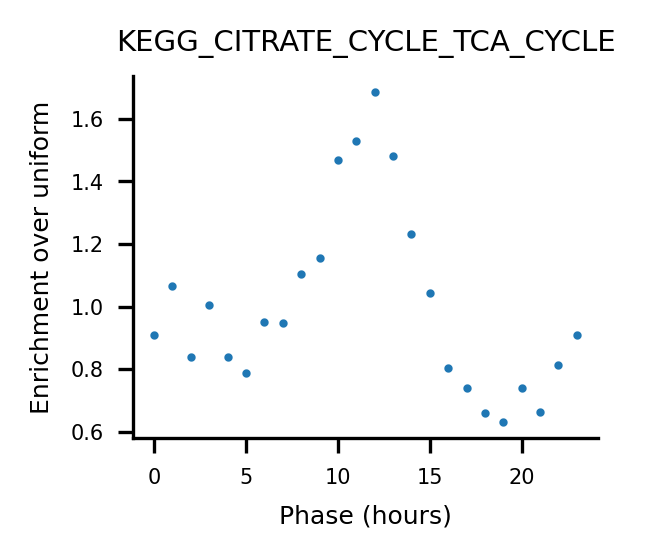

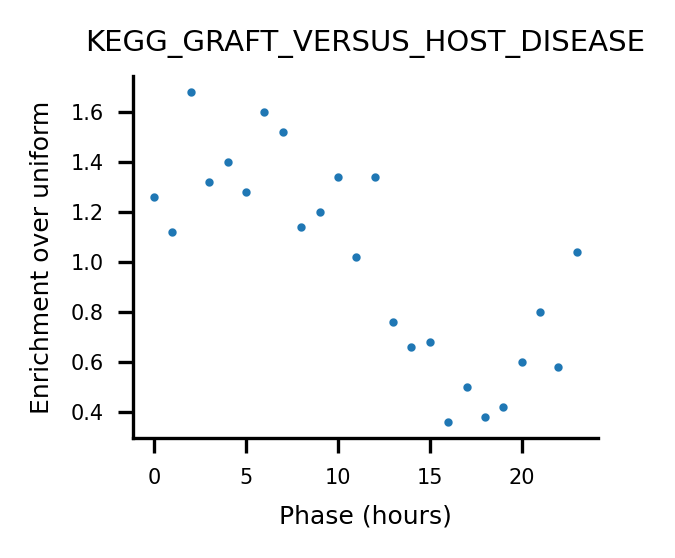

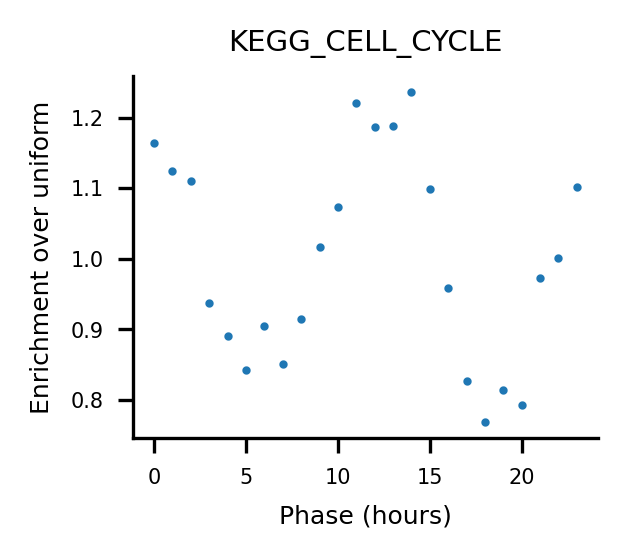

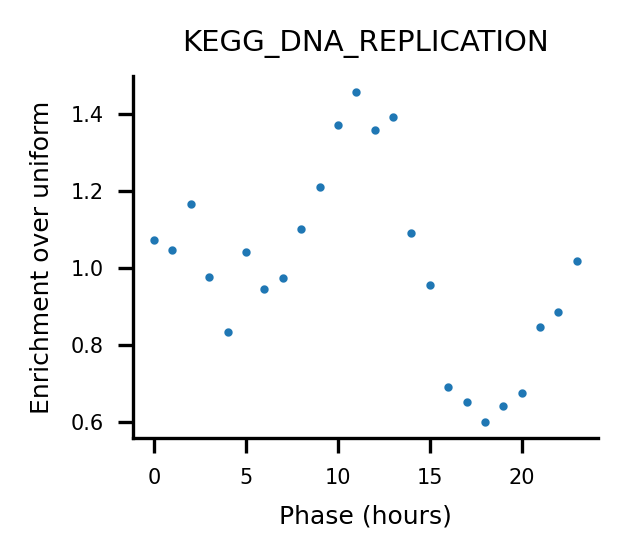

Dropping 0 keys


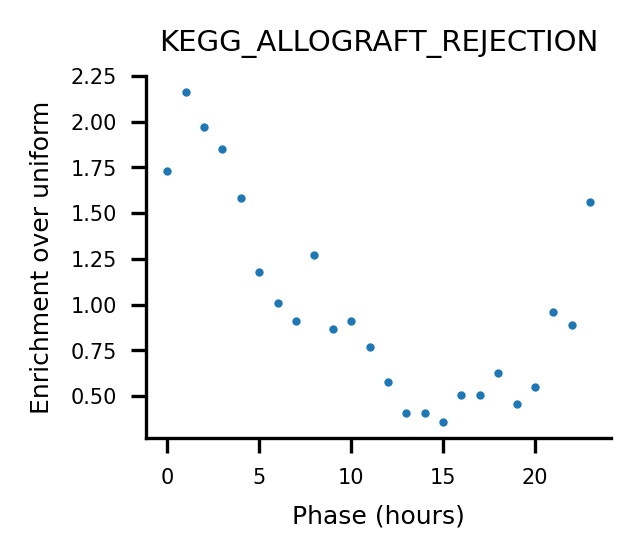

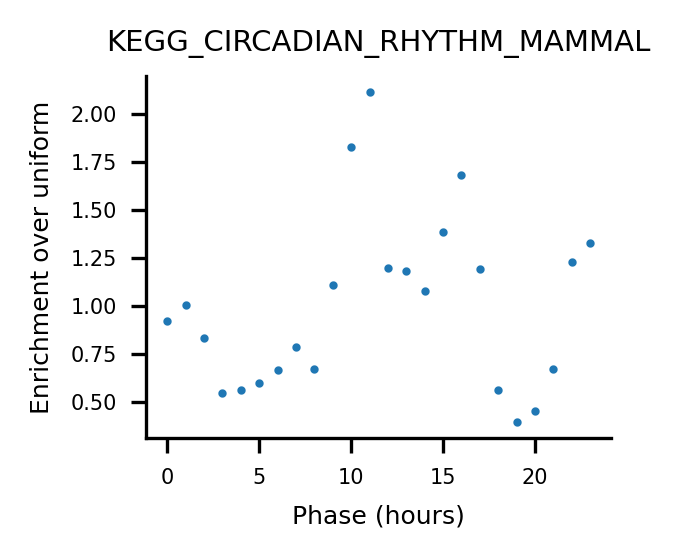

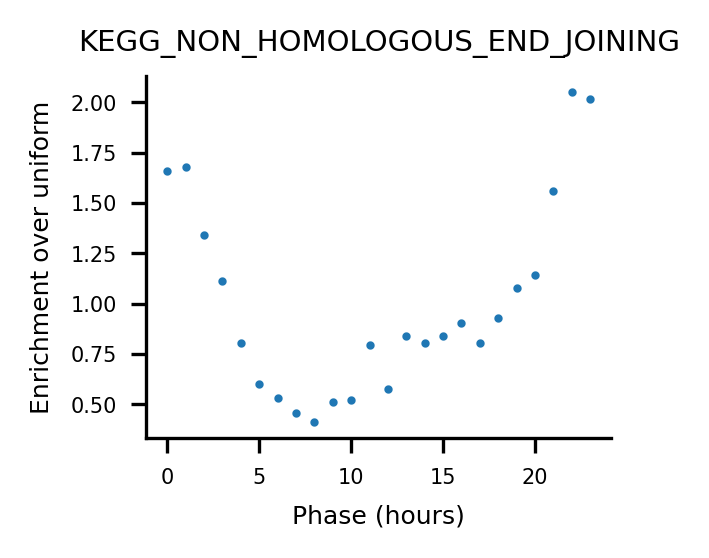

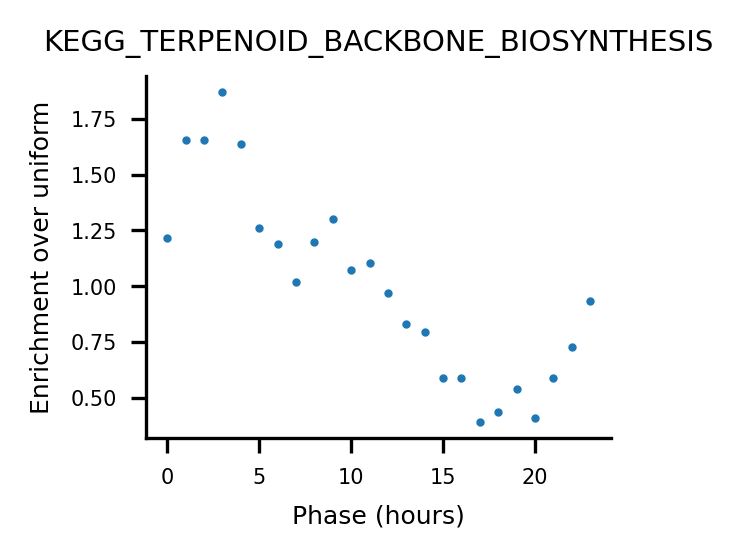

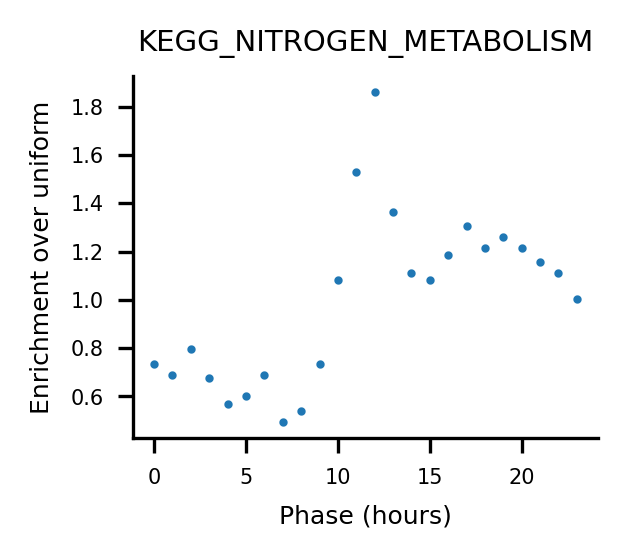

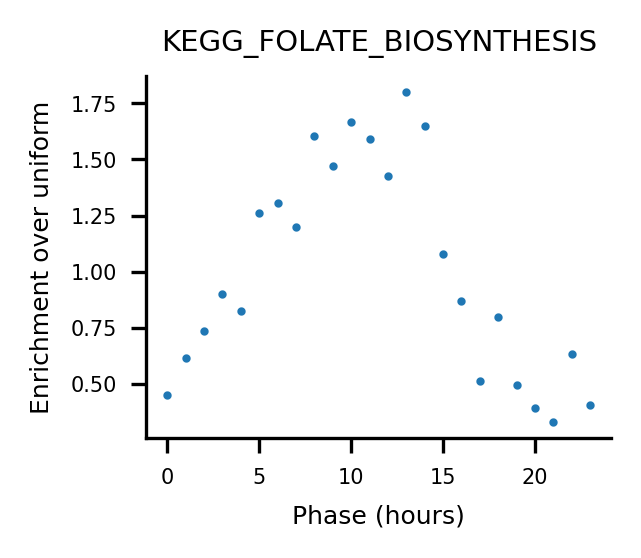

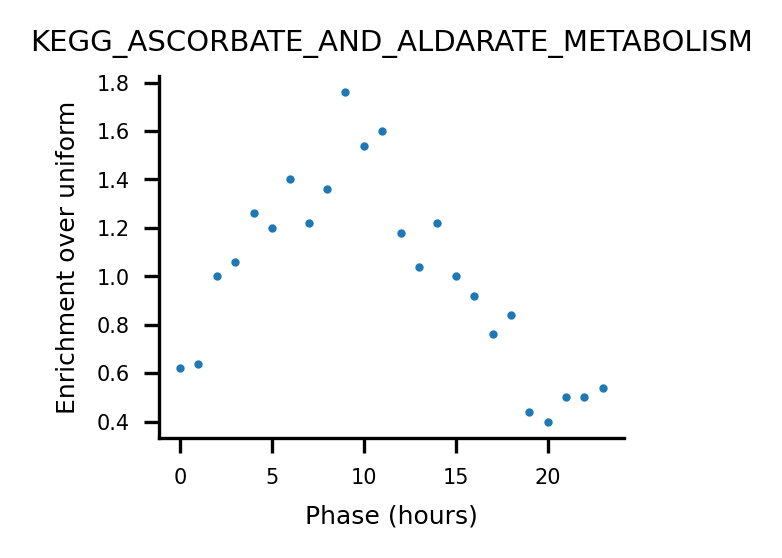

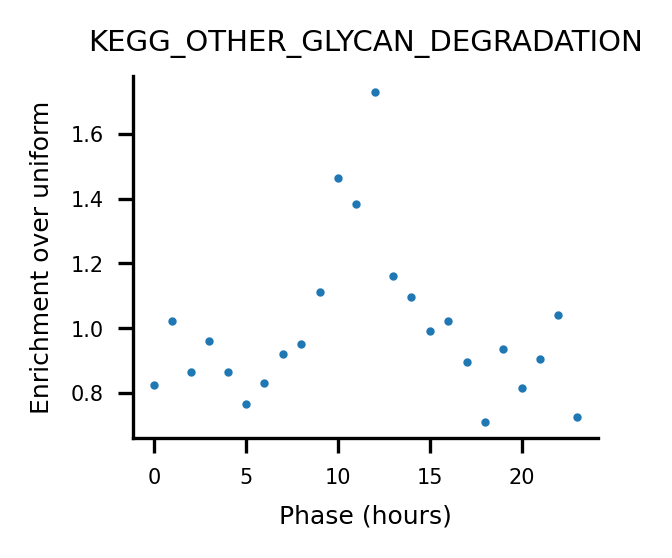

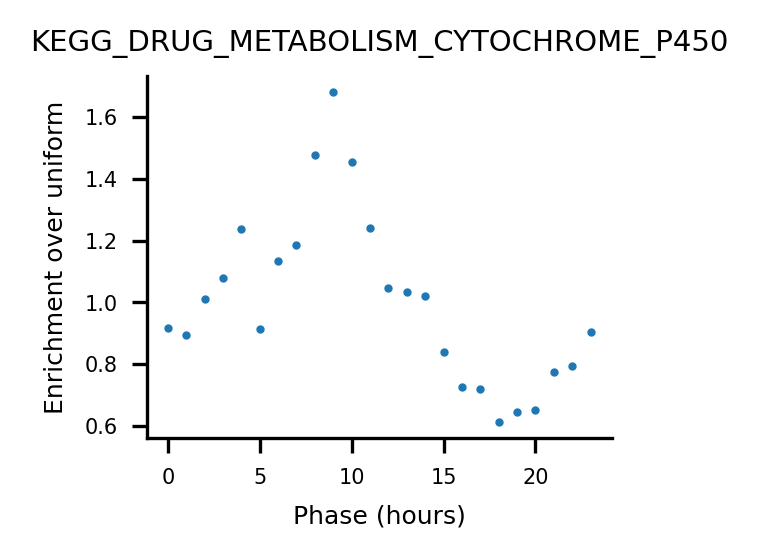

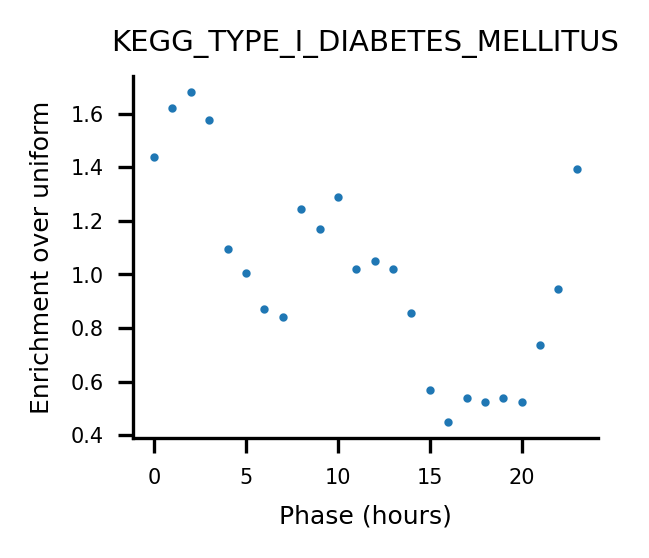

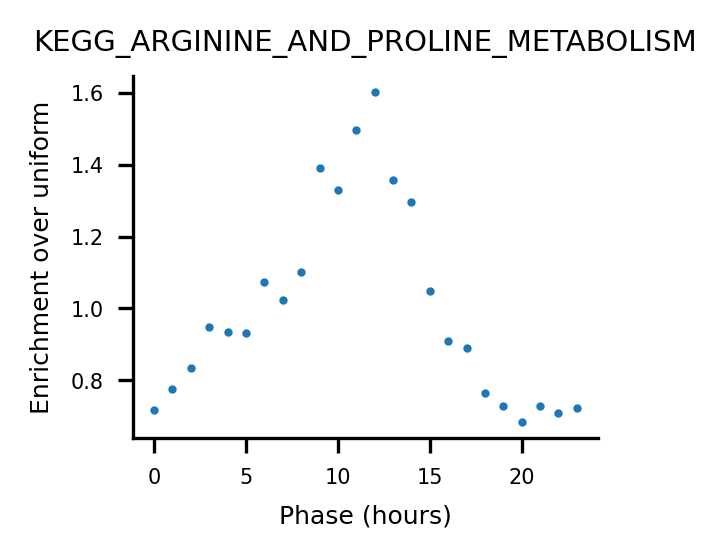

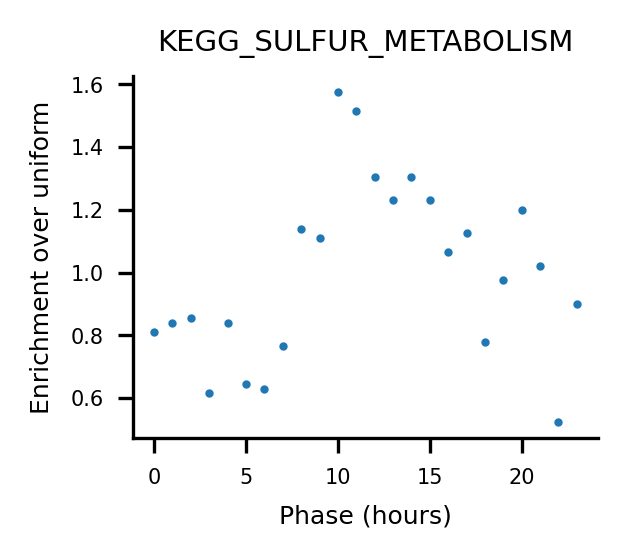

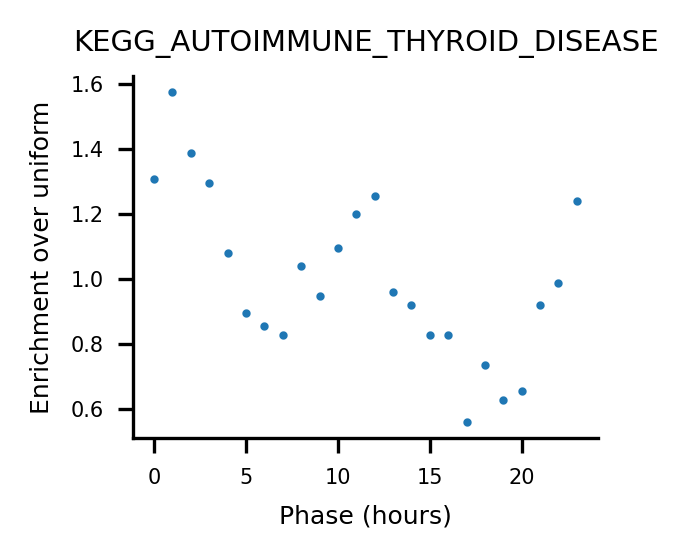

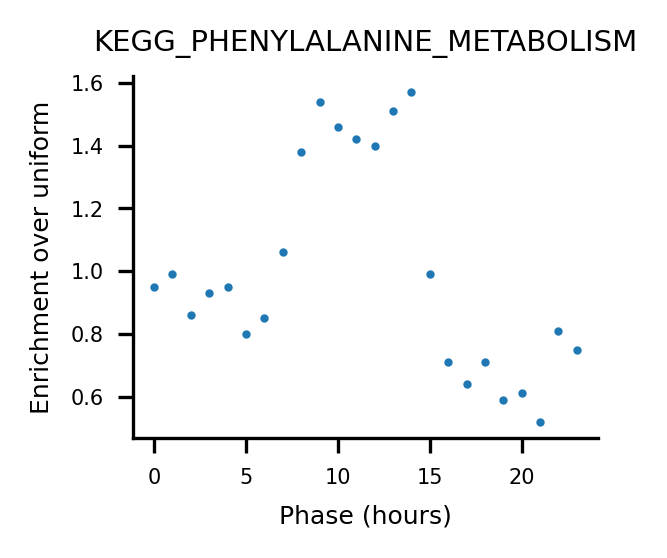

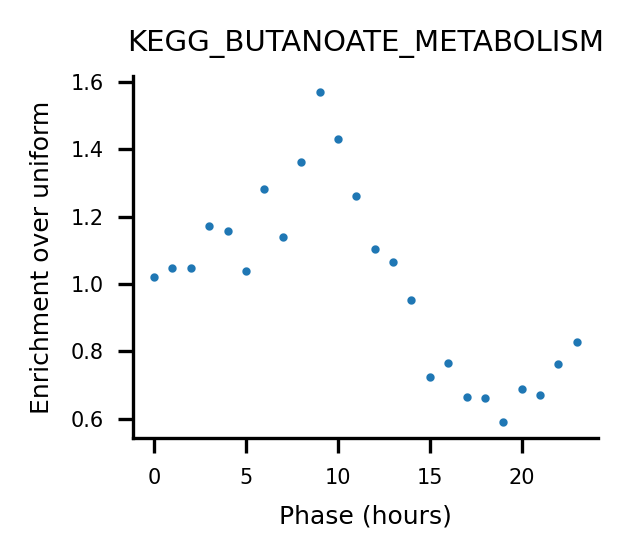

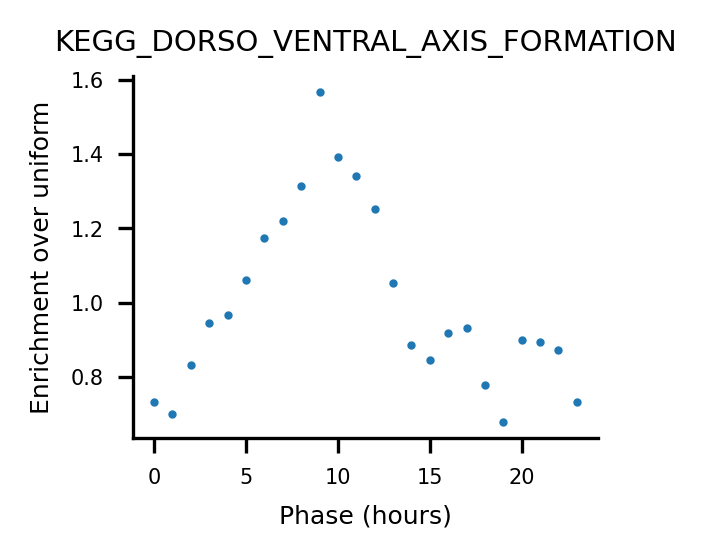

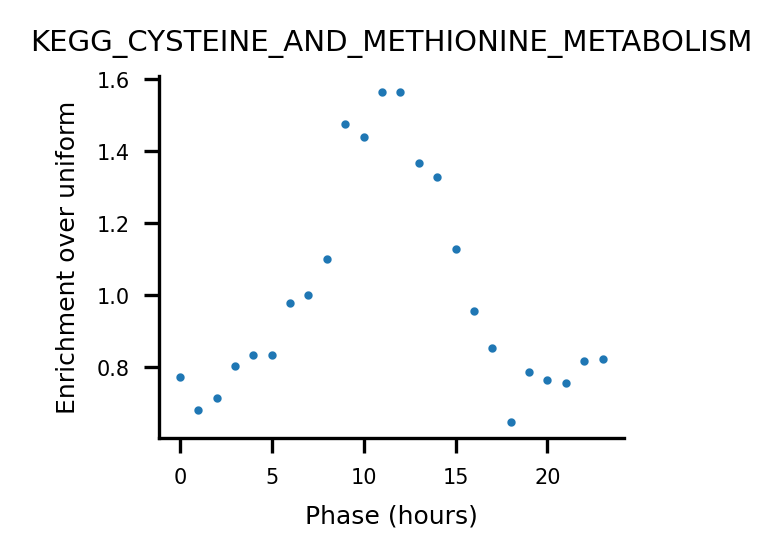

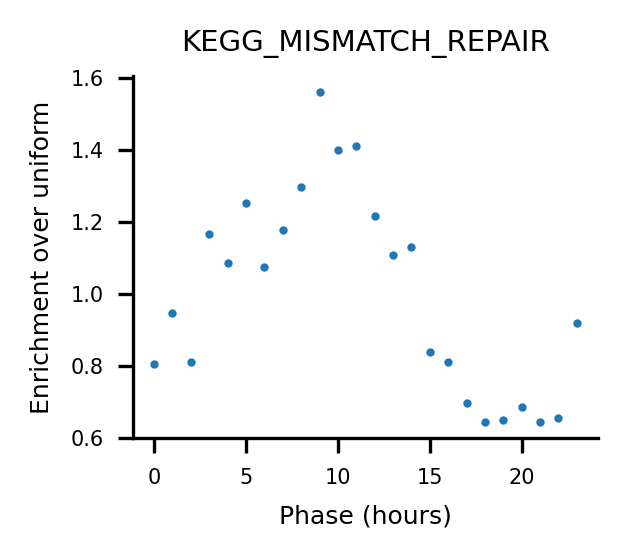

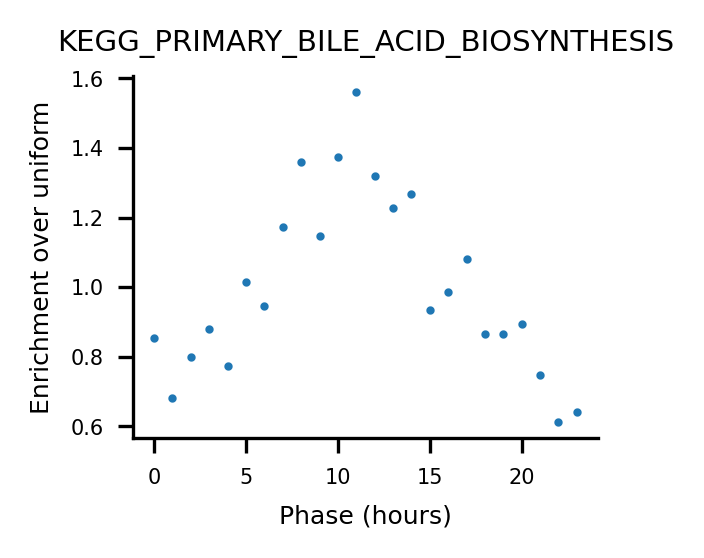

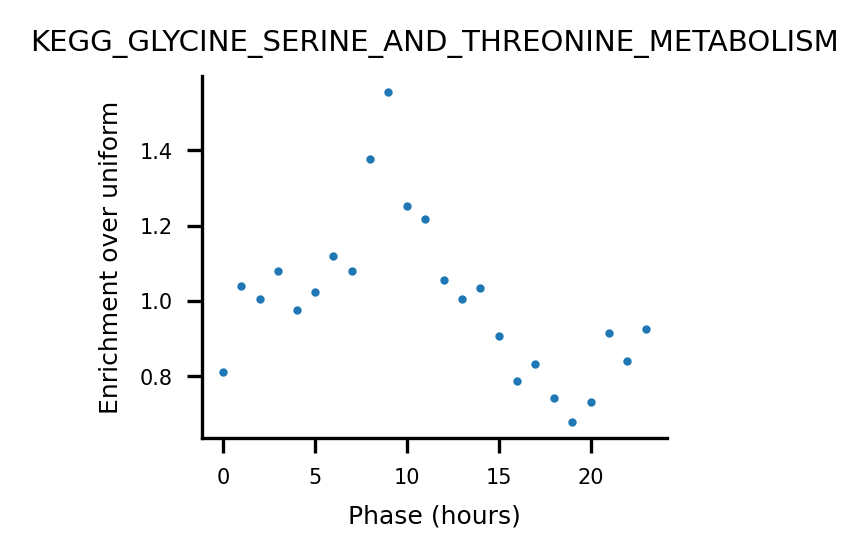

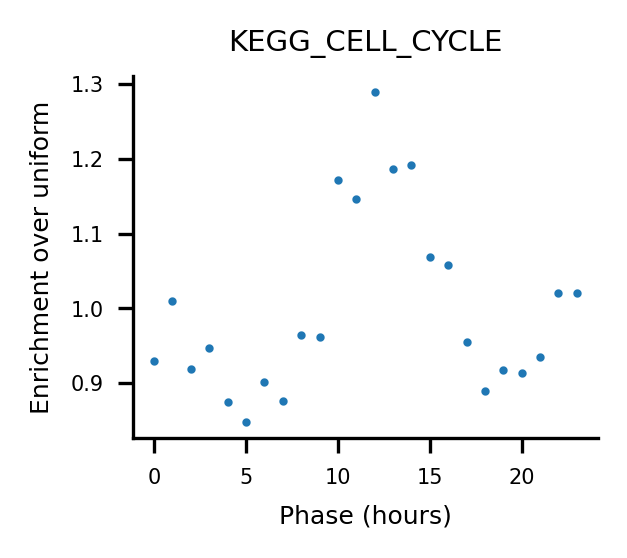

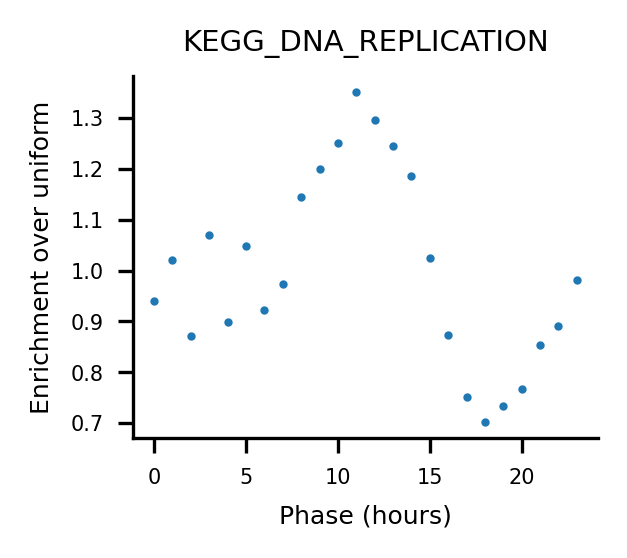

Dropping 0 keys


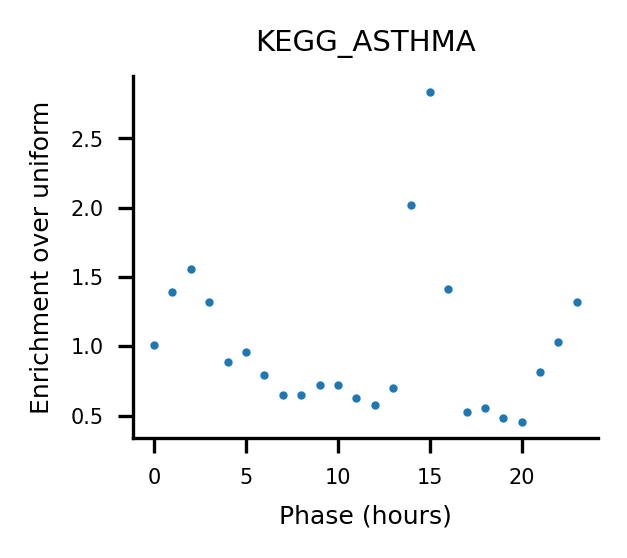

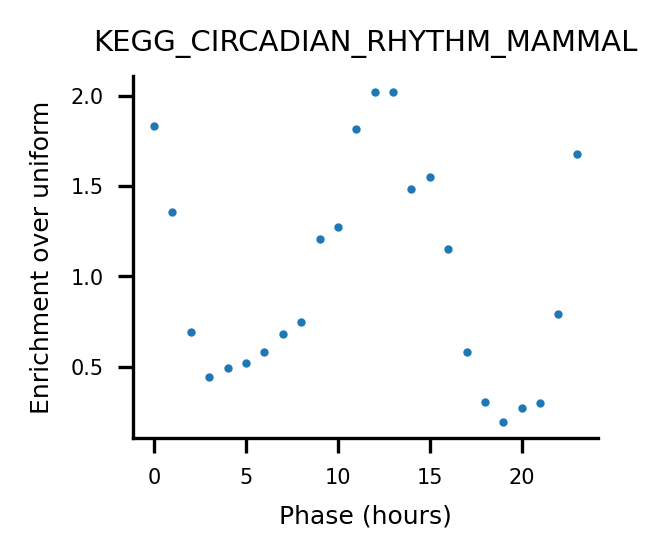

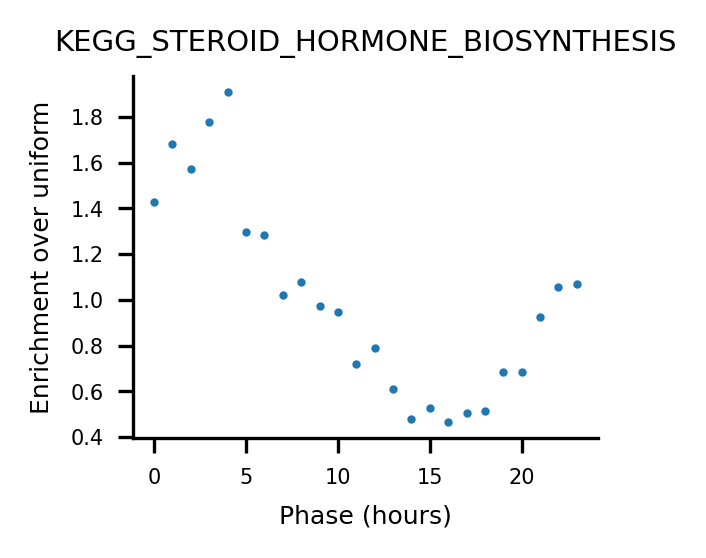

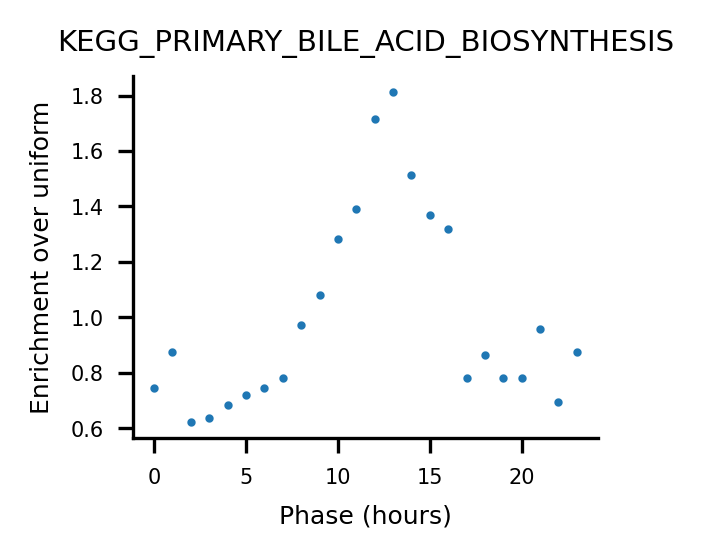

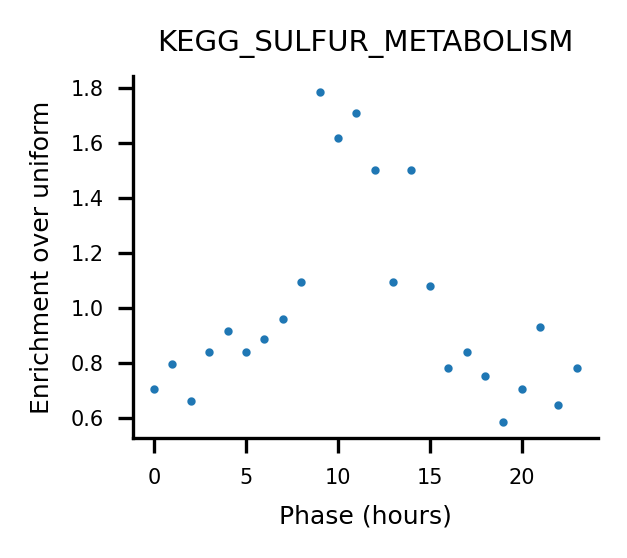

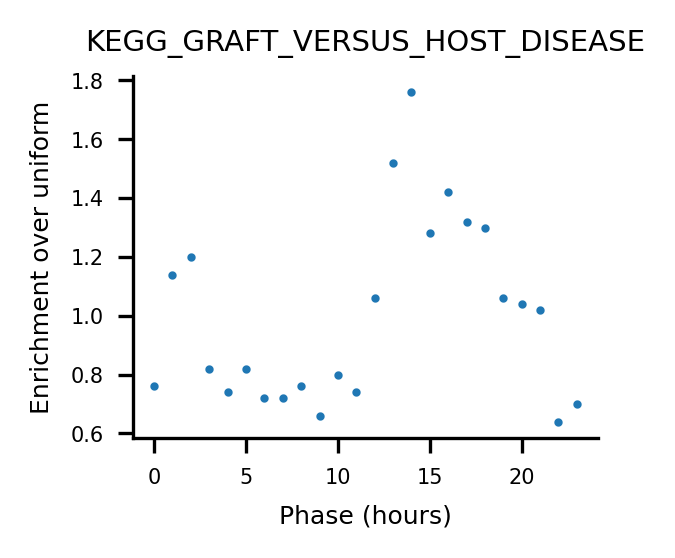

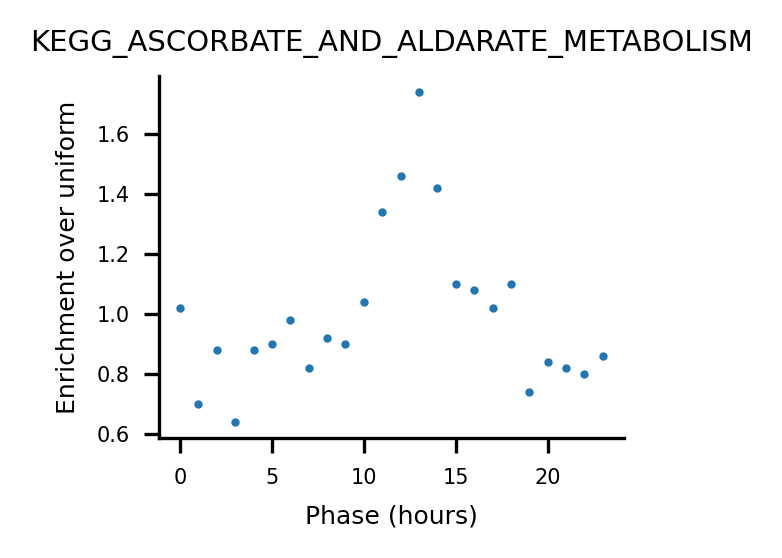

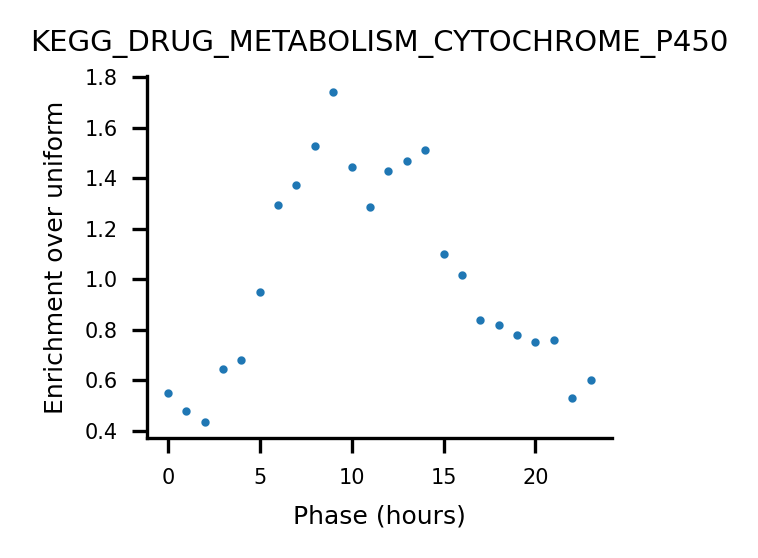

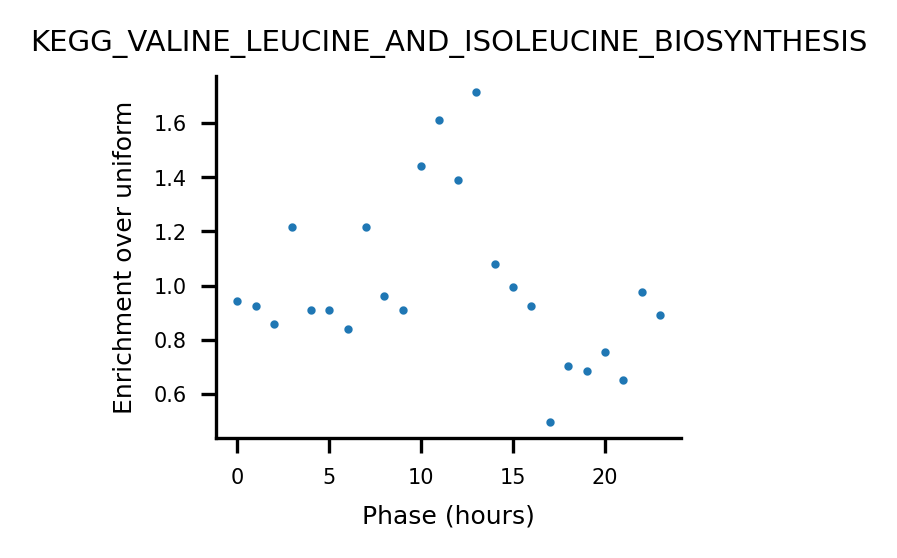

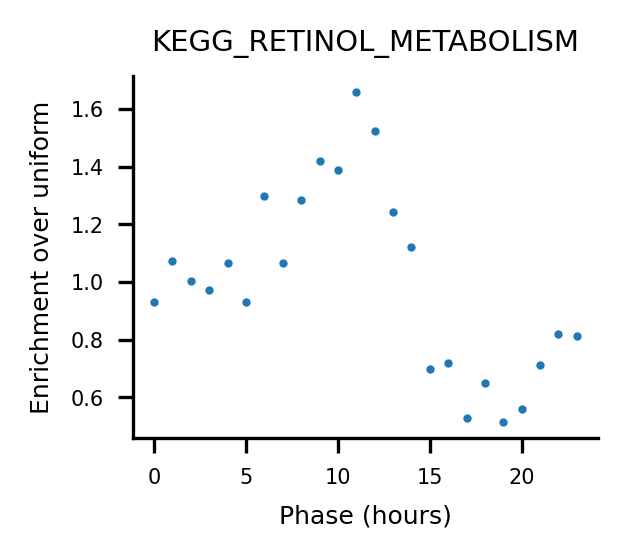

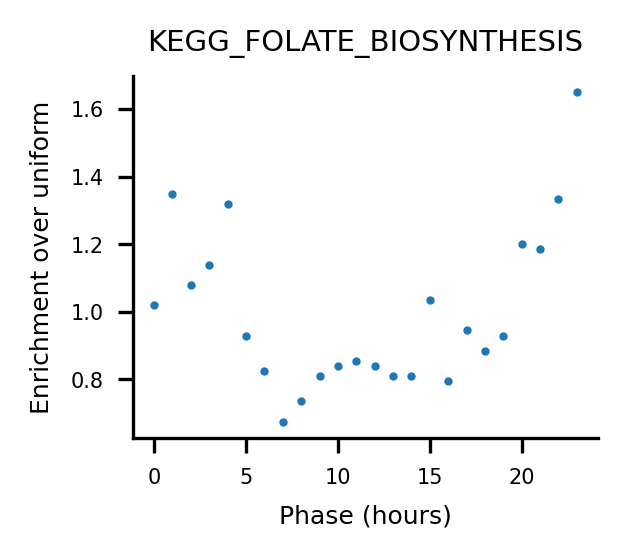

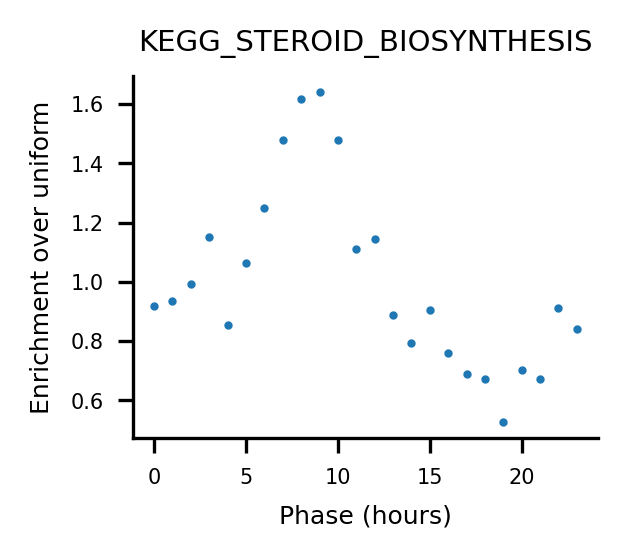

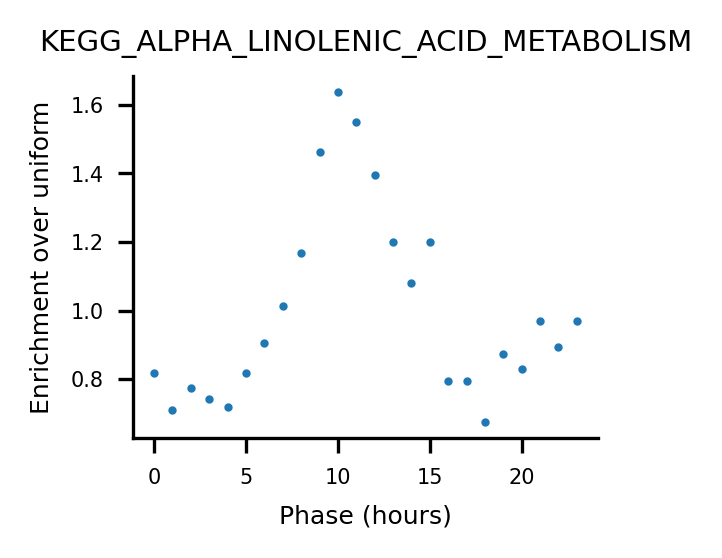

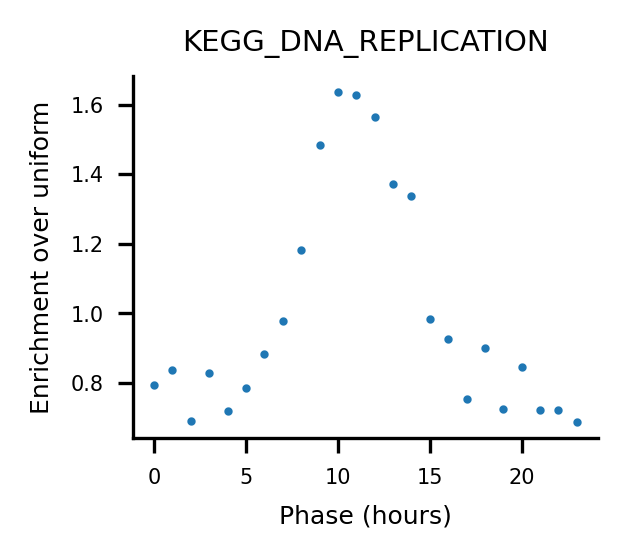

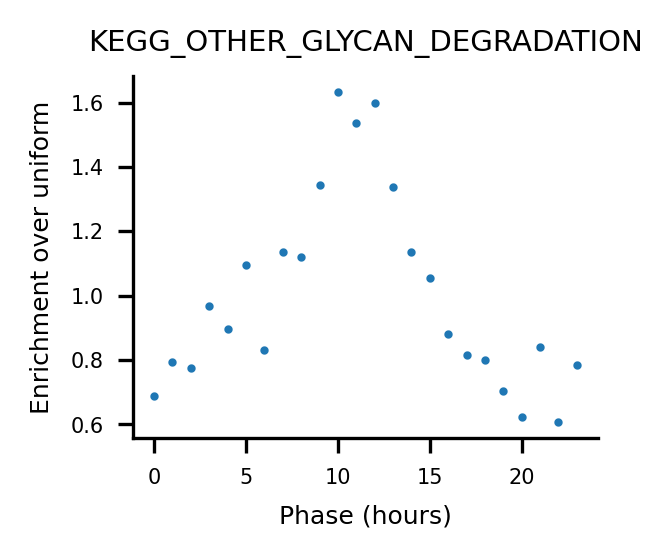

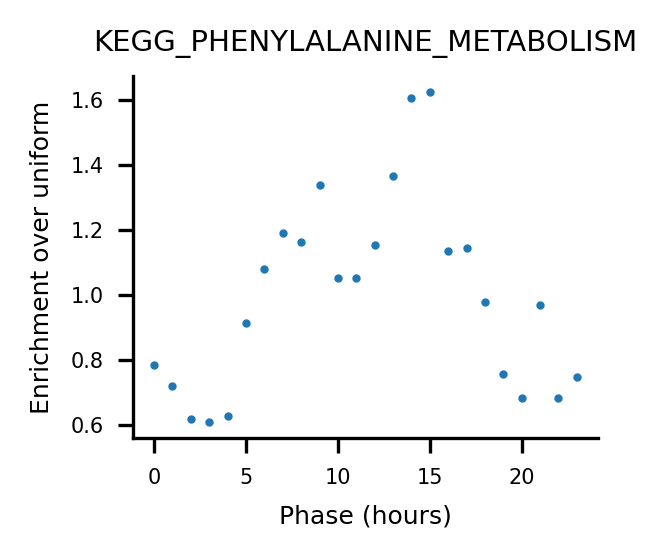

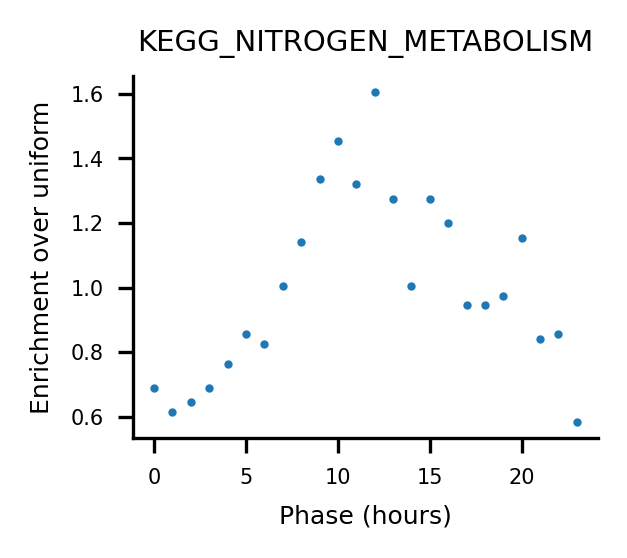

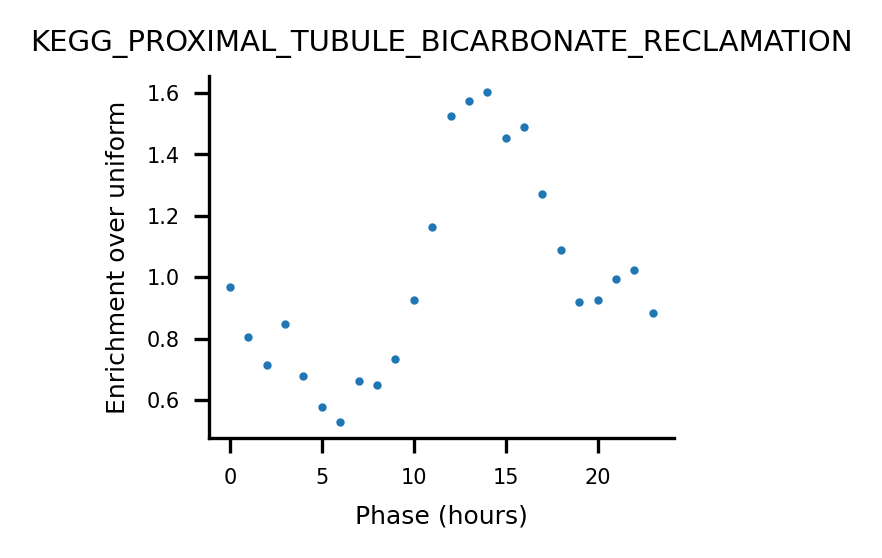

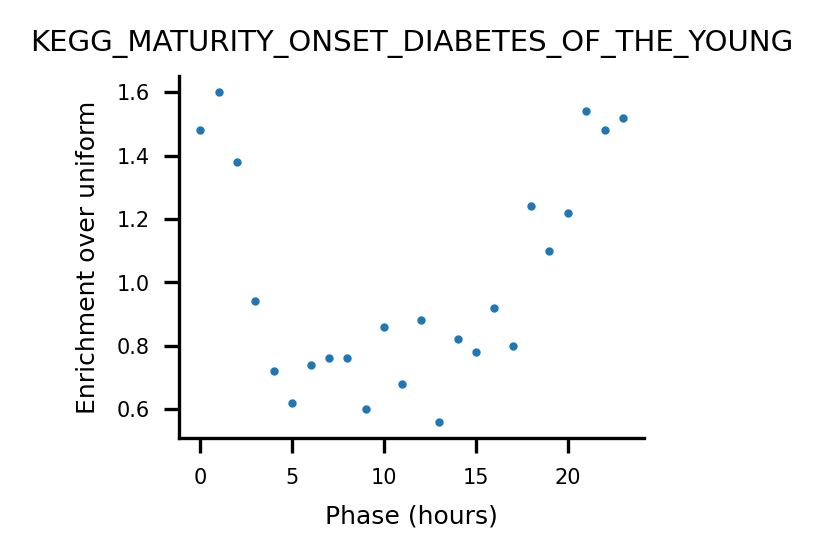

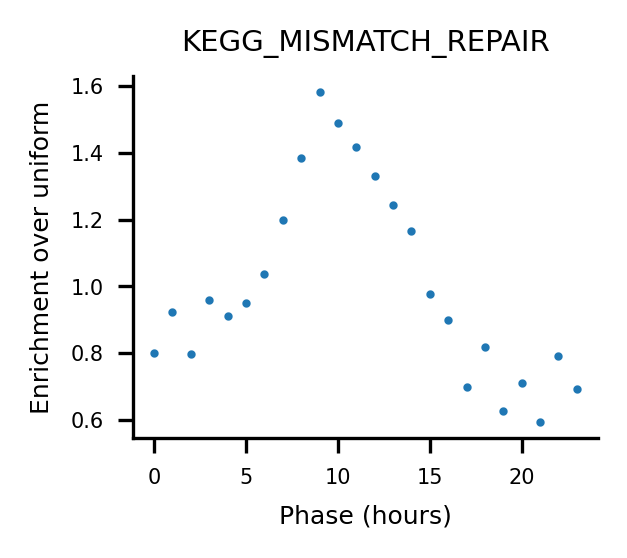

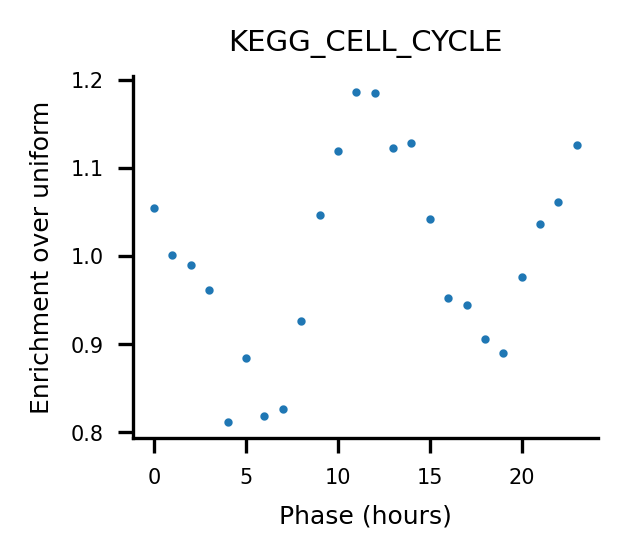

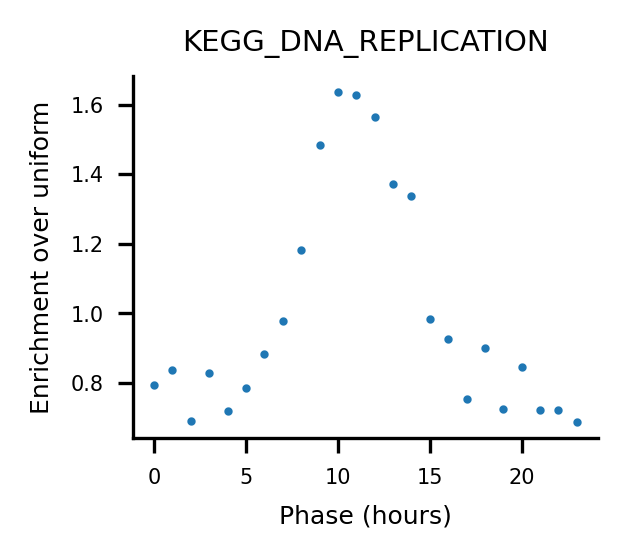

Dropping 1 keys


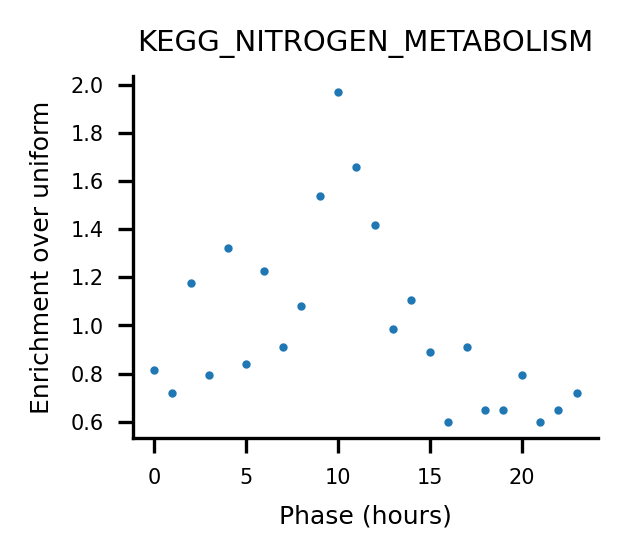

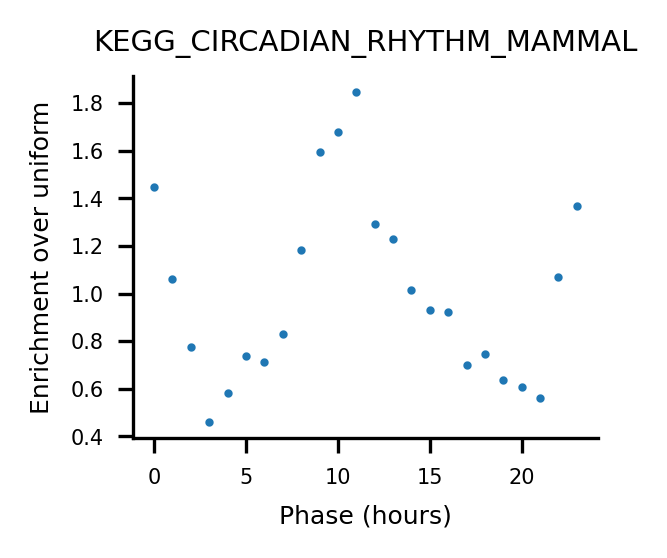

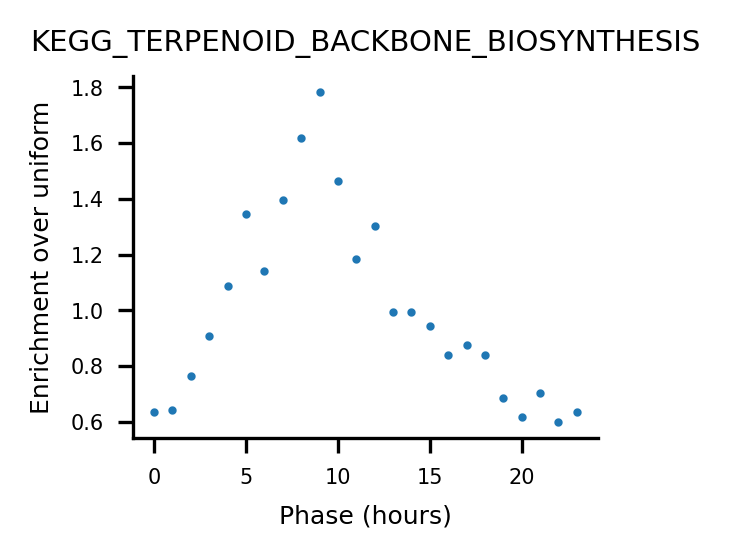

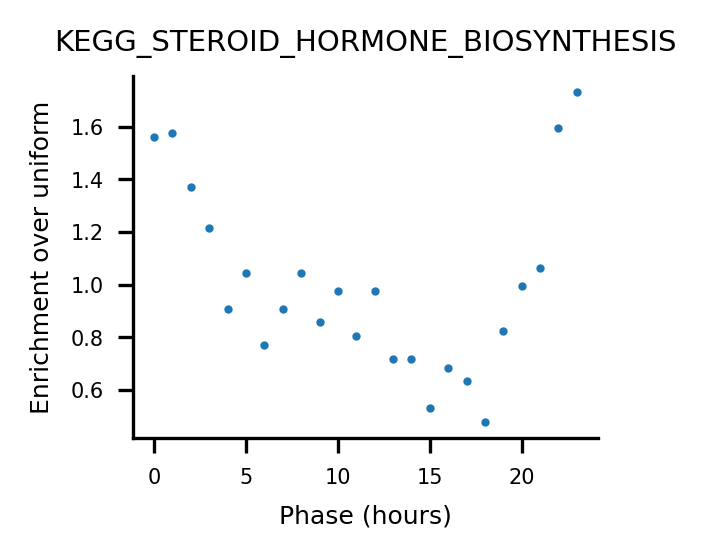

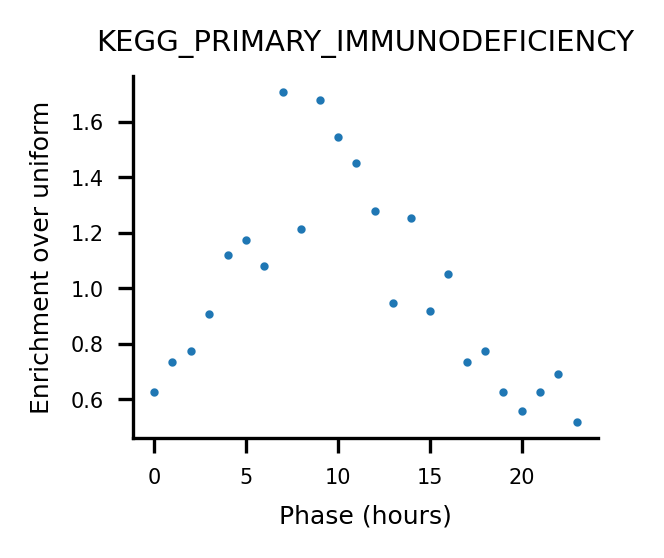

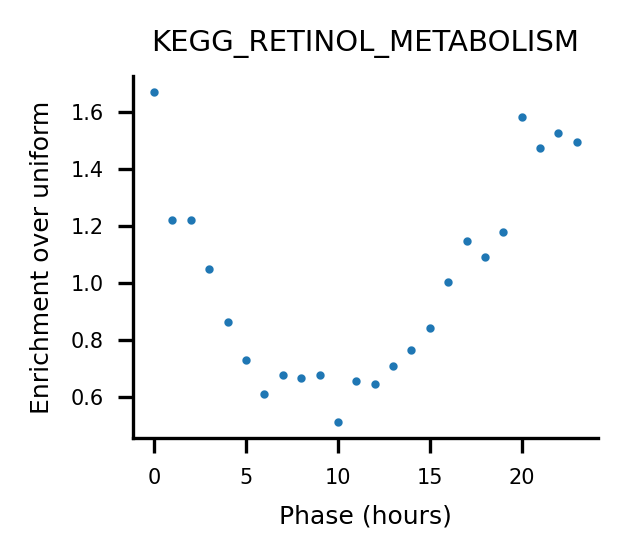

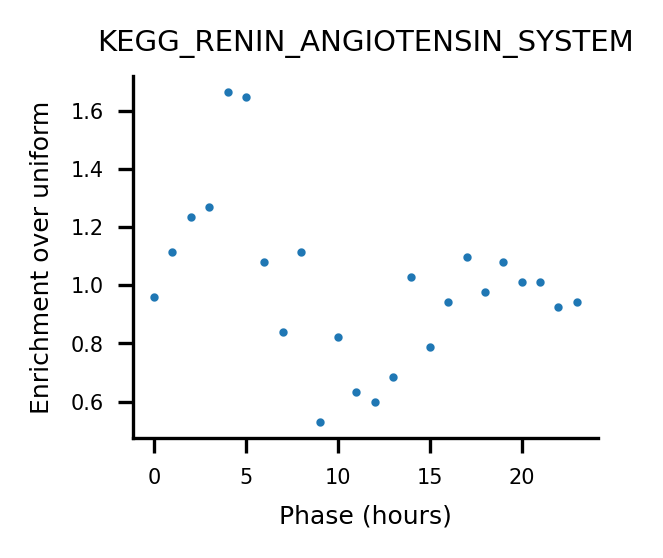

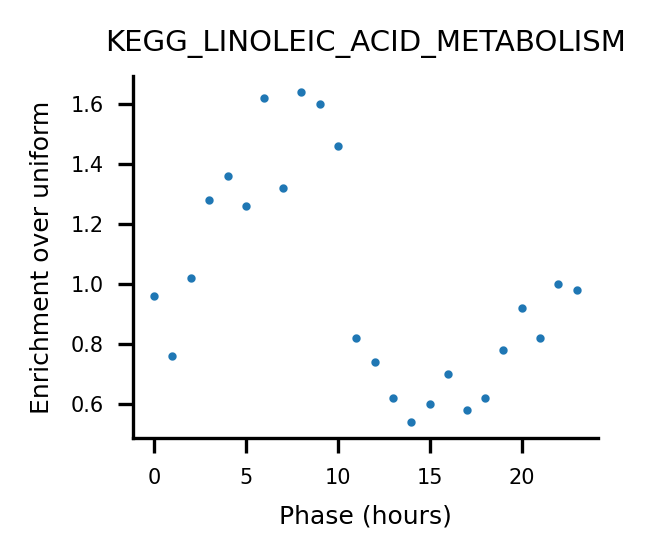

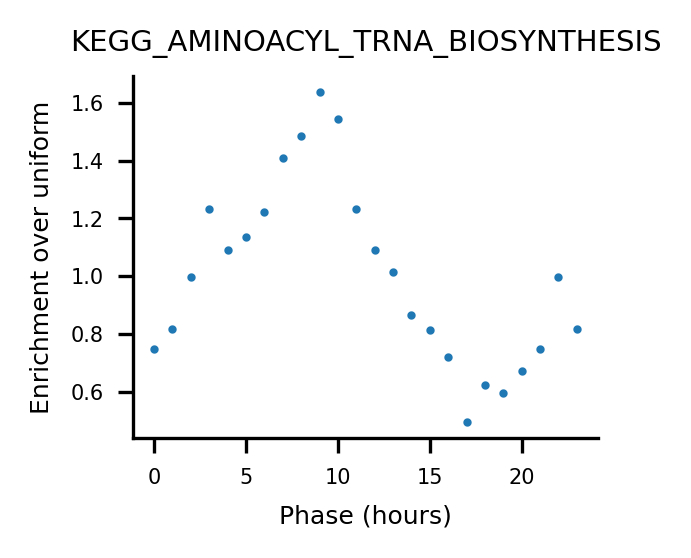

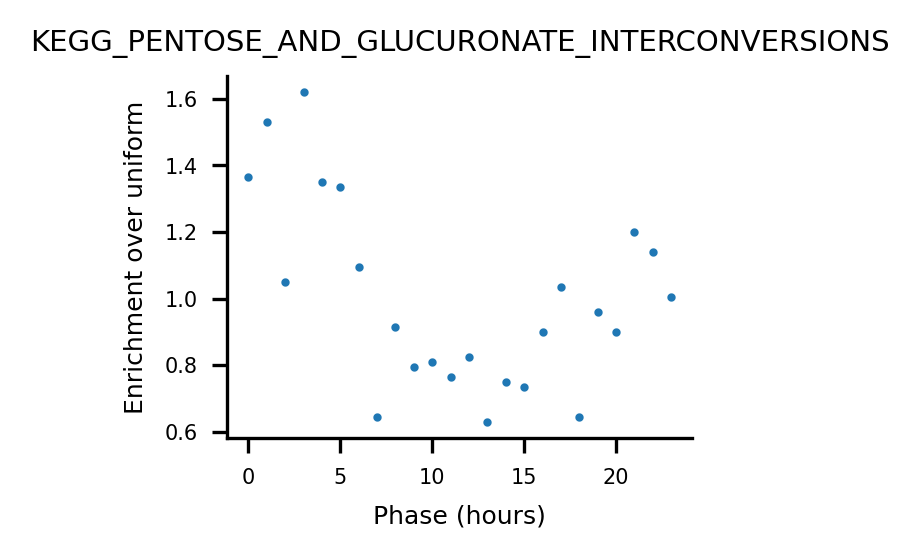

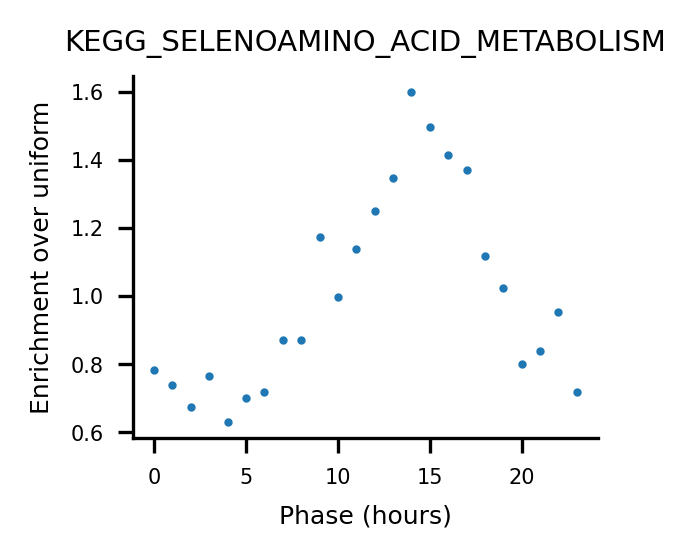

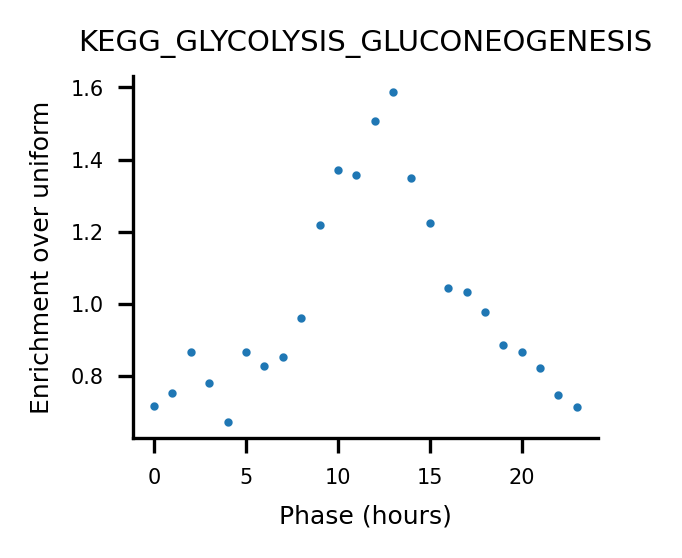

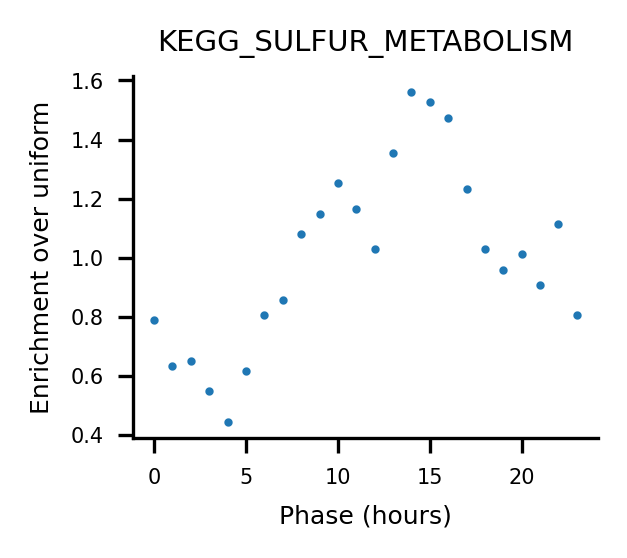

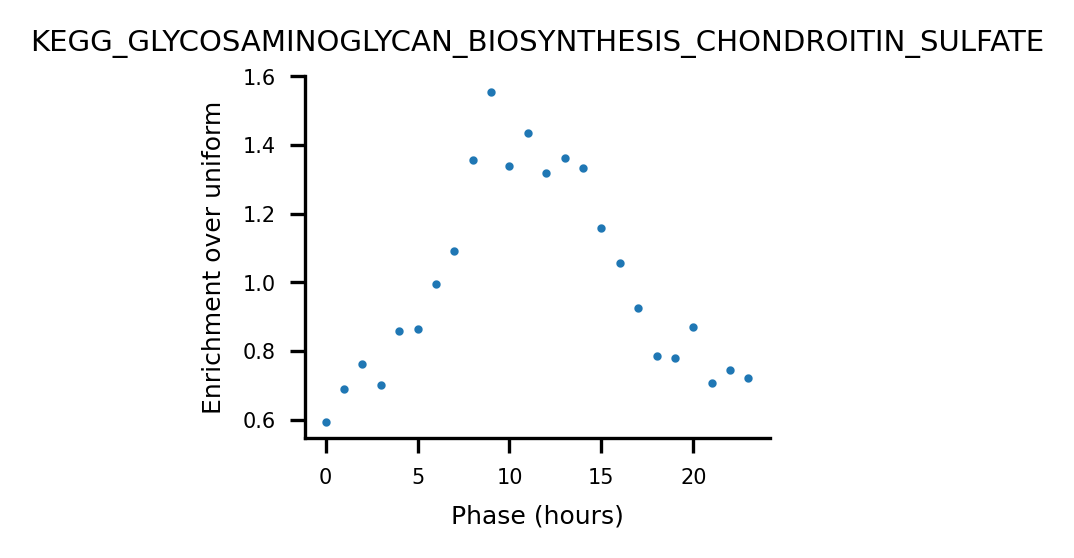

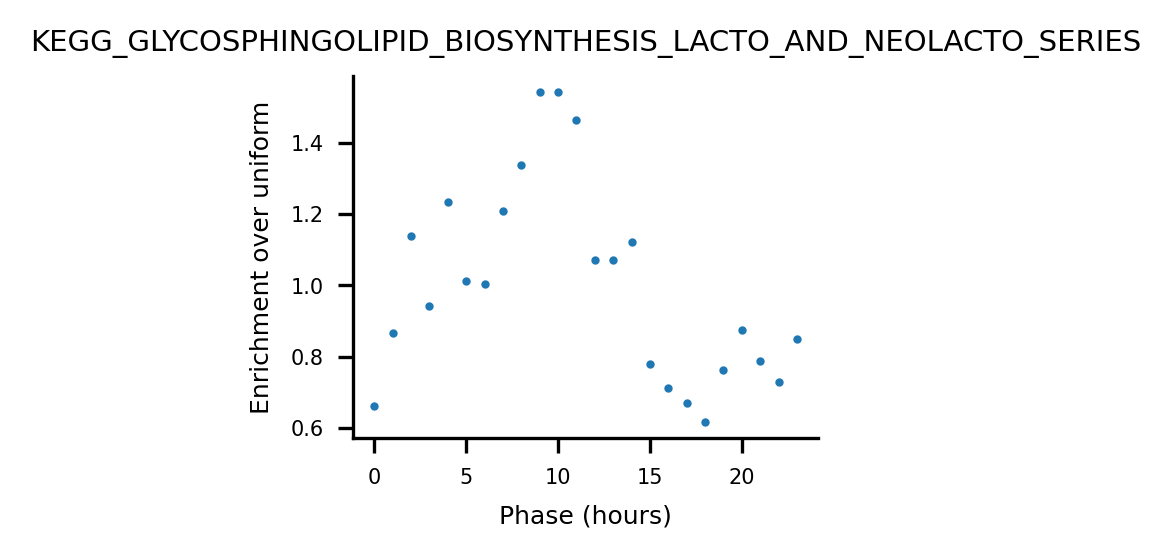

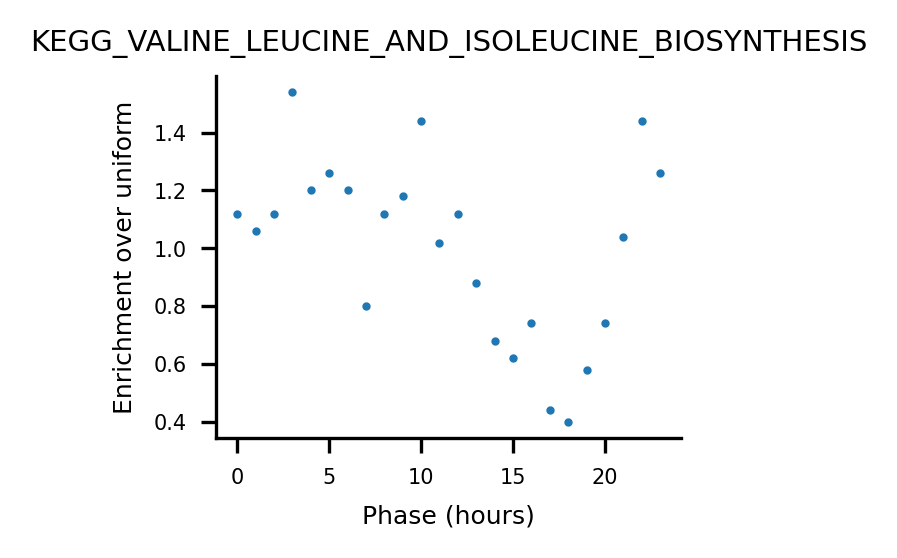

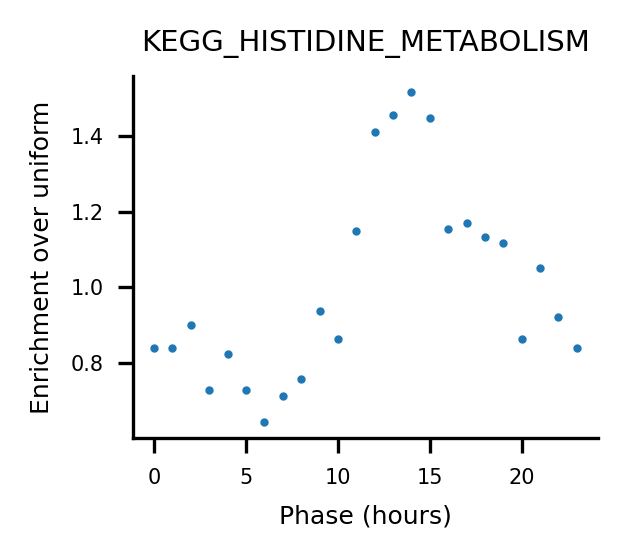

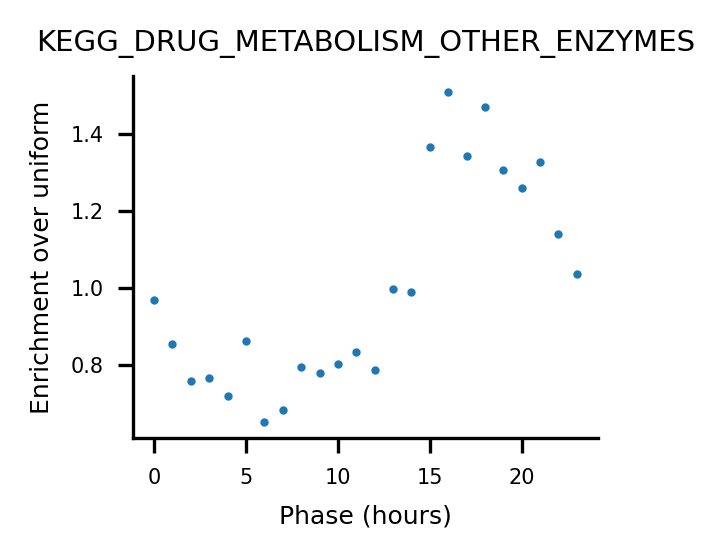

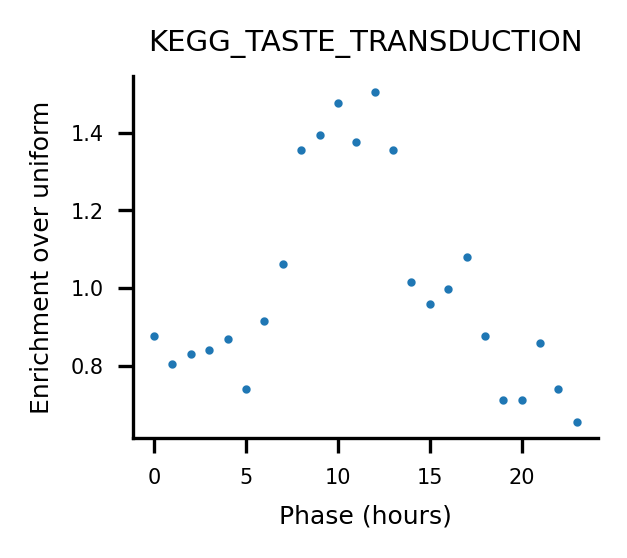

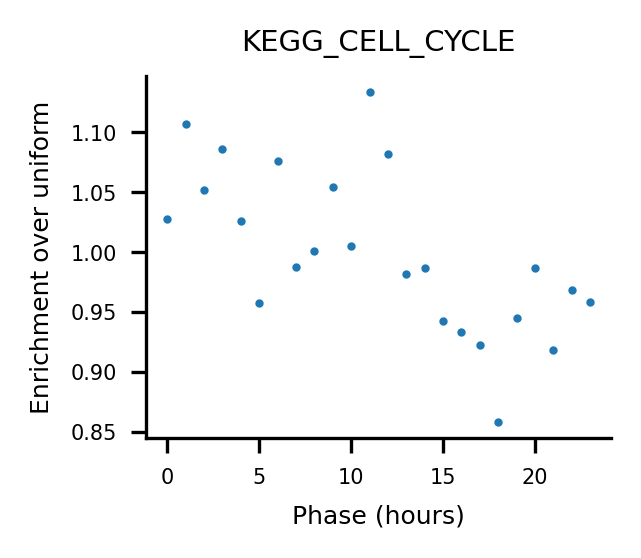

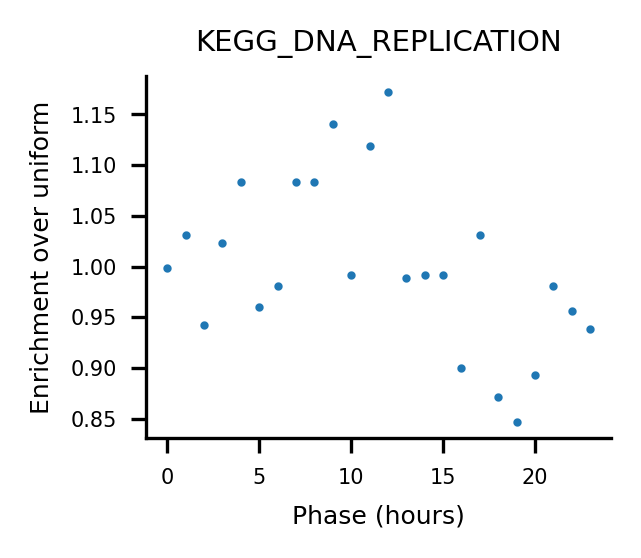

Dropping 0 keys


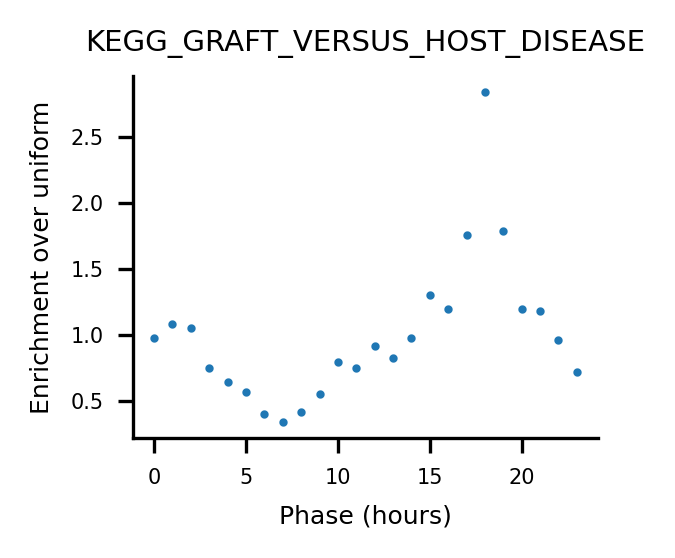

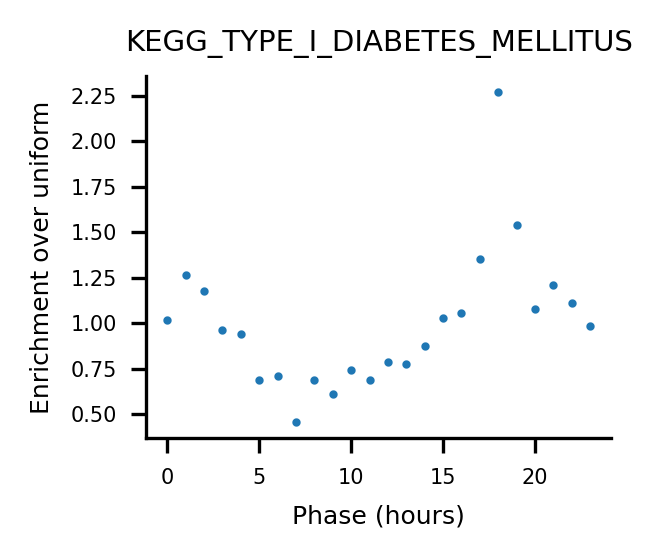

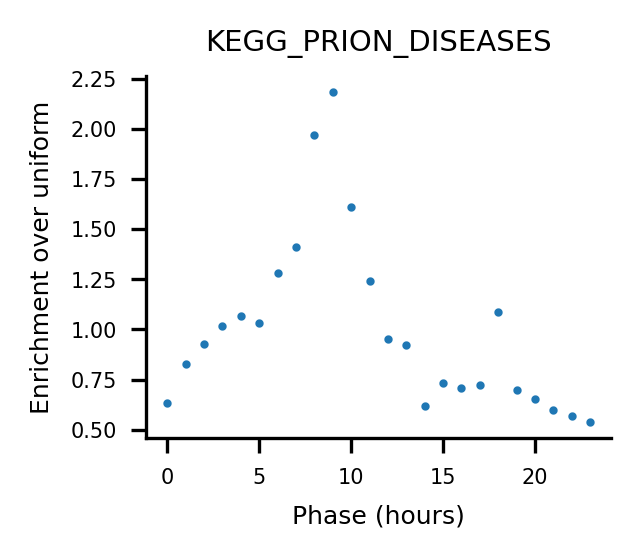

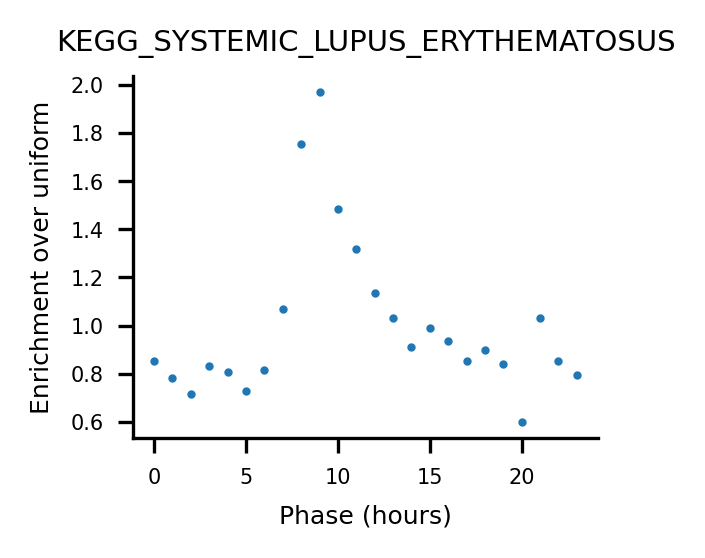

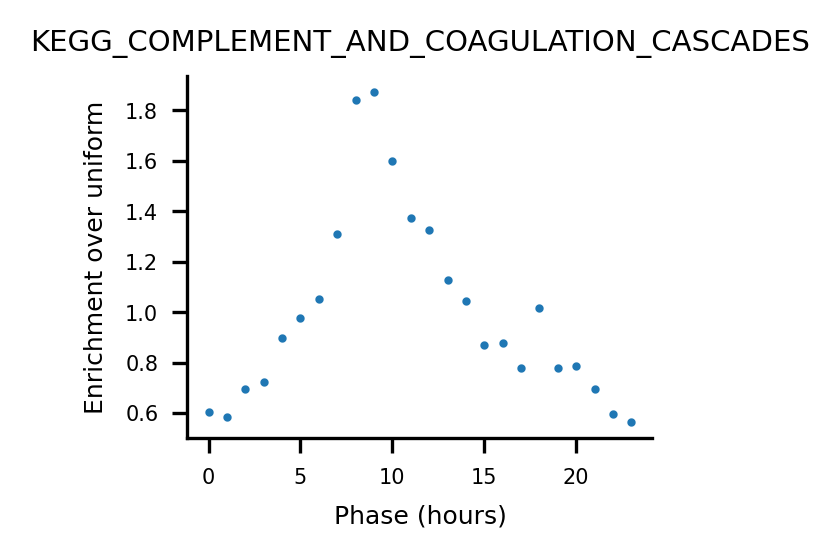

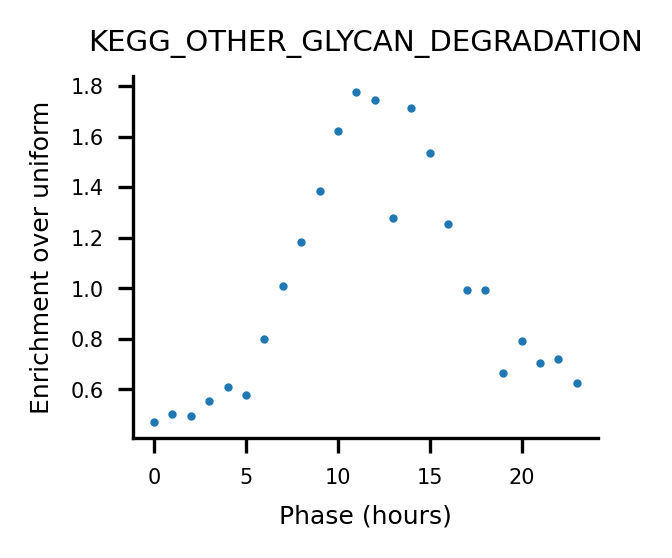

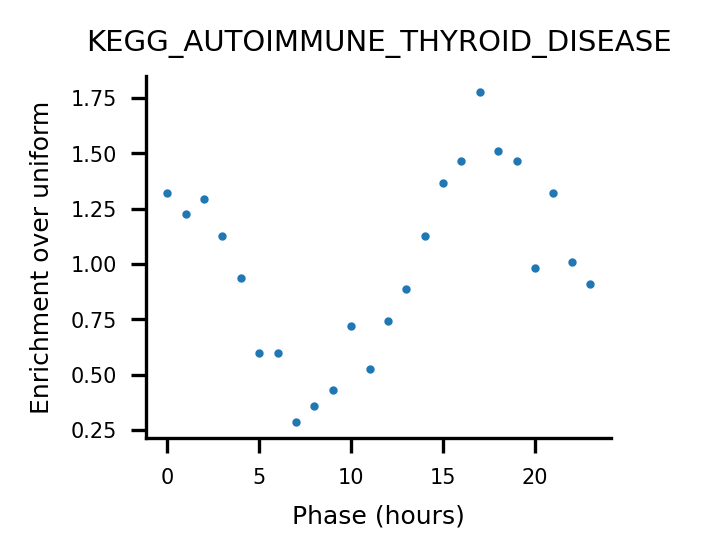

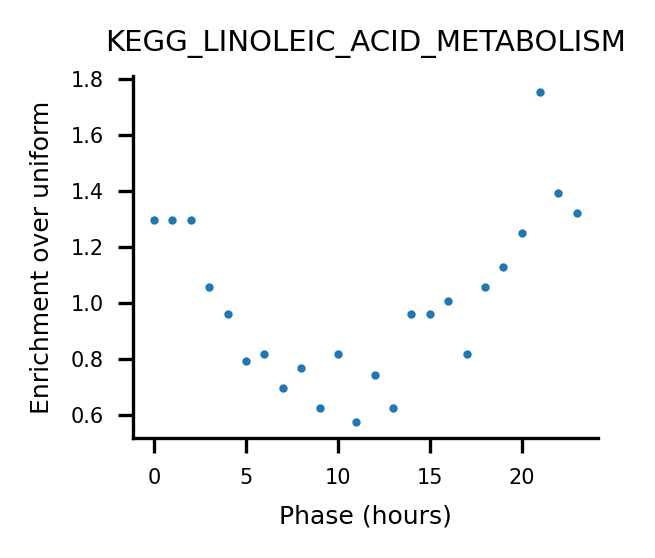

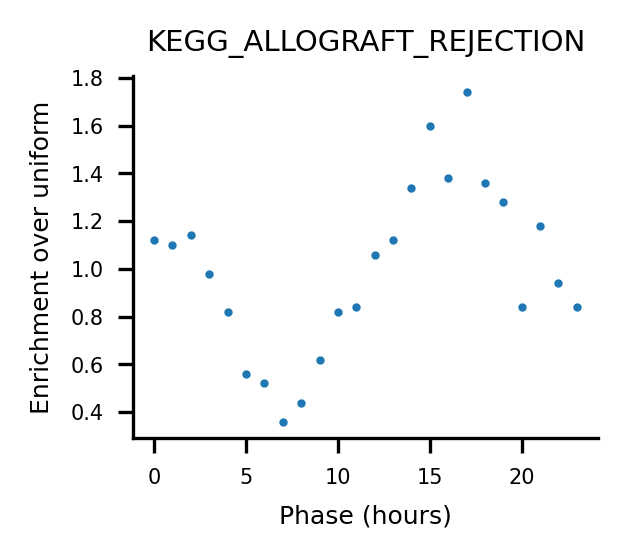

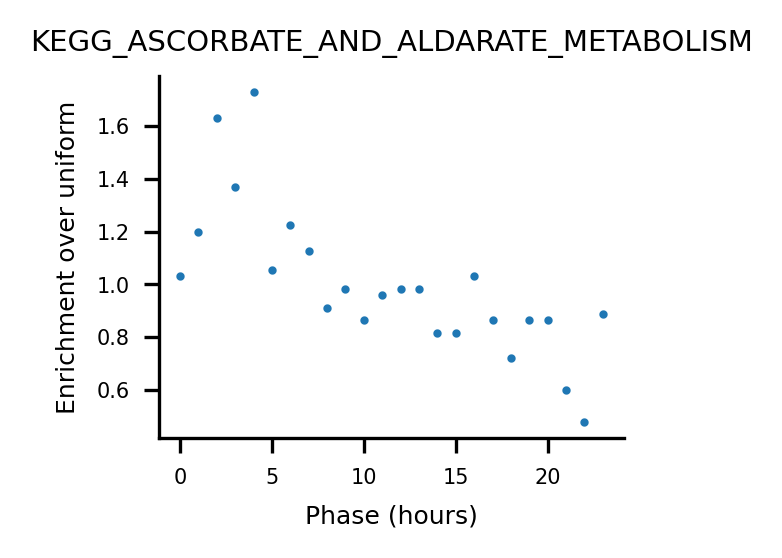

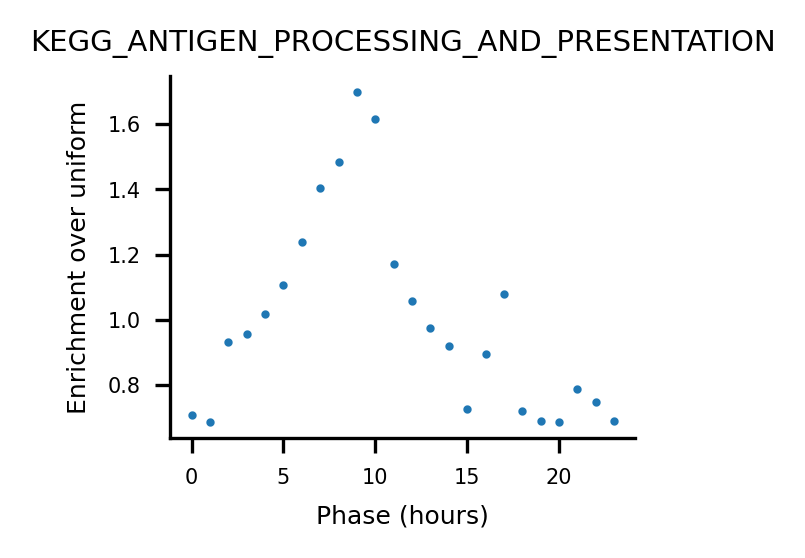

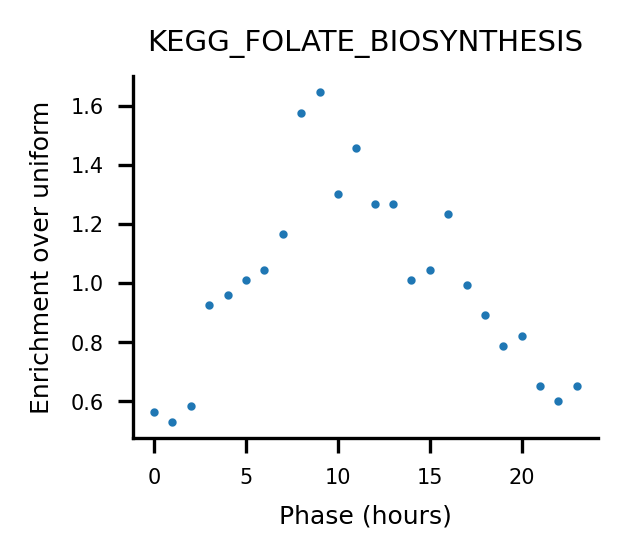

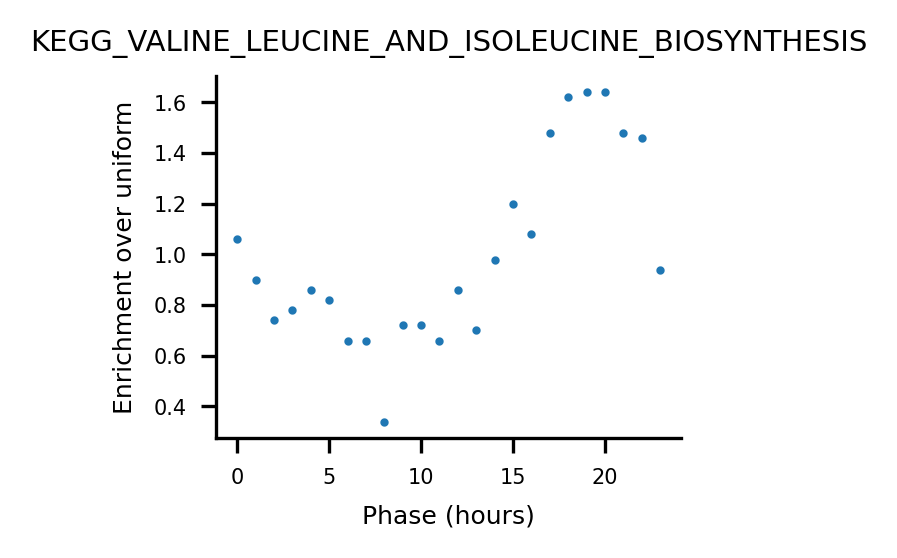

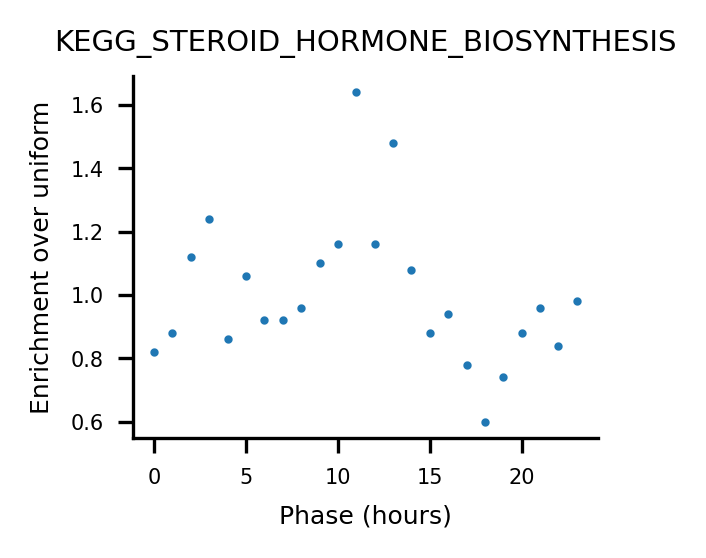

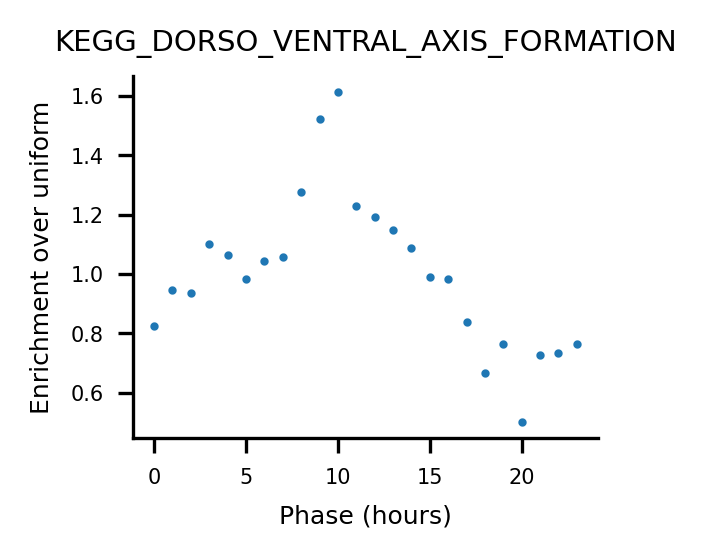

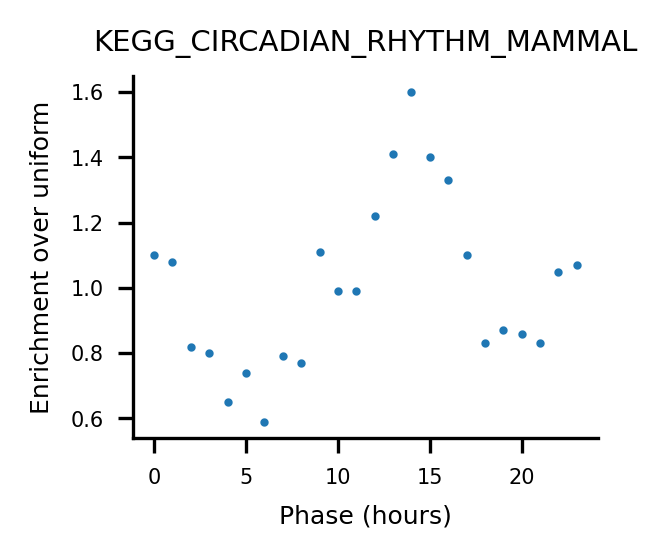

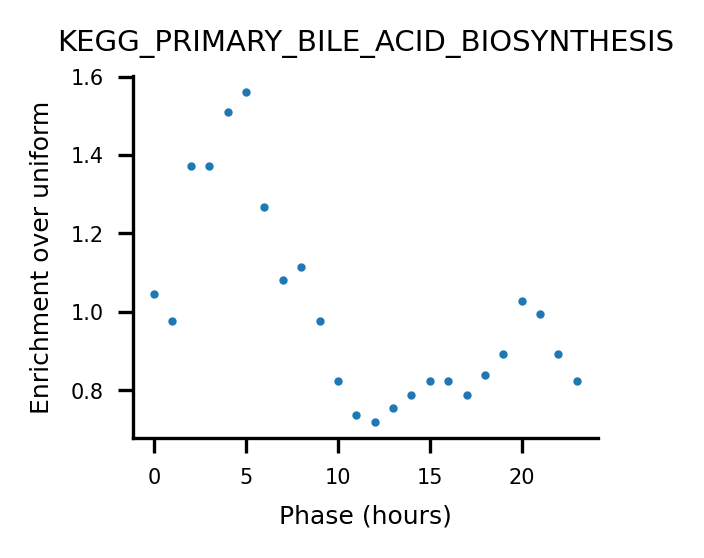

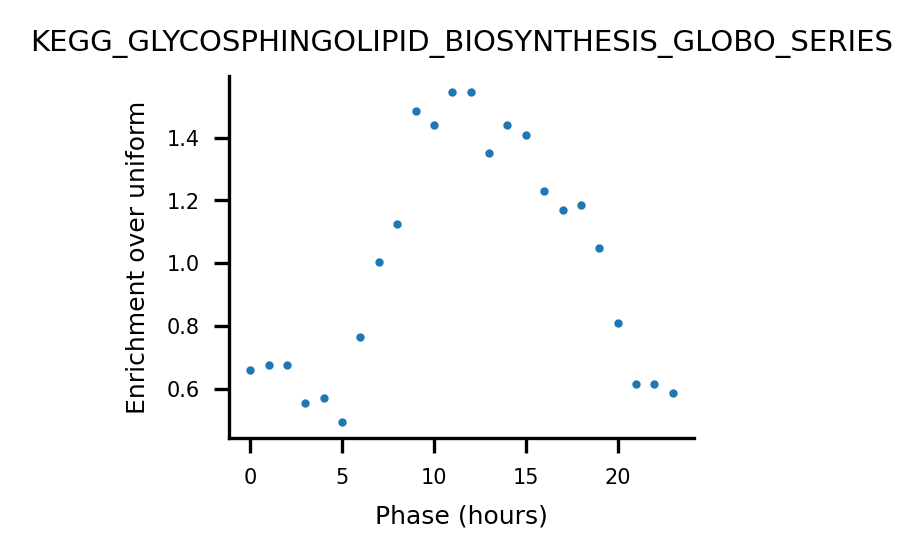

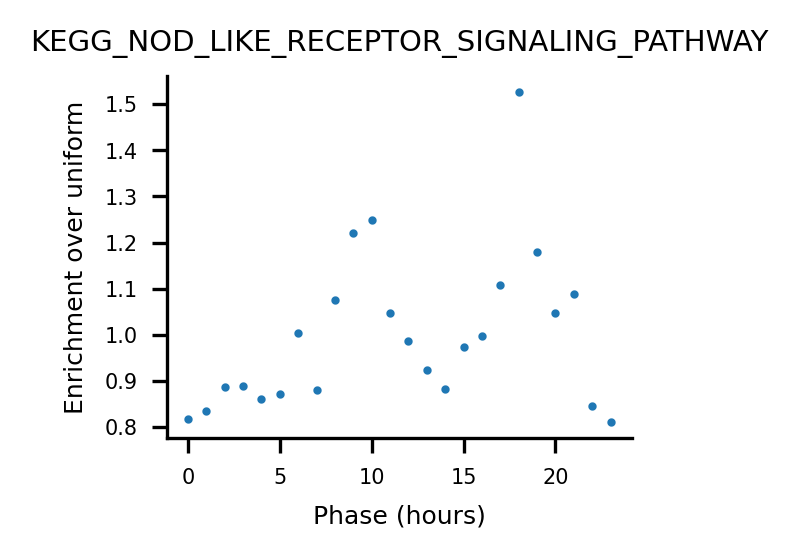

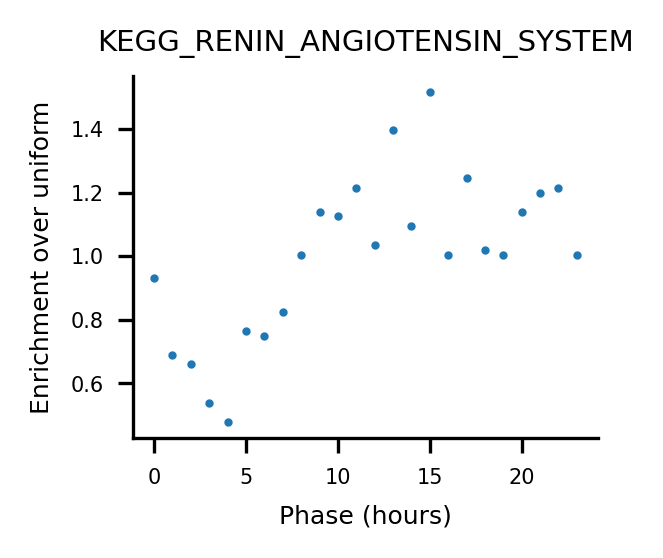

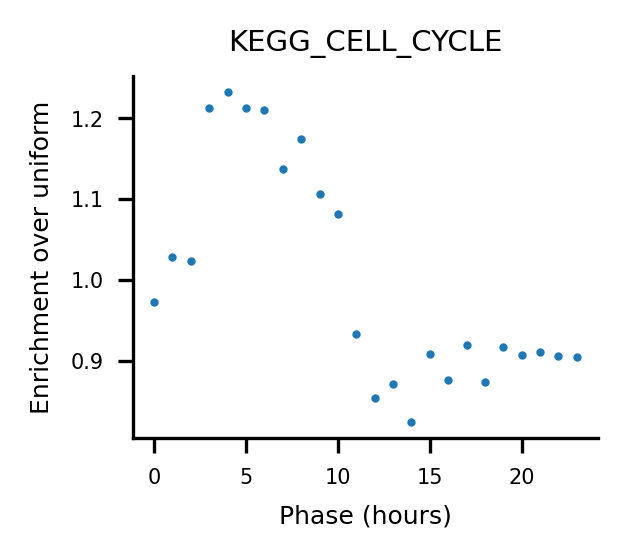

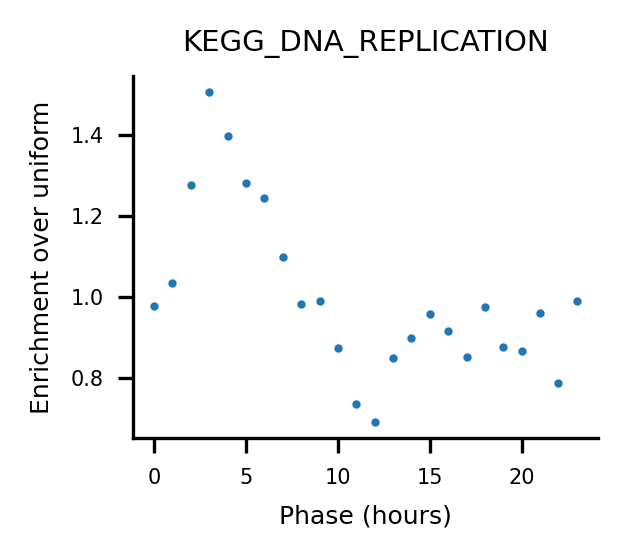

In [760]:
# # --- BAYESIAN ACROPHASE ENRICHMENT ---

# import bayesian_gene_set_enrichment
# import importlib
# importlib.reload(bayesian_gene_set_enrichment)


# gene_ontology = 'gsea_kegg_pathways_gene_sets' # 'gsea_location_gene_sets','gsea_kegg_pathways_gene_sets','gsea_reactome_pathways_gene_sets','go_biological_process'
# use_only_cyclers = False
# num_top_to_viz = 20
# min_num_genes_in_set = 5
# lrt_thresh = 1.5
# for cluster in clusters:

#     # ** get sampled waveform **
#     num_grid_points = 4
#     num_samples = 200
#     sampled_log_prop, male_fft_res,genes_with_params = get_log_prop_samples_and_fft(cluster,'male aligned bmal1-control',num_grid_points,num_samples,gene_list=reg_genes_to_est)

    
#     # ** run enrichment **
#     if use_only_cyclers:
#         cycling_genes = list(cluster_cycler_metric_dfs[cluster].index)
#         bayesian_gene_set_enrich_df,lrt_df = bayesian_gene_set_enrichment.acrophase_enrichment(head_folder,male_fft_res,circadian_index,gene_ontology,cycling_genes,num_grid_points=24)
#     else:
#         bayesian_gene_set_enrich_df,lrt_df = bayesian_gene_set_enrichment.acrophase_enrichment(head_folder,male_fft_res,circadian_index,gene_ontology,genes_with_params,num_grid_points=24)

#     # ** get the top gene sets **
#     top_gene_sets = np.array(bayesian_gene_set_enrich_df[(bayesian_gene_set_enrich_df['num_genes'] >= min_num_genes_in_set) & (bayesian_gene_set_enrich_df['gene_set_bin_max_lrt'] >= lrt_thresh)].index)
    
#     # ** write out the results **
#     subfolder_out = '%s/bayesian_acrophase_enrichment_top_gene_sets/%s/use_only_cyclers_%s/%s' % (folder_out, cluster_cell_type_dict[cluster], use_only_cyclers, gene_ontology)
#     if not os.path.exists(subfolder_out):
#         os.makedirs(subfolder_out)
        
#     # all
#     fileout = '%s/enrichment_results.tsv' % (subfolder_out)
#     bayesian_gene_set_enrich_df.to_csv(fileout,sep='\t')
#     fileout = '%s/enrichment_lrt.tsv' % (subfolder_out)
#     lrt_df.to_csv(fileout,sep='\t')
    
#     # top
#     fileout = '%s/top_enrichment_results.tsv' % (subfolder_out)
#     bayesian_gene_set_enrich_df.loc[top_gene_sets].to_csv(fileout,sep='\t')
#     fileout = '%s/top_enrichment_lrt.tsv' % (subfolder_out)
#     lrt_df.loc[top_gene_sets].to_csv(fileout,sep='\t')
    
    
#     # ** viz top **
#     for gene_set in top_gene_sets[:min(num_top_to_viz,len(top_gene_sets))]:
#         fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
#         plt.scatter((np.arange(0,lrt_df.shape[1]) / lrt_df.shape[1]) * 24.0, lrt_df.loc[gene_set], s = 1)
#         plt.xlabel('Phase (hours)')
#         plt.ylabel("Enrichment over uniform")
#         sns.despine()
#         plt.title(gene_set)
#         subfolder_out = '%s/bayesian_acrophase_enrichment_top_gene_sets/%s/use_only_cyclers_%s/%s/top_gene_sets' % (folder_out, cluster_cell_type_dict[cluster], use_only_cyclers, gene_ontology)
#         if not os.path.exists(subfolder_out):
#             os.makedirs(subfolder_out)
#         fileout = '%s/%s.pdf' % (subfolder_out, gene_set)
#         plt.savefig(fileout,bbox_inches='tight')
#         plt.show()
    
    
#     # ** viz gene sets of interest **
#     gene_sets_of_interest = ['KEGG_CELL_CYCLE','KEGG_DNA_REPLICATION']
#     for gene_set in gene_sets_of_interest:
#         try:
#             fig, ax = plt.subplots(figsize = (2,1.6),dpi=300)
#             plt.scatter((np.arange(0,lrt_df.shape[1]) / lrt_df.shape[1]) * 24.0, lrt_df.loc[gene_set], s = 1)
#             plt.xlabel('Phase (hours)')
#             plt.ylabel("Enrichment over uniform")
#             sns.despine()
#             plt.title(gene_set)
#             subfolder_out = '%s/bayesian_acrophase_enrichment_top_gene_sets/%s/use_only_cyclers_%s/%s/gene_set_of_interest' % (folder_out, cluster_cell_type_dict[cluster], use_only_cyclers, gene_ontology)
#             if not os.path.exists(subfolder_out):
#                 os.makedirs(subfolder_out)
#             fileout = '%s/%s.pdf' % (subfolder_out, gene_set)
#             plt.savefig(fileout,bbox_inches='tight')
#             plt.show()
#         except:
#             pass

        
    
